# Lattice Dynamics of Diamond and Zincblende-Structure Crystals     
**by <span style="color:darkgreen">Sebastian Tillack</span> & <span style="color:darkgreen">Pasquale Pavone</span> for [<span style="color:darkgoldenrod">exciting *sodium*</span>](https://www.exciting-code.org/sodium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial, you will learn how to perform a phonon calculation and to obtain properties like frequencies and eigenvectors, the density of modes (or phonon density of states), thermodynamic properties, and phonon-dispersion relations. You will work through the examples of diamond and cubic Boron nitride.
<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">

**Table of Contents**
    
[0. Before Starting](#0)
    
[1. Theoretical Background](#1)  
    
[2. Phonon Properties for Diamond](#2)  
    
   - [Set-up the Input File and Run the Calculation](#2.1)
    
   - [Output Files of a Phonon Calculation](#2.2)
    
   - [Properties from the Phonon Calculation](#2.3)
    
[3. Phonon Properties for Cubic Boron Nitride (cBN)](#3)  
    
   - [Set-up the Input File and Run the Calculation](#3.1)
    
   - [Output Files of a Phonon Calculation (Polar Materials)](#3.2)
    
   - [Properties from the Phonon Calculation](#3.3)
    
[4. Useful Tips for Real-life Calculations (DFPT)](#4)  
    
   - [Resume from a Previous Run](#4.1)
    
   - [Parallel Execution using Multiple Processes and MPI](#4.2)   

[5. Alternative: Phonons from Supercell Calculations](#5)  
    
   - [Set up the Supercell Phonon Calculation](#5.1)
    
   - [Output Files of a Phonon Calculation](#5.2)
    
   - [Polar Materials from Supercell Calculations](#5.3)  
    
   - [Phonon Properties for Diamond](#5.4) 
     
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>


In the following we use the conversion factor **<span style="color:mediumblue">1 Ha ≈ 2.194746 x 10<sup>5</sup> cm<sup>-1</sup></span>**.

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Theoretical Background</span>

<hr style="border:1px solid #DDD"> </hr> 
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Theory of linear response for phonons</span></strong>
    
</summary> 

Within **density-functional perturbation theory** (**DFPT**) we calculate the linear response of the Kohn-Sham (**KS**) system upon an external perturbation $\delta$. We express the quantities of the perturbed system as an expansion in the perturbation operator and write down the **KS** equations for the perturbed system

\begin{equation}
\tag{1}
\left(\hat{\bf h}\phantom{}^0 + \lambda \,\delta \hat{\bf h} + \dots\right) \left(\psi_{n{\bf k}}^0({\bf r}) + \lambda\, \delta \psi_{n{\bf k}}({\bf r}) + \dots\right) = \left(\epsilon_{n{\bf k}}^0 + \lambda \,\delta \epsilon_{n{\bf k}} + \dots\right) \left(\psi_{n{\bf k}}^0({\bf r}) + \lambda \,\delta \psi_{n{\bf k}}({\bf r}) + \dots\right) \;.
\end{equation}

Collecting terms linear in $\lambda$ we find the so called **Sternheimer equation**

\begin{equation}
\tag{2}
\left[\hat{\bf h}\phantom{}^0 - \epsilon_{n{\bf k}}^0\right] \,\delta \psi_{n{\bf k}}({\bf r}) = -\left[\delta \hat{\bf h} - \delta \epsilon_{n{\bf k}}\right] \,\psi_{n{\bf k}}^0({\bf r}) \;,
\end{equation}

from which the linear response of the wavefunctions $\delta \psi_{n{\bf k}}$ can be obtained. Equivalently to the **KS** equations, the Sternheimer equation has to be solved self consistently, since the Hamiltonian response implicitly depends on the wave function response via the density and potential response:

\begin{equation}
\tag{3}
\delta \psi_{n{\bf k}} \rightarrow \delta n({\bf r}) \rightarrow \delta V({\bf r}) \rightarrow \delta \hat{\bf h} \rightarrow \delta \psi_{n{\bf k}} \;.
\end{equation}

In the case of **DFPT** for phonons, the external perturbation is a collective phonon-like displacement of the nuclei from their equilibrium positions $\pmb{\tau}_{\kappa{\bf R}}$

\begin{equation}
\tag{4}
\delta = \delta^{\bf q}_{\kappa \alpha} \quad:\quad \pmb{\tau}_{\kappa {\bf R}} \longrightarrow \pmb{\tau}_{\kappa {\bf R}} + {\rm e}^{{\rm i}{\bf q}\cdot{\bf R}} \delta \pmb{\tau}_{\kappa} \;,
\end{equation}

where $\kappa$ and ${\bf R}$ label atoms and unit-cells, respectively, ${\bf q}$ is the phonon wave vector and $\delta \pmb{\tau}_{\kappa}$ is an infinitesimal displacement vector.

In order to exploit symmetries, we do not displace every atom individually in the three Cartesian directions (canonical basis) but we use special symmetry adapted displacement patterns (**irreducible representations**, **irreps**):

\begin{equation}
\tag{5}
\delta^{\bf q}_{Id} = \sum_{\kappa,\alpha} p_{\kappa \alpha, Id}({\bf q})\, \delta^{\bf q}_{\kappa \alpha} \;,
\end{equation}

where $I$ labels an **irrep** (for a given ${\bf q}$) and $d$ labels a so-called member of the **irrep**.

Once we have converged the Sternheimer equation for the density and potential response, we can use the results to compute in a single step the linear response of the atomic forces ${\bf F}_{\kappa}$ which directly correspond to the entries of the dynamical matrix

\begin{equation}
\tag{6}
\delta^{\bf q}_{\kappa \alpha} F_{\kappa' \beta} = \sqrt{M_\kappa\, M_{\kappa'}}\, D_{\kappa \alpha, \kappa' \beta}({\bf q}) \;.
\end{equation}
    
</details> 
<hr style="border:1px solid #DDD"> </hr> 

<a id='2'></a>

### <span style="color:#15317E">2. Phonon Properties for Diamond</span>

All results obtained in this tutorial for diamond can be compared with theoretical and experimental data present in the **[literature](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.48.3156)**.

In order to start, create a new working directory.

In [1]:
%%bash
mkdir -p run_diamond_phonons

<a id='2.1'></a>
**<span style="color:#15317E">2.1 Set-up the Input File and Run the Calculation</span>**

Create the **input.xml** file with the following content.

<span class="DIAMOND_PHONONS"></span>
```xml
<input>
 
   <title>Diamond: Phonons</title>
 
   <structure speciespath="$EXCITINGROOT/species">
 
      <crystal scale="6.749908">
         <basevect> 0.5  0.5  0.0 </basevect>
         <basevect> 0.5  0.0  0.5 </basevect>
         <basevect> 0.0  0.5  0.5 </basevect>
      </crystal>
 
      <species speciesfile="C.xml" rmt="1.25">
         <atom coord="0.00 0.00 0.00" />
         <atom coord="0.25 0.25 0.25" />
      </species>
 
   </structure>
 
   <groundstate 
      do="fromscratch"
      ngridk="4 4 4"
      swidth="0.0001"
      rgkmax="4.0"
      gmaxvr="14"
      tforce="true">
      <libxc correlation="XC_GGA_C_PBE" exchange="XC_GGA_X_PBE"/>
   </groundstate>
 
   <phonons
      do="fromscratch"
      method="dfpt"
      ngridq="2 2 2"
      polar="false">
      <qpointset>
         <qpoint> 0.0 0.0 0.0 </qpoint>
         <qpoint> 0.5 0.5 0.0 </qpoint>
         <qpoint> 0.5 0.5 0.5 </qpoint>
      </qpointset>
   </phonons>
 
</input>
```

In [2]:
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("lattice_dynamics_of_diamond_and_zincblende_structure_crystals", "DIAMOND_PHONONS")

# Write out the input as an XML file:
with open('./run_diamond_phonons/input.xml', "w") as fid:
    fid.write(input_str)

The input block that describes a phonon calculation is specified by the element <code><span style="color:green">phonons</span></code>. In exciting, there are two different methods available to compute phonons: the **supercell method** and **DFPT**. The latter is the default and what will cover in the first part of this tutorial. The dynamical matrices are calculated for a regular grid of phonon wavevectors **q** specified by the attribute <code><span style="color:mediumblue">ngridq</span></code> inside <code><span style="color:green">phonons</span></code>. The **q**-points mesh is defined in the same way as the **k**-points grid (specified by <code><span style="color:mediumblue">ngridk</span></code>), which is used in calculating the electronic ground state. Afterwards, the phonon frequencies and eigenvectors at any wavevector **q** can be obtained by Fourier interpolation. Note that in the case of a **DFPT** calculation, the **k**- and **q**-grid need to be commensurate, *i.e.*, ngridk must be an integer multiple of <code><span style="color:mediumblue">ngridq</span></code>. In the case of a supercell calculation, both grids are completely uncorrelated.

A novelty in the <code><span style="color:green">groundstate</span></code> element is that we replace the attribute <code><span style="color:mediumblue">xctype</span></code> by the new element <code><span style="color:green">libxc</span></code>. By that, we specify to take the exchange-correlation potential from the **libxc** library instead of the **`exciting`** internal implementation. The reason for this change is that a **DFPT** calculation requires the xc-kernel (the second derivatives of the xc-energy) which is not natively implemented in **`exciting`** and is always obtained from the **libxc** library. For full consistency, we recommend to also use the xc-potential (first derivative of the xc-energy) from libxc. However, in principle you can also use the exciting internal implementations of the xc-potential using the attribute <code><span style="color:mediumblue">xctype</span></code>. In this case, only the xc-kernel of the corresponding potential is obtained from **libxc**.

Further attributes of the element <code><span style="color:green">phonons</span></code> are the following.

- <code><span style="color:mediumblue">method</span></code>, that controls the method employed to compute phonons (default is <code><span style="color:firebrick">"dfpt"</span></code>).
- <code><span style="color:mediumblue">reduceq</span></code>, which uses crystal symmetry to reduce the q-points (default is <code><span style="color:firebrick">"true"</span></code>).
- <code><span style="color:mediumblue">polar</span></code>, that specifies whether a polar or nonpolar material is to be calculated (default is <code><span style="color:firebrick">"true"</span></code>).

Inside the element <code><span style="color:green">phonons</span></code>, you can insert optional elements, requesting various phonon properties. A basic example is the element <code><span style="color:green">qpointset</span></code>.

```xml
...
      <qpointset>
         <qpoint> 0.0 0.0 0.0 </qpoint>
         <qpoint> 0.5 0.5 0.0 </qpoint>
         <qpoint> 0.5 0.5 0.5 </qpoint>
      </qpointset>
...

```

This element is needed in order to let **`exciting`** calculate phonon eigenvalues (frequencies) and eigenvectors for the **q**-points specified in each subelement <code><span style="color:green">qpoint</span></code>. In the example above, calculations will be performed for **Γ**, **X**, and **L** phonons (in the standard notation for high-symmetry points in the Brillouin zone of fcc crystals). Note that **q**-points are given in reciprocal lattice coordinates. Additional properties are discussed in **Section 2.3**.

After you have created the input file **input.xml**, you can run **`exciting`** by using the commands

In [3]:
%%bash
cd run_diamond_phonons
python3 -m excitingscripts.setup.excitingroot
python3 -m excitingscripts.execute.single
cd ..

The calculation is completed if the file **PHONON.OUT** has been created.

<a id='2.2'></a>
<hr style="border:1px solid #DDD"> </hr>

**<span style="color:#15317E">2.2 Output Files of a Phonon Calculation</span>**

The main result of a phonon calculation are the dynamical matrices. They are given in the files **DYN_*fileext*.OUT**, where ***fileext*** means an extension of the filename having the structure **Q####_####_####_S##_A###_P#.OUT** and specifying the **q** vector on the grid (**Q**…) species and index of the displaced atom (**S**… and **A**…) and polarization direction (**P**…). Additionally, a number of subdirectories is created. In a **DFPT** calculation, their names are **Q####_####_####_I###**, where the first part specifies the **q**-point in the grid and the second part labels the **irrep** at that specific **q**-point. **Irreps** are special symmetry adapted displacement patterns. Inside of each subdirectory, you will find the following files:


filename|description
:-----------|:--------------------------------
**PHONON_INFO_*fileext*.OUT**| General information about the run. Similar to **INFO.OUT** for the groundstate.
**DYN_*fileext*_#.OUT**| Force response (or dynamical matrix row) for the #-th member of the irrep.
**PHONON_DRHO_*fileext*_#.OUT**| Electron density response for the #-th member of the irrep.
**PHONON_DVEFF_*fileext*_#.OUT**| Effective potential response for the #-th member of the irrep.

where ***fileext*** is the same as the subdirectory name.

In the following, we take a closer look to the file **PHONON_INFO_Q0000_0000_0000_I001.OUT**.

**<span style="color:#15317E">2.2.1 PHONON_INFO_*fileext*.OUT</span>**

The first part of the file contains information about the use of symmetries, parallelization settings and the whole phonon run.

```
********************************************************************************
* symmetries and parallelization settings                                      *
********************************************************************************

Irreducible representations are used.
k-points are reduced by symmetries.
Response quantities are symmetrized.

q-points and symmetries:

  iq  q-vector (lattice coordinates)  N_sym  N_k  N_irrep (size)
--------------------------------------------------------------------------------
   1 ( 0.000000, 0.000000, 0.000000)     48    8        2 (3*,3)
   2 ( 0.500000, 0.000000, 0.000000)     12   13        4 (2,1,1,2)
   3 ( 0.500000, 0.500000, 0.000000)     16   13        3 (2,2,2)

current task / total (remaining) number of tasks:         1/       9 (9)
load of current task / total (remaining) load:           24/     204 (204)
procs for current task / total number of procs:           1/       1
average / maximum load per proc:                        204/     204
number of idle procs:                                     0
```

The first lines tell that the **irreps** have been used as displacement patterns and that the computational cost has been reduced by exploiting symmetries.

The following table displays all (irreducible) **q**-points that are computed in that phonon calculation. **N_sym** is the number of crystal symmetries in the **small group** of **q**. **N_k** indicates the number of **k**-points in the irreducible Brillouin zone obtained with the symmetries in the small group. **N_irrep** denotes the number of irreps for the given **q**-point and the values in parenthesis give their respective size (or equivalently the number of members per **irrep**). The **q**-point and **irrep** this file corresponds to is marked with an asterisk.

From the last lines we can extract that the whole calculation consists of 9 independent tasks from which all 9 are remaining and that this particular file corresponds to **task 1**. The meaning of the other lines will be discussed below in the **Section 5.2**.

In the next part, the displacement patterns of the **irreps** are given.

```
********************************************************************************
* irreducible representations / atomic displacement patterns                   *
********************************************************************************

irrep member 1
  C     1    +0.7071067812 +0.0000000000i
             +0.0000000000 +0.0000000000i
             +0.0000000000 +0.0000000000i
  C     2    -0.7071067812 +0.0000000000i
             +0.0000000000 +0.0000000000i
             +0.0000000000 +0.0000000000i

irrep member 2
  C     1    +0.0000000000 +0.0000000000i
             +0.7071067812 +0.0000000000i
             +0.0000000000 +0.0000000000i
  C     2    +0.0000000000 +0.0000000000i
             -0.7071067812 +0.0000000000i
             +0.0000000000 +0.0000000000i

irrep member 3
  C     1    +0.0000000000 +0.0000000000i
             +0.0000000000 +0.0000000000i
             +0.7071067812 +0.0000000000i
  C     2    +0.0000000000 +0.0000000000i
             +0.0000000000 +0.0000000000i
             -0.7071067812 +0.0000000000i
```

In this example, the **irrep** has three members and for each member, the three components of the (potentially complex) displacement vector for each atom are given.

The remainder of the file contains information about the self-consistency cycle of the Sternheimer equation and shows the change in the potential response for each iteration:


```
********************************************************************************
* scf loop for Sternheimer equation started                                    *
********************************************************************************

Sternheimer SCF loop iteration   1
maximum change in potential response:                0.960508E-01
Fermi energy response:                                0.00000    
Time spent for iteration (seconds):                          1.20

Sternheimer SCF loop iteration   2
maximum change in potential response:                0.646932E-01
Fermi energy response:                                0.00000    
Time spent for iteration (seconds):                          3.40

...
```

**<span style="color:#15317E">2.2.2 PHONON.OUT</span>**

If you have specified a <code><span style="color:green">qpointset</span></code> in the input file, the frequencies of the phonon modes at the required **q**-points are listed inside the file **PHONON.OUT**. However, in this file frequencies are given in non frequently used **<span style="color:firebrick">atomic units</span>**. In order to get frequency values which can be compared to experimental data, you may use the script **`excitingscripts.convert.au2invcm`** to obtain frequencies expressed in units of **cm<sup>-1</sup>**.

In [3]:
%%bash
cd run_diamond_phonons
python3 -m excitingscripts.convert.au2invcm
cd ..

Total number of atoms    :     2
Total number of q-points    :     3

q-point   1  is  [0.0, 0.0, 0.0]
   mode   1      frequency:     0.0000 cm-1
   mode   2      frequency:     0.0000 cm-1
   mode   3      frequency:     0.0000 cm-1
   mode   4      frequency:  1243.5784 cm-1
   mode   5      frequency:  1243.5784 cm-1
   mode   6      frequency:  1243.5784 cm-1

q-point   2  is  [0.5, 0.5, 0.0]
   mode   1      frequency:   782.9265 cm-1
   mode   2      frequency:   782.9265 cm-1
   mode   3      frequency:  1006.6311 cm-1
   mode   4      frequency:  1006.6311 cm-1
   mode   5      frequency:  1195.6297 cm-1
   mode   6      frequency:  1195.6297 cm-1

q-point   3  is  [0.5, 0.5, 0.5]
   mode   1      frequency:   539.9045 cm-1
   mode   2      frequency:   539.9045 cm-1
   mode   3      frequency:   998.7204 cm-1
   mode   4      frequency:  1149.7671 cm-1
   mode   5      frequency:  1149.7671 cm-1
   mode   6      frequency:  1275.9419 cm-1


<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Excercise</b></span>
    
- Have a look to the file **PHONON.OUT**. What is the frequency of the optical phonon modes at **Γ**?  
- What are the eigenvectors of the optical phonon modes at **Γ**?    
    
</div>    

<a id='2.3'></a>
<hr style="border:1px solid #DDD"> </hr>

**<span style="color:#15317E">2.3 Properties from the Phonon Calculation</span>**

To obtain other phonon properties, additional subelements can be inserted inside the element <code><span style="color:green">phonons</span></code>, as explained in the following.

**Phonon density of states (DOS)**

The phonon density of states is computed on top of the phonon calculation by adding the element <code><span style="color:green">phonondos</span></code> within the element <code><span style="color:green">phonons</span></code>.

```xml
...
   <phonondos ngridqint="70 70 70" nwdos="1000" nsmdos="2"/>
...

```

Here, phonon frequencies are computed on a dense grid (<code><span style="color:mediumblue">ngridqint</span></code>) and collected to obtain the **DOS**, which is written to the file **PHDOS.OUT**. The number of steps between the lowest and highest frequency (N$_{\omega}$) is given by <code><span style="color:mediumblue">nwdos</span></code>, <code><span style="color:mediumblue">nsmdos</span></code> is the number of times the data are smoothened.

The modified input file in this case is shown below.

```xml

<input>
 
   <title>Diamond: Phonons</title>
 
   <structure speciespath="$EXCITINGROOT/species">
      ... 
   </structure>
 
   <groundstate 
      do="skip" 
      .../>
 
   <phonons 
      do="skip"
      ...>
      <phonondos 
         ngridqint="70 70 70" 
         nwdos="1000"  
         nsmdos="2"/>
   </phonons>
 
</input>

```

Note the presence of the two attributes <code><span style="color:mediumblue">do</span>=<span style="color:firebrick">"skip"</span></code> inside the elements <code><span style="color:green">phonons</span></code> and <code><span style="color:green">groundstate</span></code>, respectively. They let **`exciting`** skip a new (and lengthy) phonon calculation and read the necessary data from existing files.

In [9]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingPhononsInput

parsed_input = ExcitingInputXML.from_xml('./run_diamond_phonons/input.xml')

phonons = {'do': 'skip',
           'method': 'dfpt',
           'ngridq': [2, 2, 2],
           'polar': False,
           'phonondos': {'ngridqint': [70, 70, 70], 'nwdos': 1000, 'nsmdos': 2}}

parsed_input.groundstate.do = 'skip'
parsed_input.phonons = ExcitingPhononsInput(**phonons)

parsed_input.write('./run_diamond_phonons/input.xml')

This requires you, of course, to have already performed the basic phonon calculation with the same parameters (as in **Section 2.1**) and to work in the same directory. If this is the case, in order to perform the calculation, you type

In [47]:
%%bash
cd run_diamond_phonons
python3 -m excitingscripts.execute.single
cd ..

The data in **PHDOS.OUT** can be plotted directly. For this, you can use the script **`excitingscripts.plot.dos`**, which is fully described in [**The python script "plot.dos"**](https://www.exciting-code.org/the-python-script-plot.dos). Execute the script as follows.

In [48]:
%%bash
cd run_diamond_phonons
python3 -m excitingscripts.plot.dos -p  -e 0 1400
cd ..

The script produces a **PNG** (**PLOT.png**) output, which should be similar to the one displayed here.



<figure>
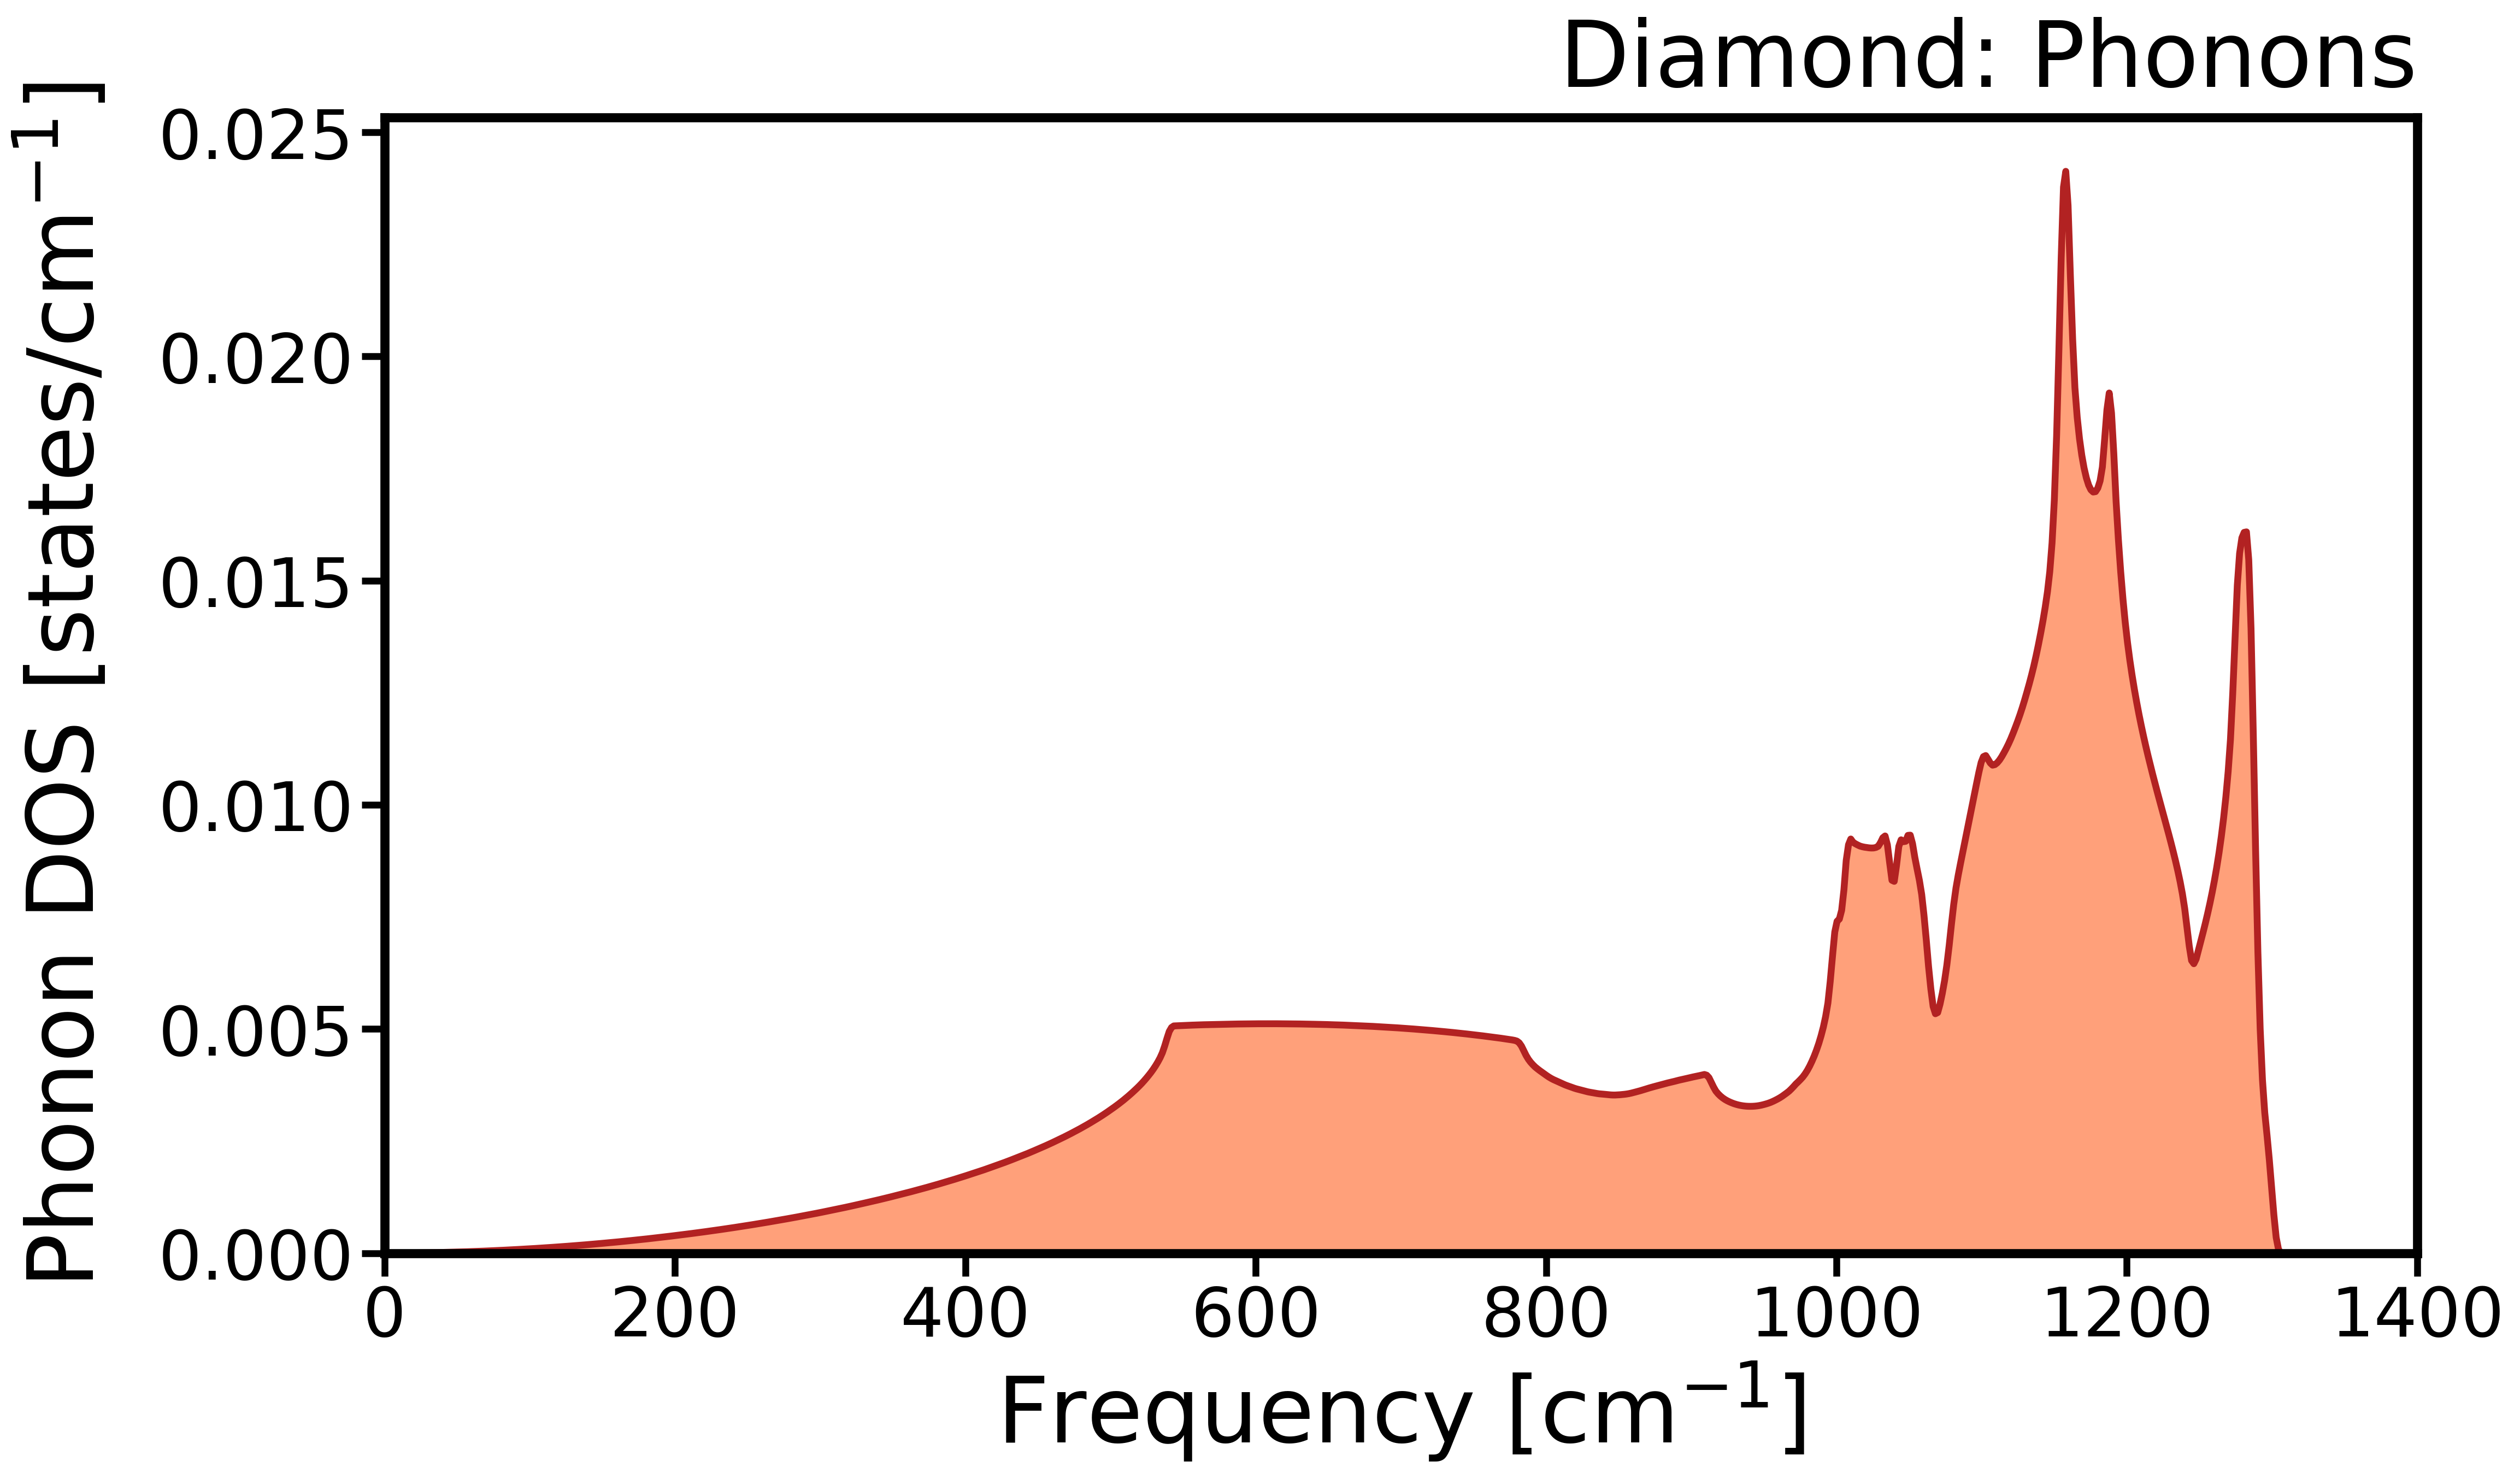
</figure>

A better converged result (using an **8**×**8**×**8** **k**-grid, <code><span style="color:mediumblue">rgkmax</span></code> = **"7.0"**, and **4** **q**-points in each direction) can be found below.

<hr style="border:1px solid #DDD"> </hr> 
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Show converged plot</span></strong>
    
</summary>
    
<strong><span style="color:firebrick">Hint</span></strong>: Run the converged calculation in a different directory, *e.g.*, **/home/tutorial/diamond-phonons/conv**. Copy here the previous **input.xml** and modify the computational parameters. The result should look like the following.  
    
<figure>
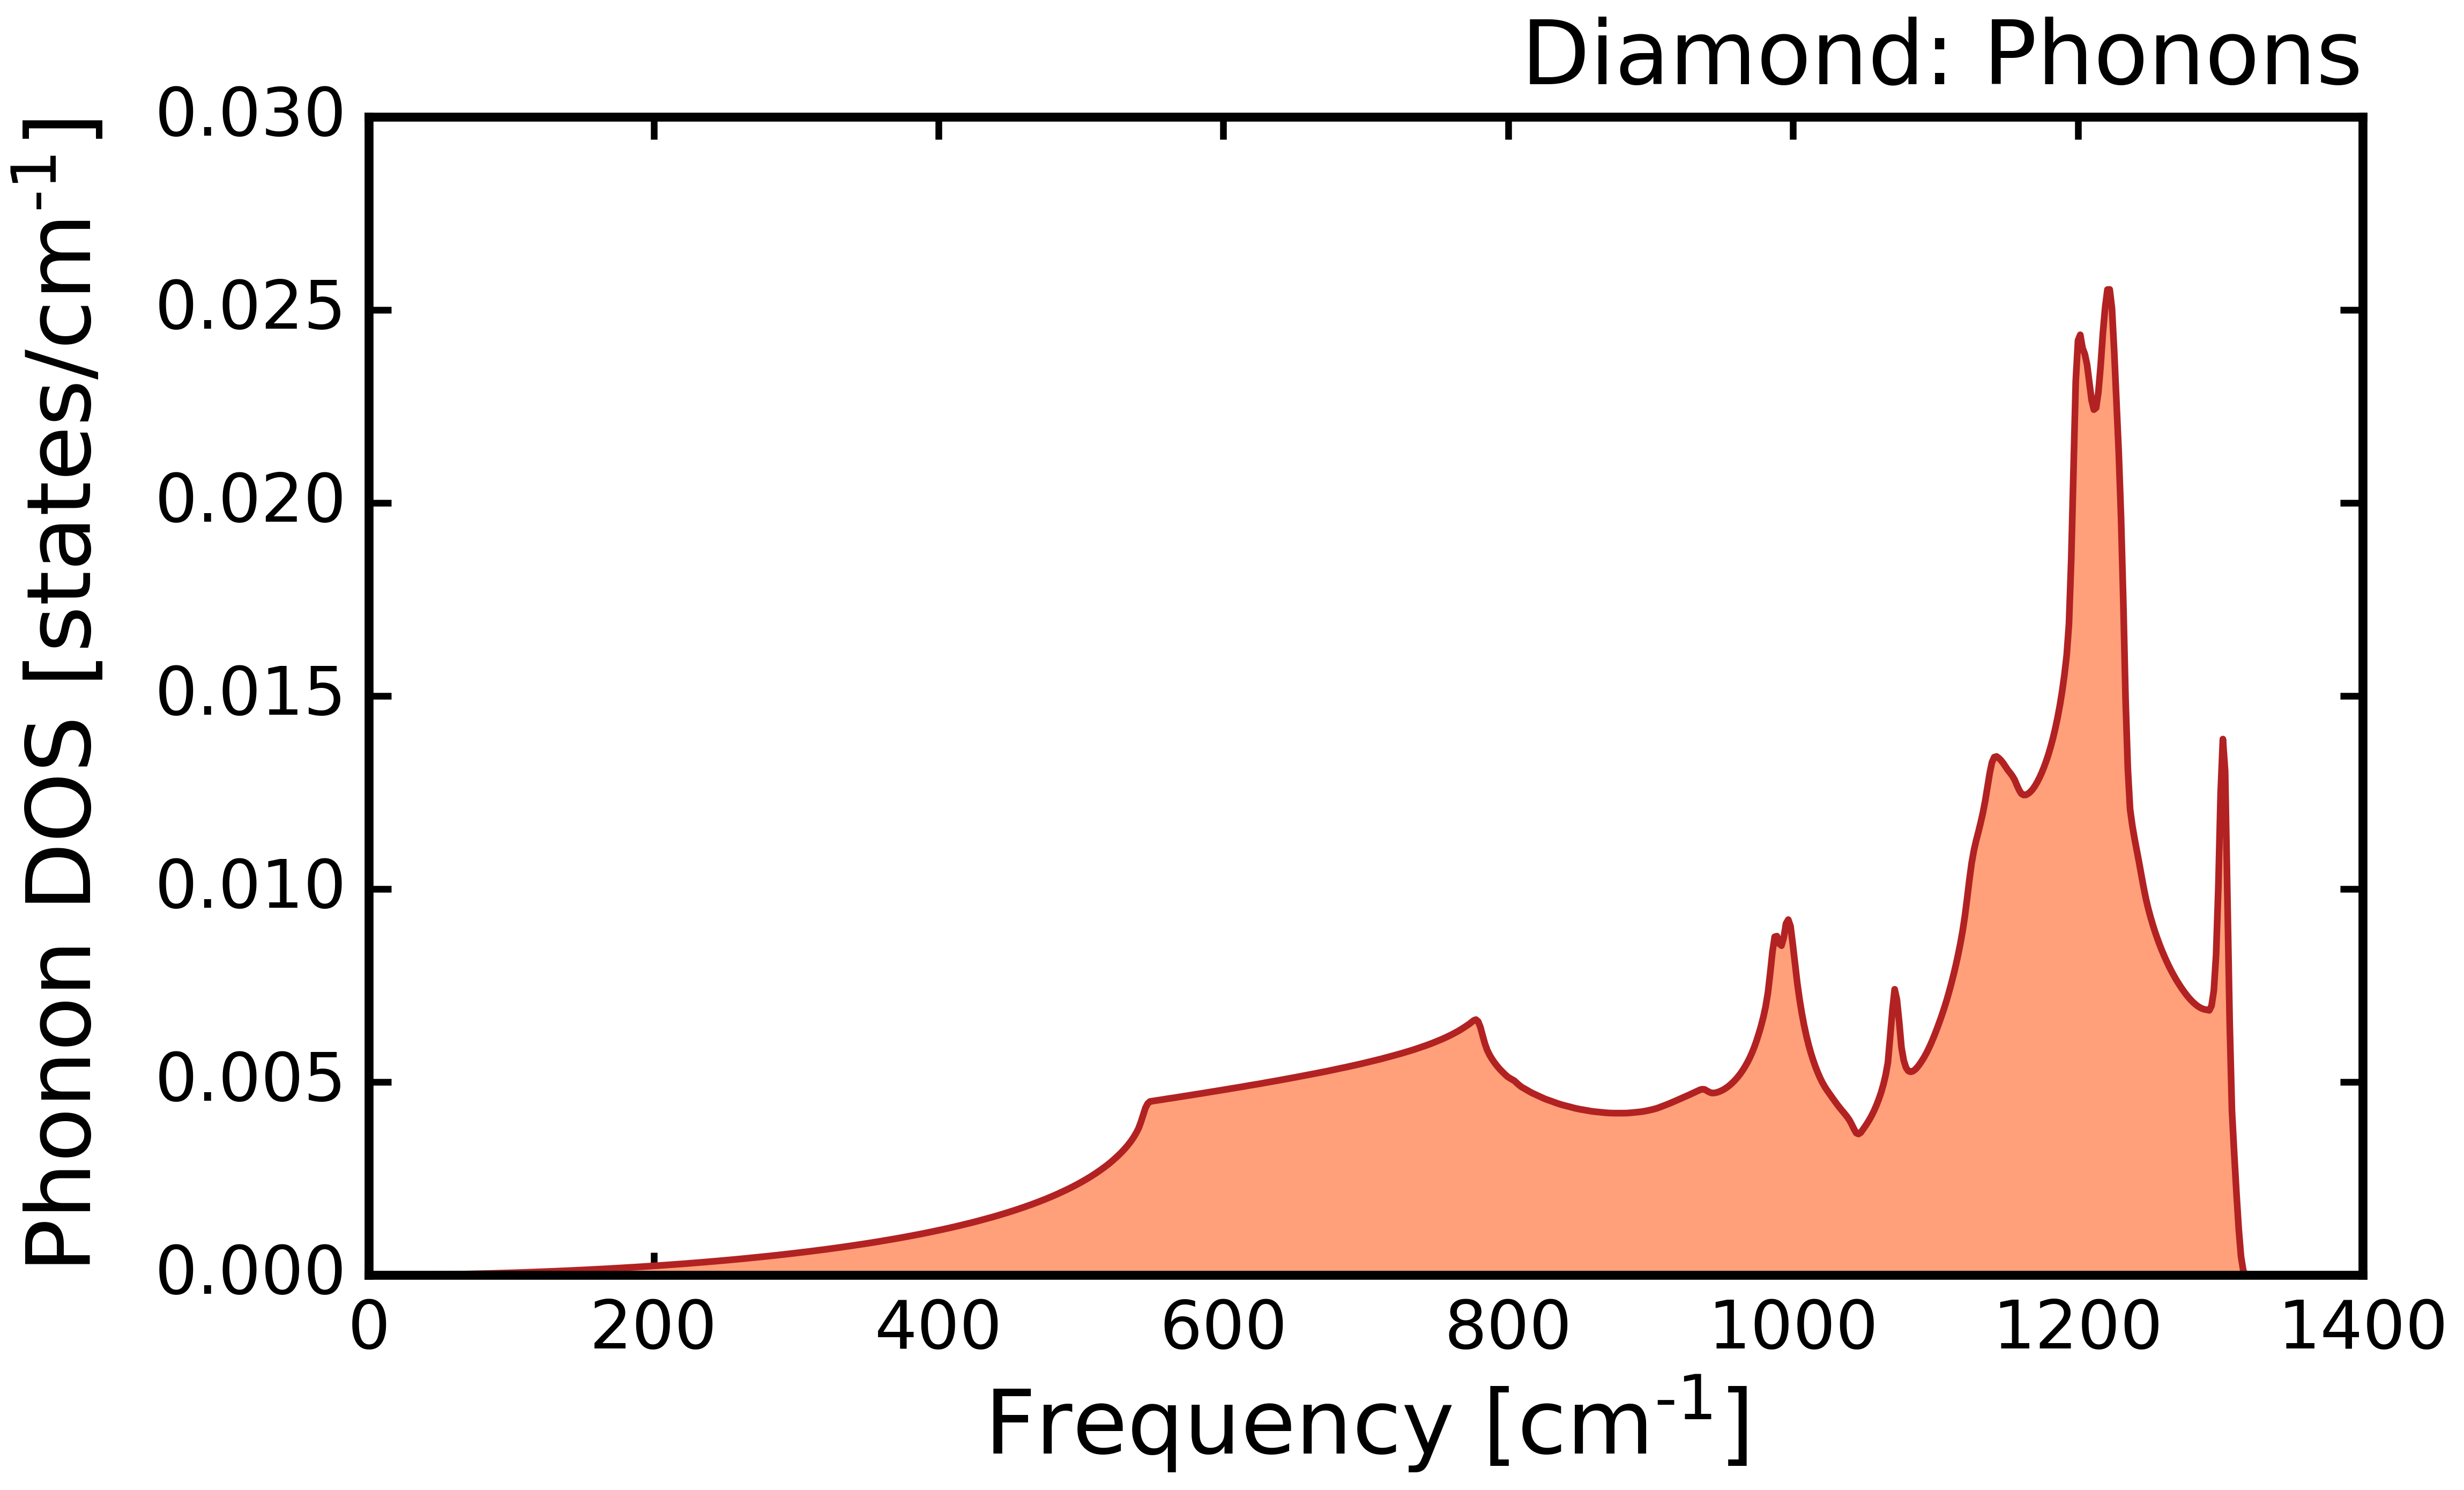
</figure>
    
</details> 
<hr style="border:1px solid #DDD"> </hr>      

**Thermodynamic properties**

The zero-point energy, $E_{zp}$, and further thermodynamic properties can be computed from the phonon **DOS** $g(\omega)$ (see **[Input Reference](https://www.exciting-code.org/home/about/input-reference)** for their definition for further details).

1. the vibrational free energy $F_{vib}= U_{vib} - TS_{vib}$,
2. the vibrational internal energy $U_{vib}$,
3. the entropic contribution to the vibrational free energy $TS_{vib}$,
4. the vibrational entropy $S_{vib}$
5. the heat capacity $C_v$.

In order to calculate and visualize these thermodynamic properties, you can use the script **`excitingscripts.free_from_dos`** as follows

In [5]:
%%bash
cd run_diamond_phonons
python3 -m excitingscripts.free_from_dos 0 1400 160 eV
cd ..


Zero-point energy is 3.5124e-01 [eV]



where the 4 online entries are the minimum temperature (usually **0**), the maximum temperature, the number of temperature steps between the minimum and the maximum, and the energy units (either **eV** or **Ha**) . The value of the calculated zero-point energy is written on the screen output. The script generates the output files **F_vib**, **U_vib**, **TS_vib**, **S_vib**, **C_v**, which can be visualized with standard tools. Examples using the script **`excitingscripts.plot.files`** are given in the following:

In [6]:
%%bash
cd run_diamond_phonons
python3 -m excitingscripts.plot.files -f F_vib U_vib TS_vib -lx 'Temperature [K]' -ly 'Free energy [eV]' -g -mtx 4 -s 0.65 1.3 -pn 'PLOT-free-energies'
python3 -m excitingscripts.plot.files -f S_vib -lx 'Temperature [K]' -ly 'Entropy [meV/K]' -g -pn 'PLOT-entropy'
python3 -m excitingscripts.plot.files -f C_v -lx 'Temperature [K]' -ly 'Heat capacity [$k_B$]' -g -pn 'PLOT-heat-capacity'
cd ..

<figure>
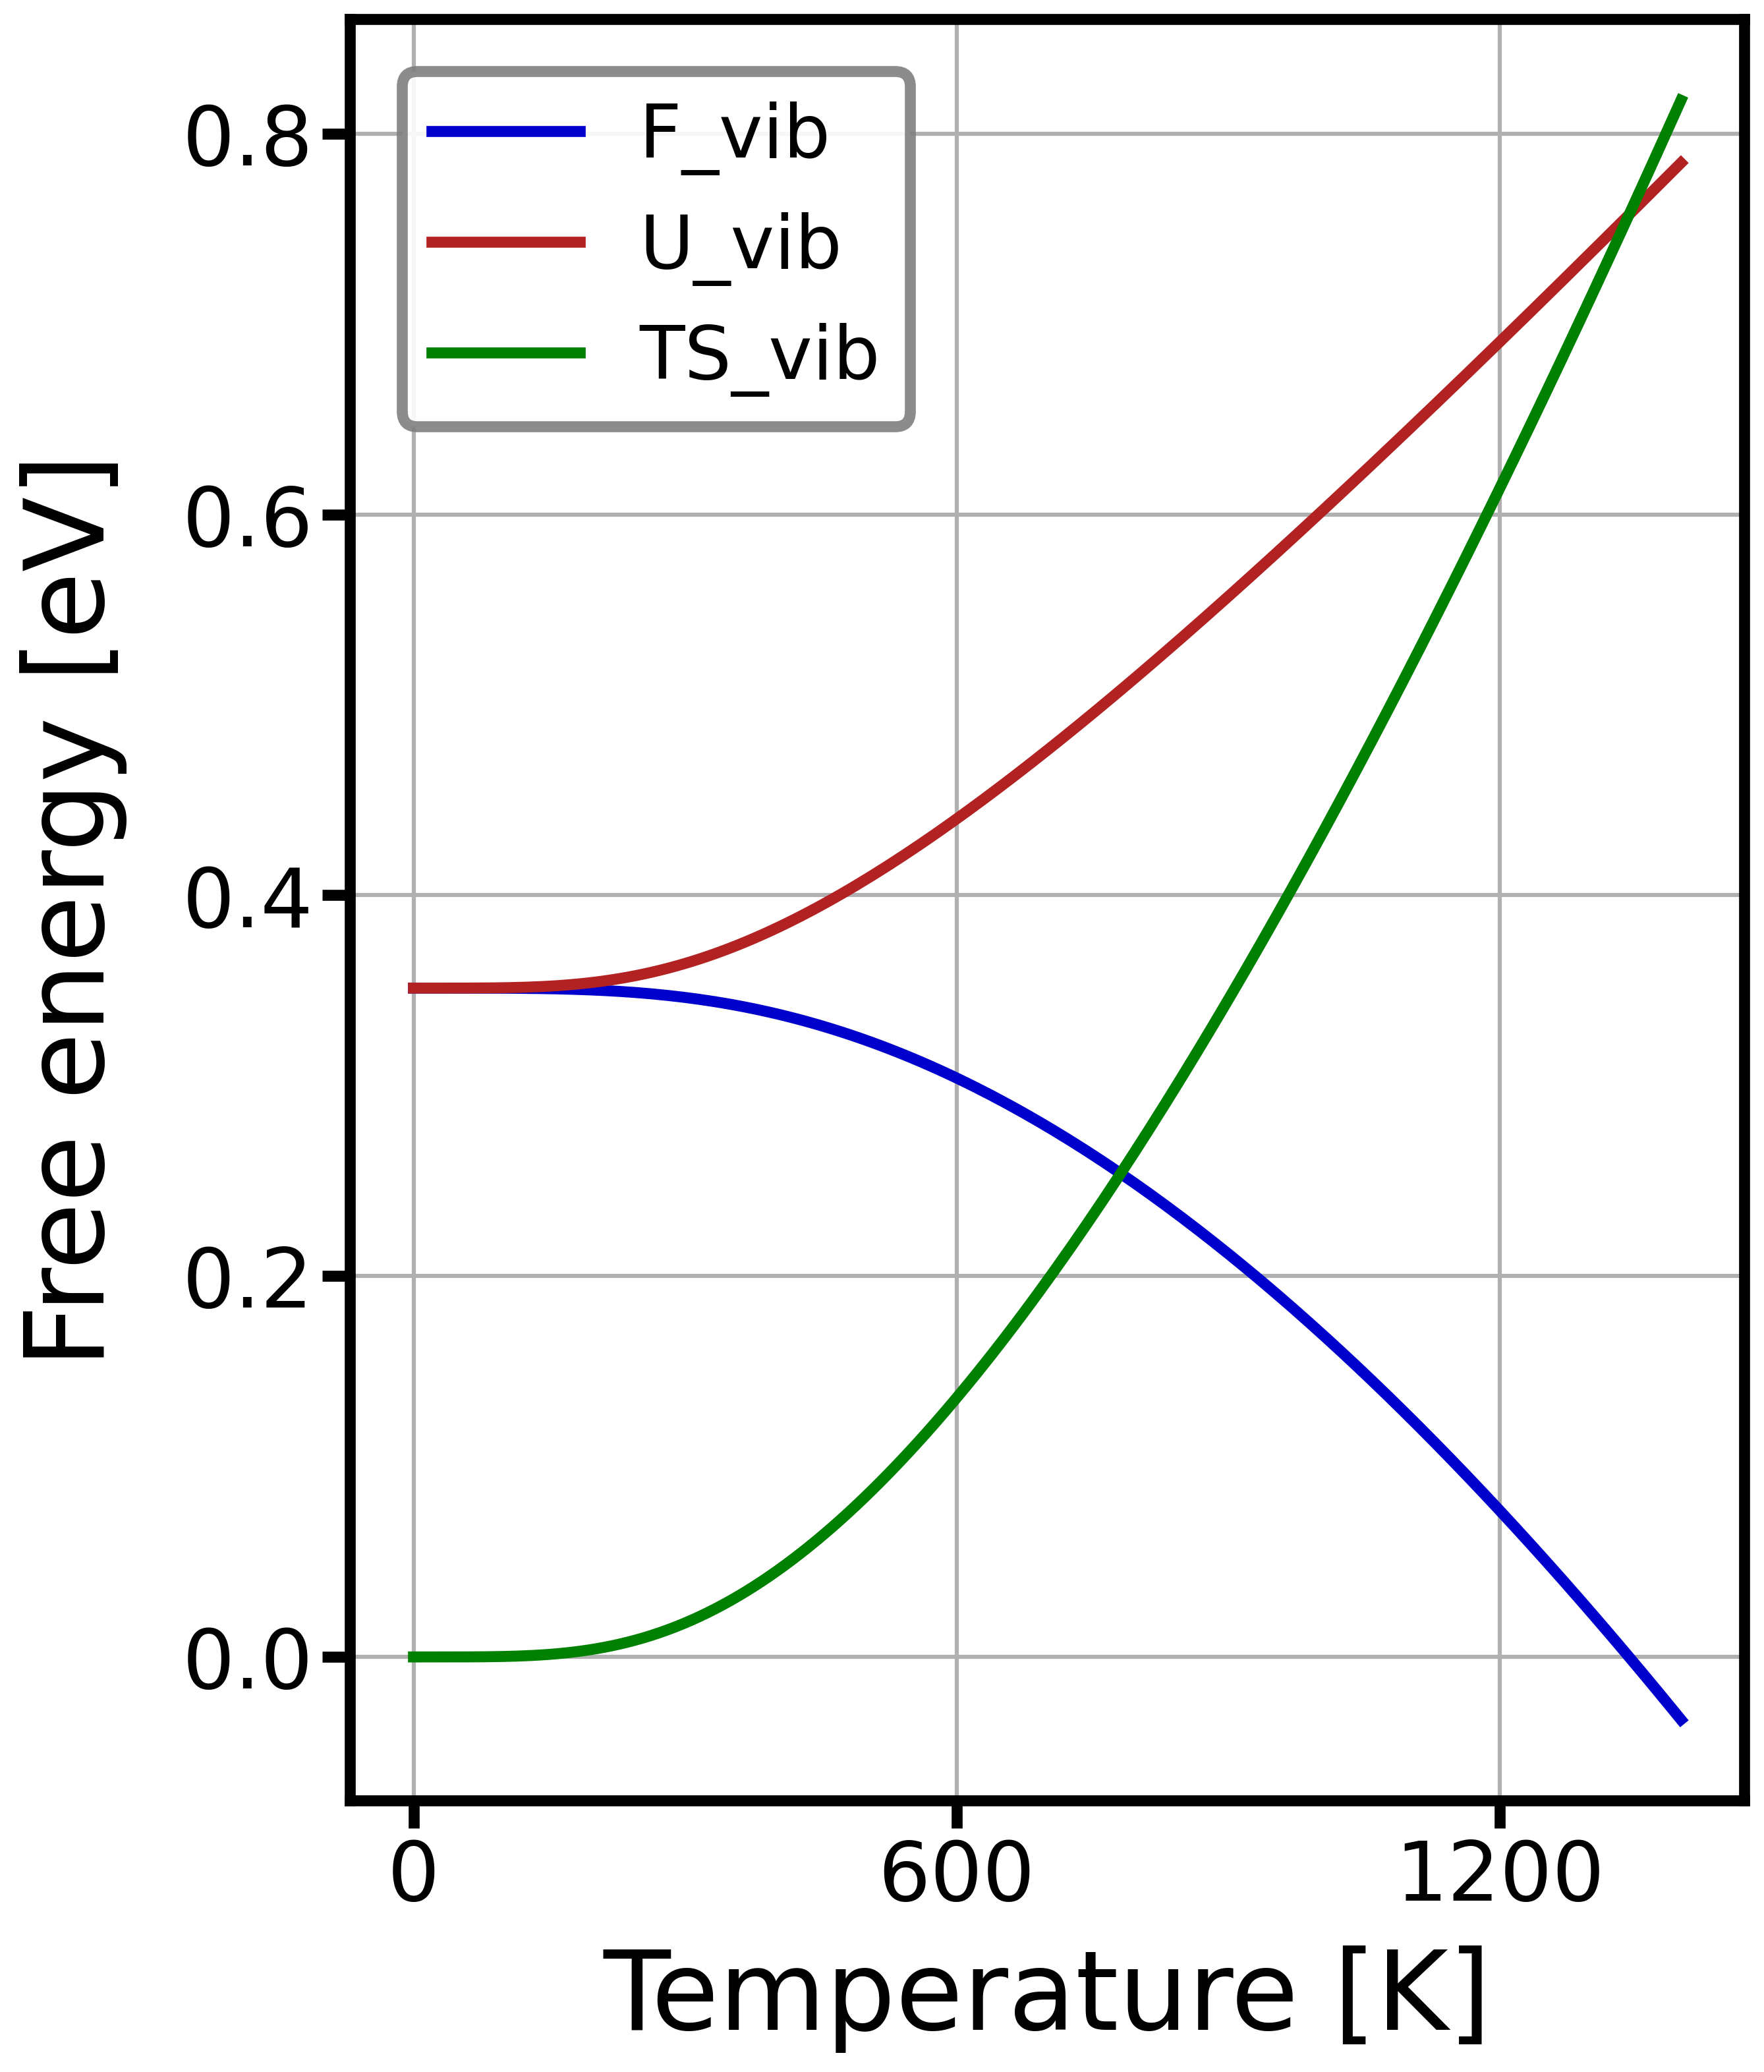
</figure>

<figure>
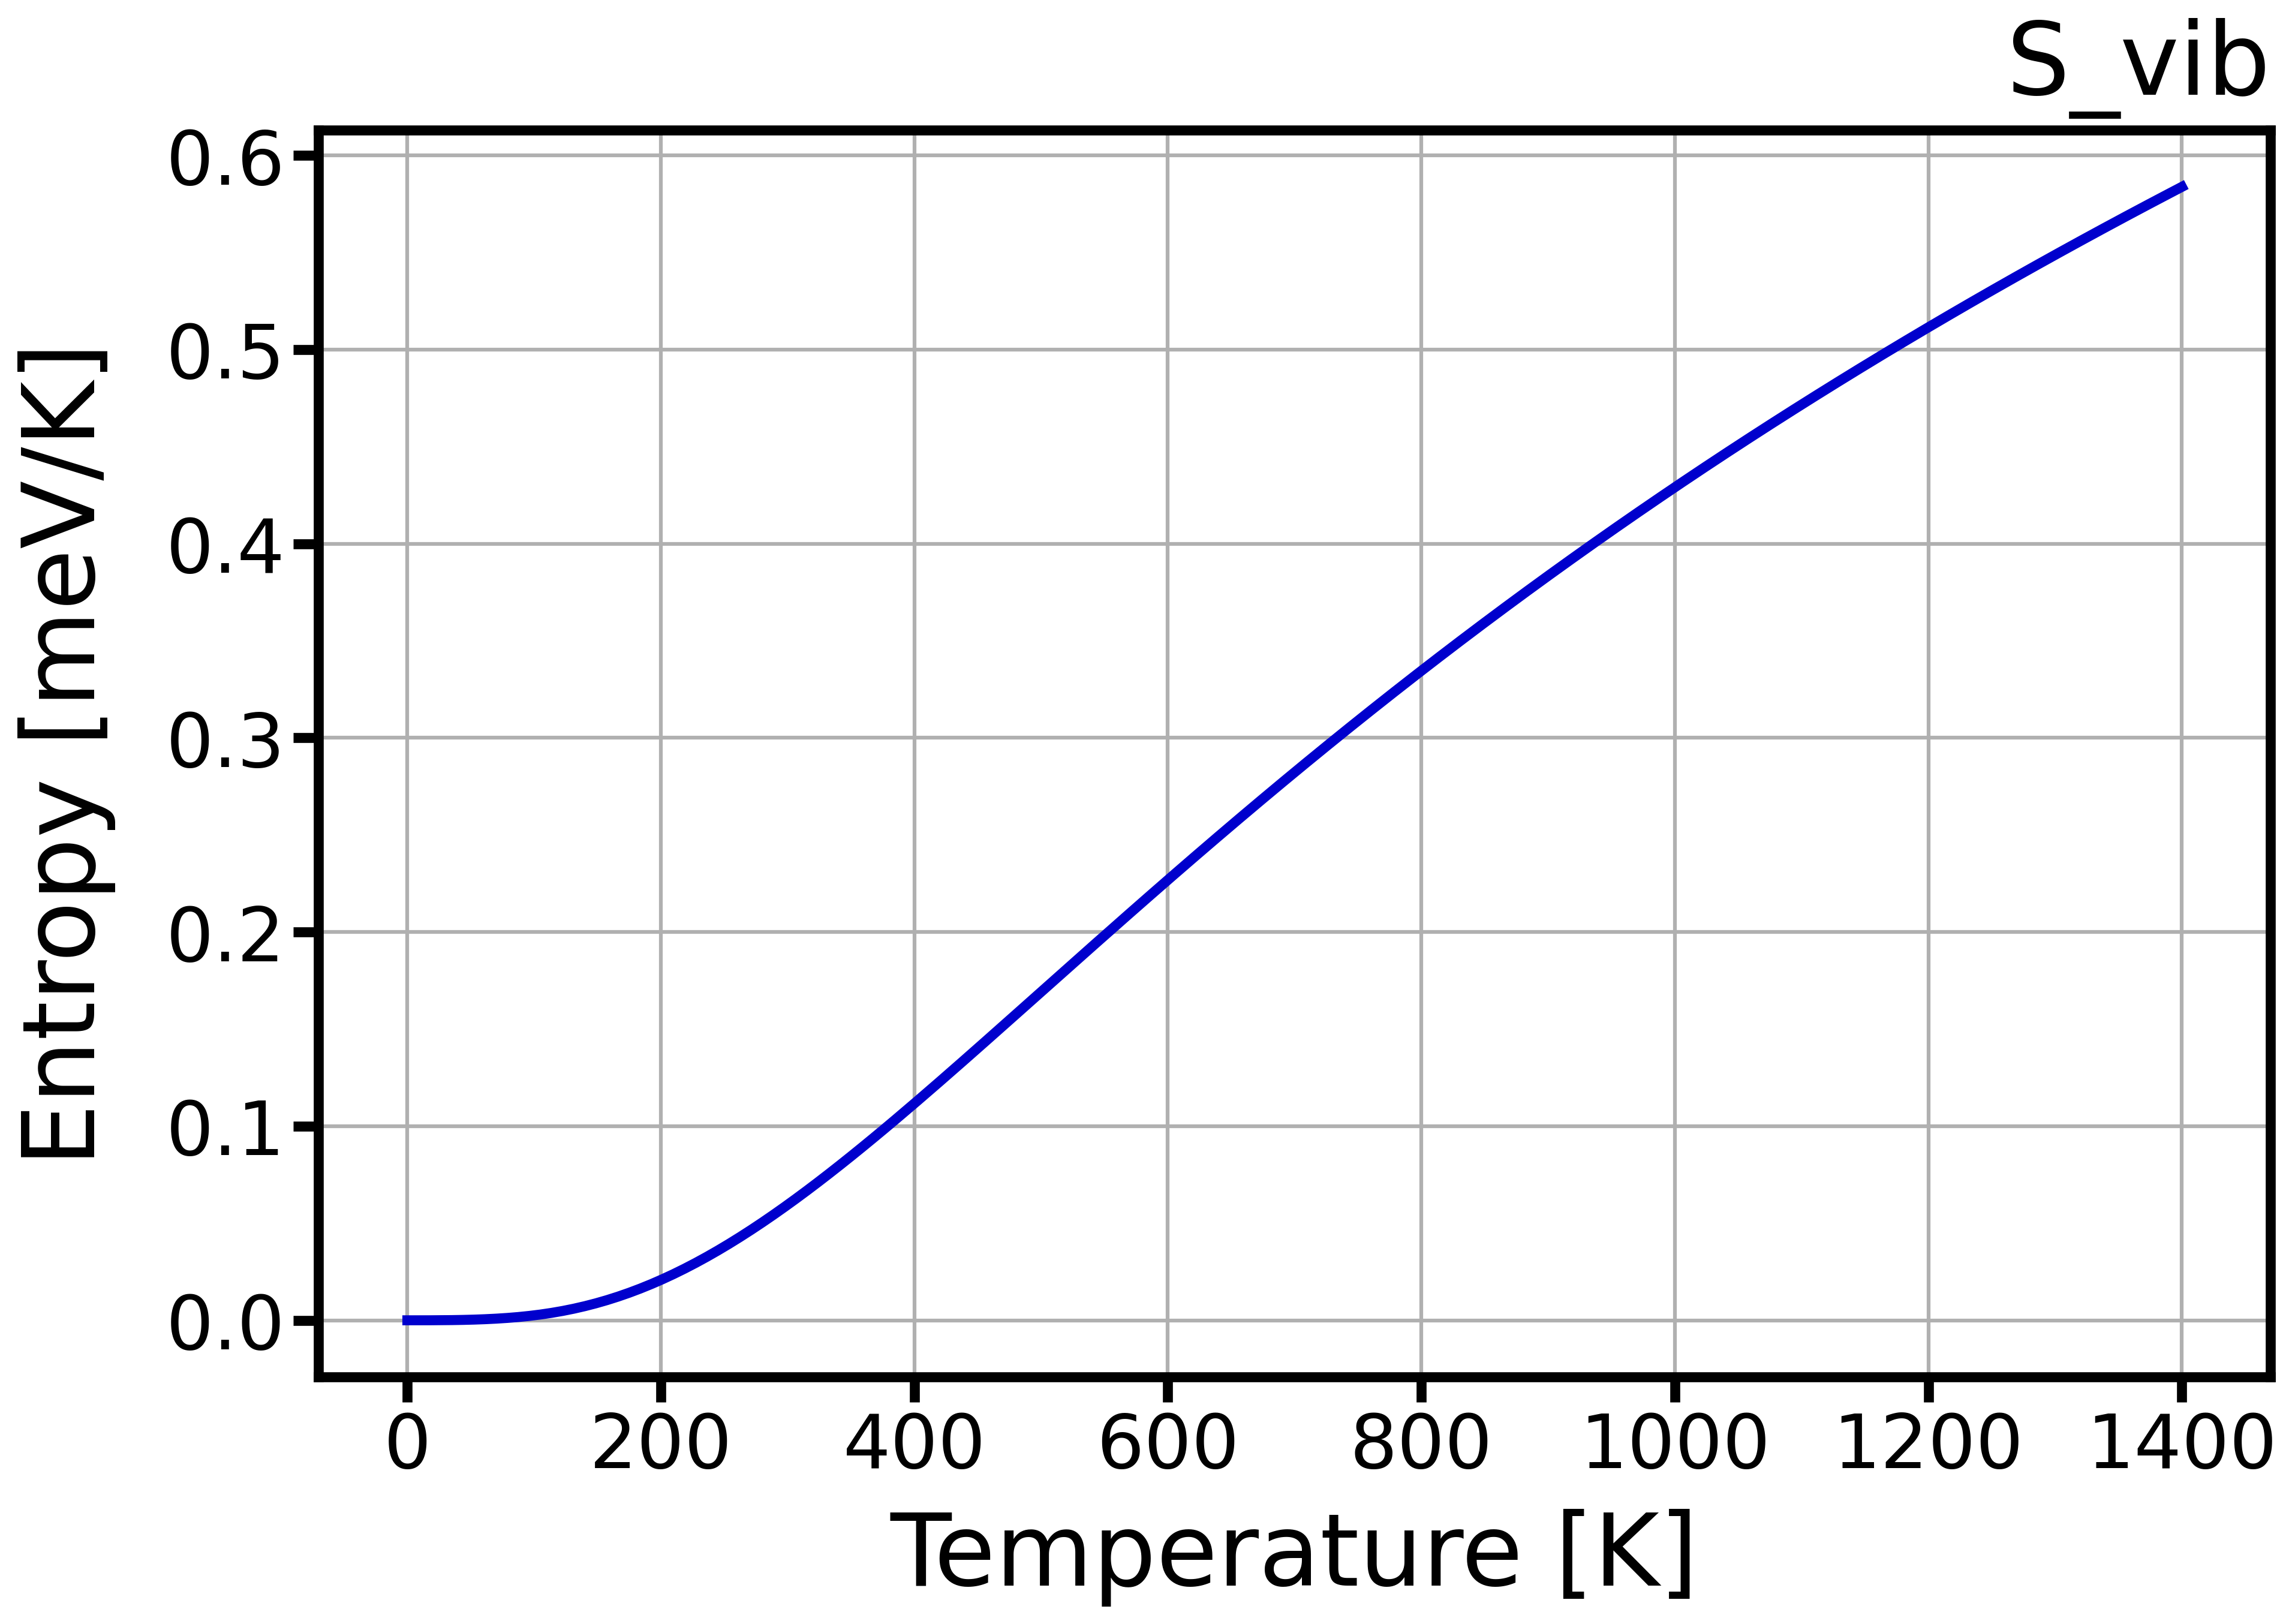
</figure>

<figure>
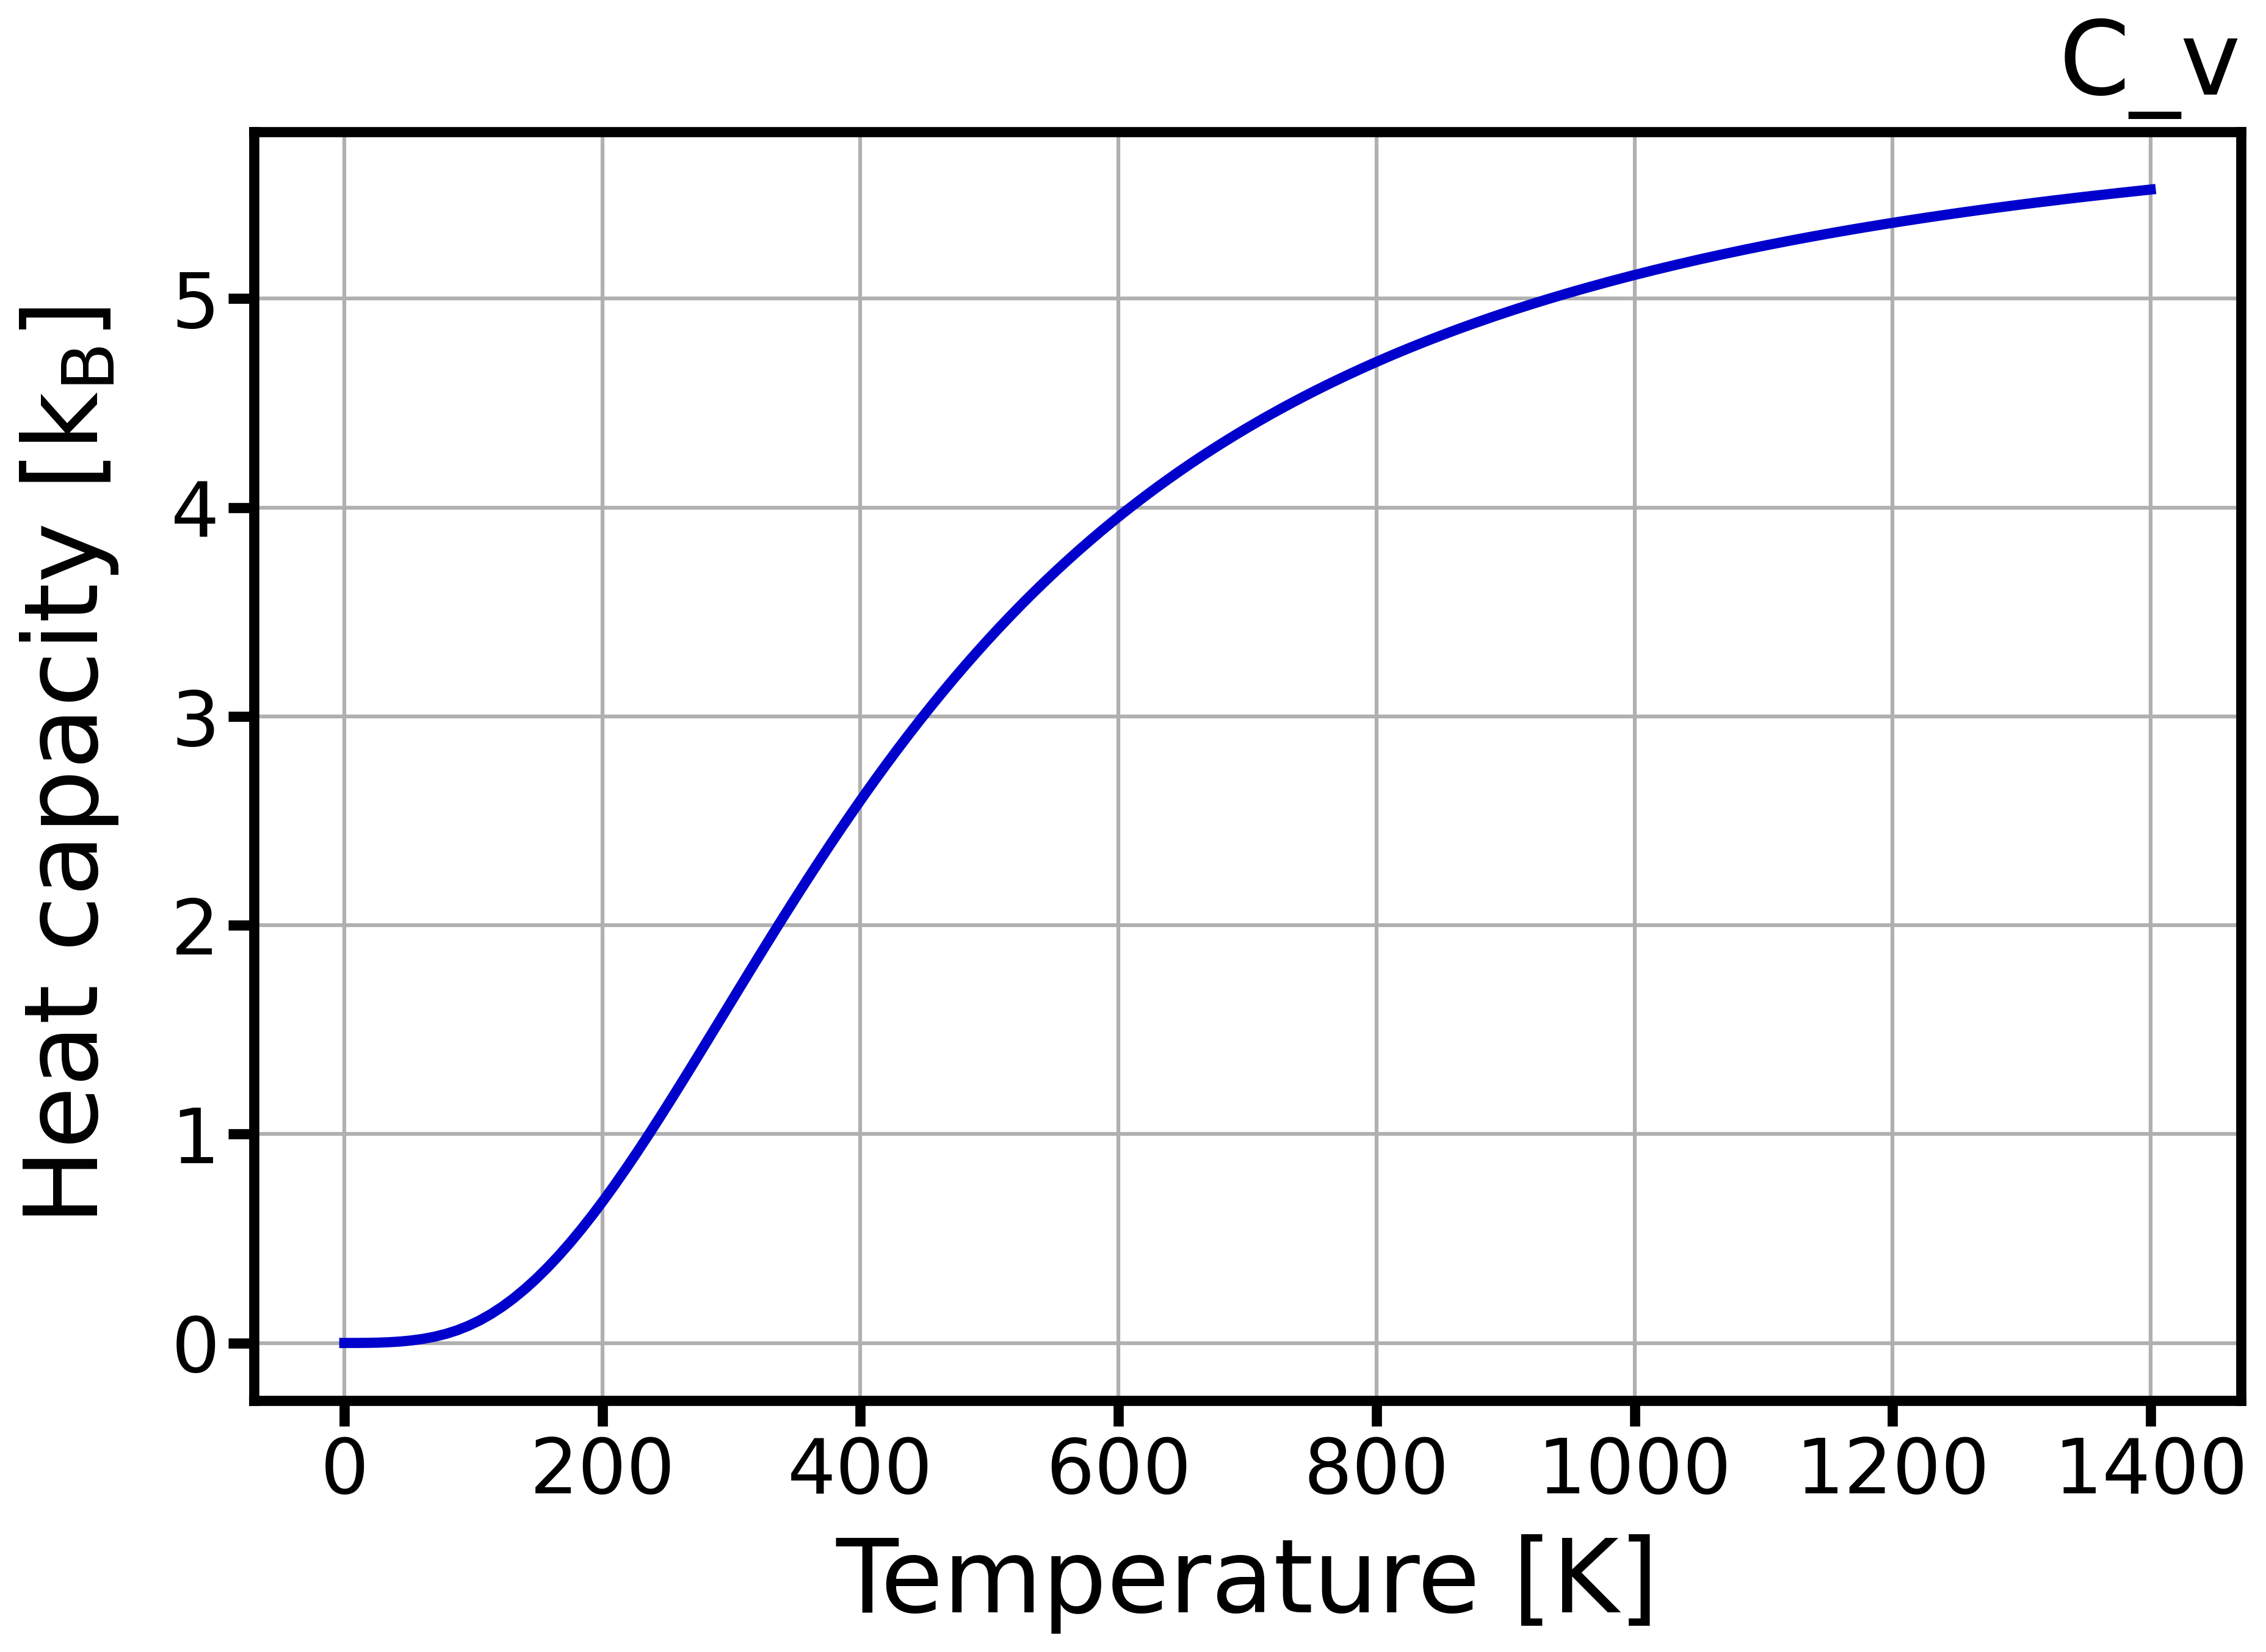
</figure>

<hr style="border:1px solid #DDD"> </hr> 
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Show converged plots</span></strong>
</summary>
    
```bash
Zero-point energy is 3.5905e-01 [eV]
```    
    
<figure>
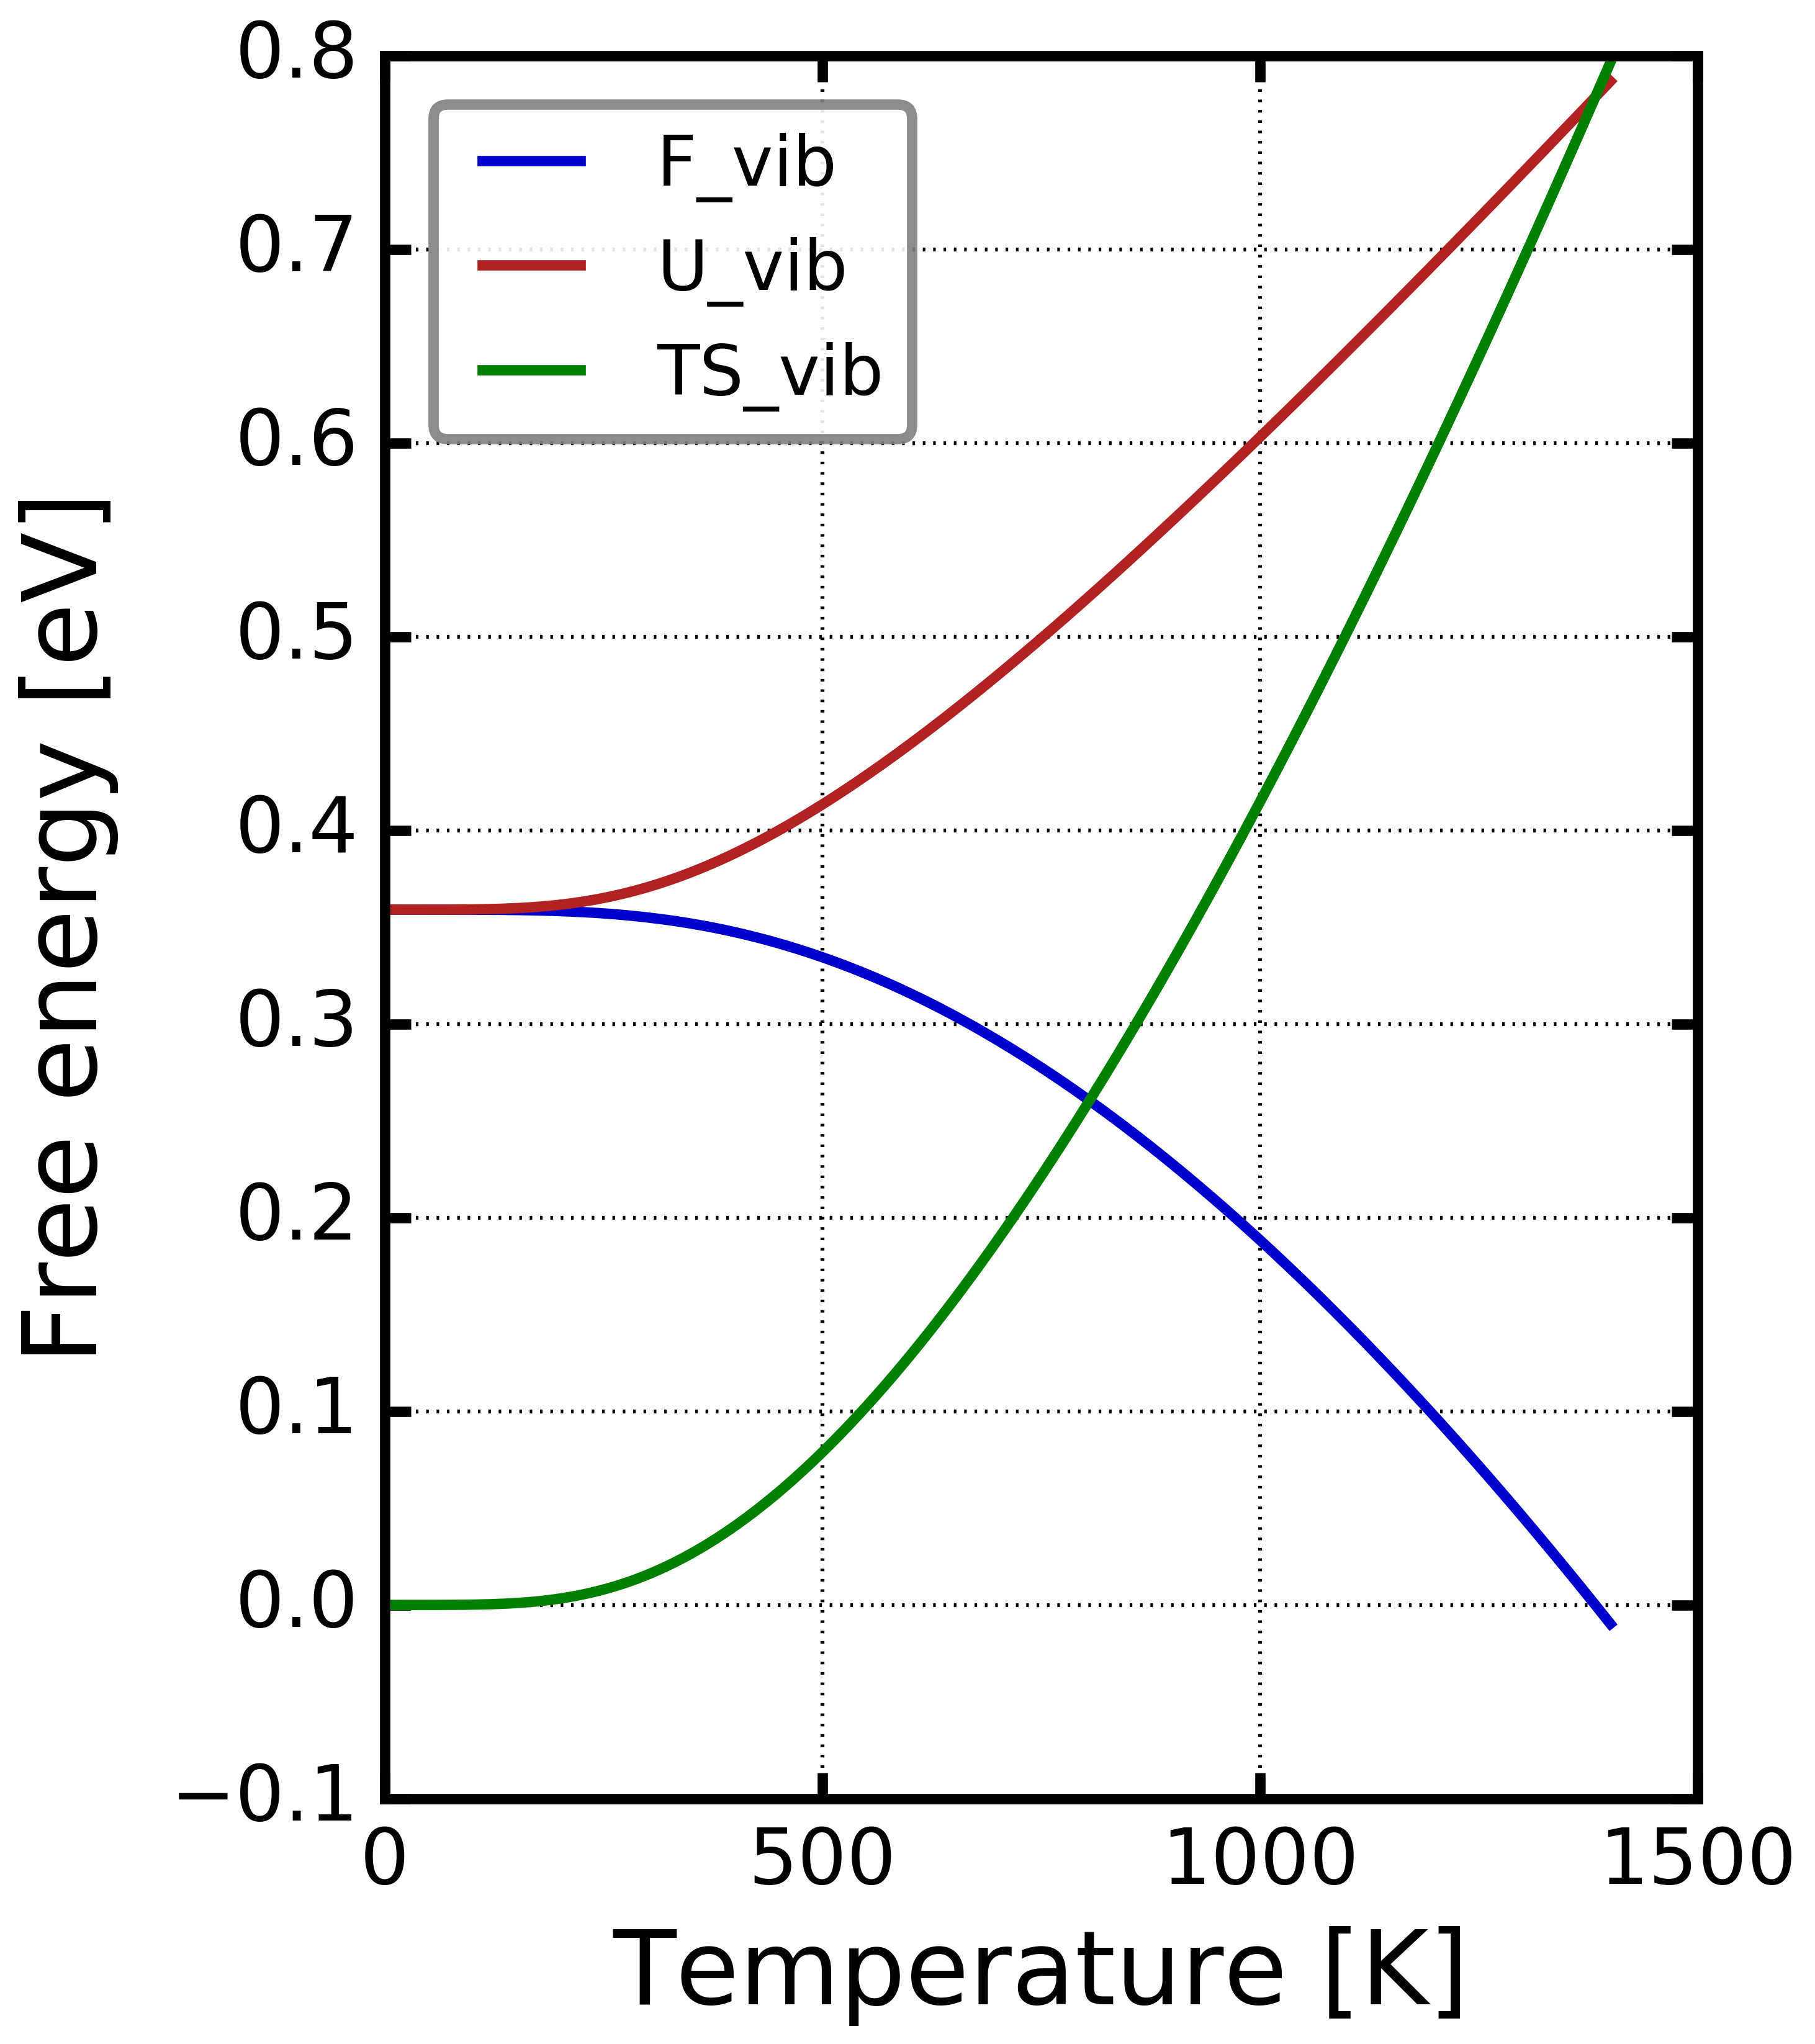
</figure>   
    
<figure>
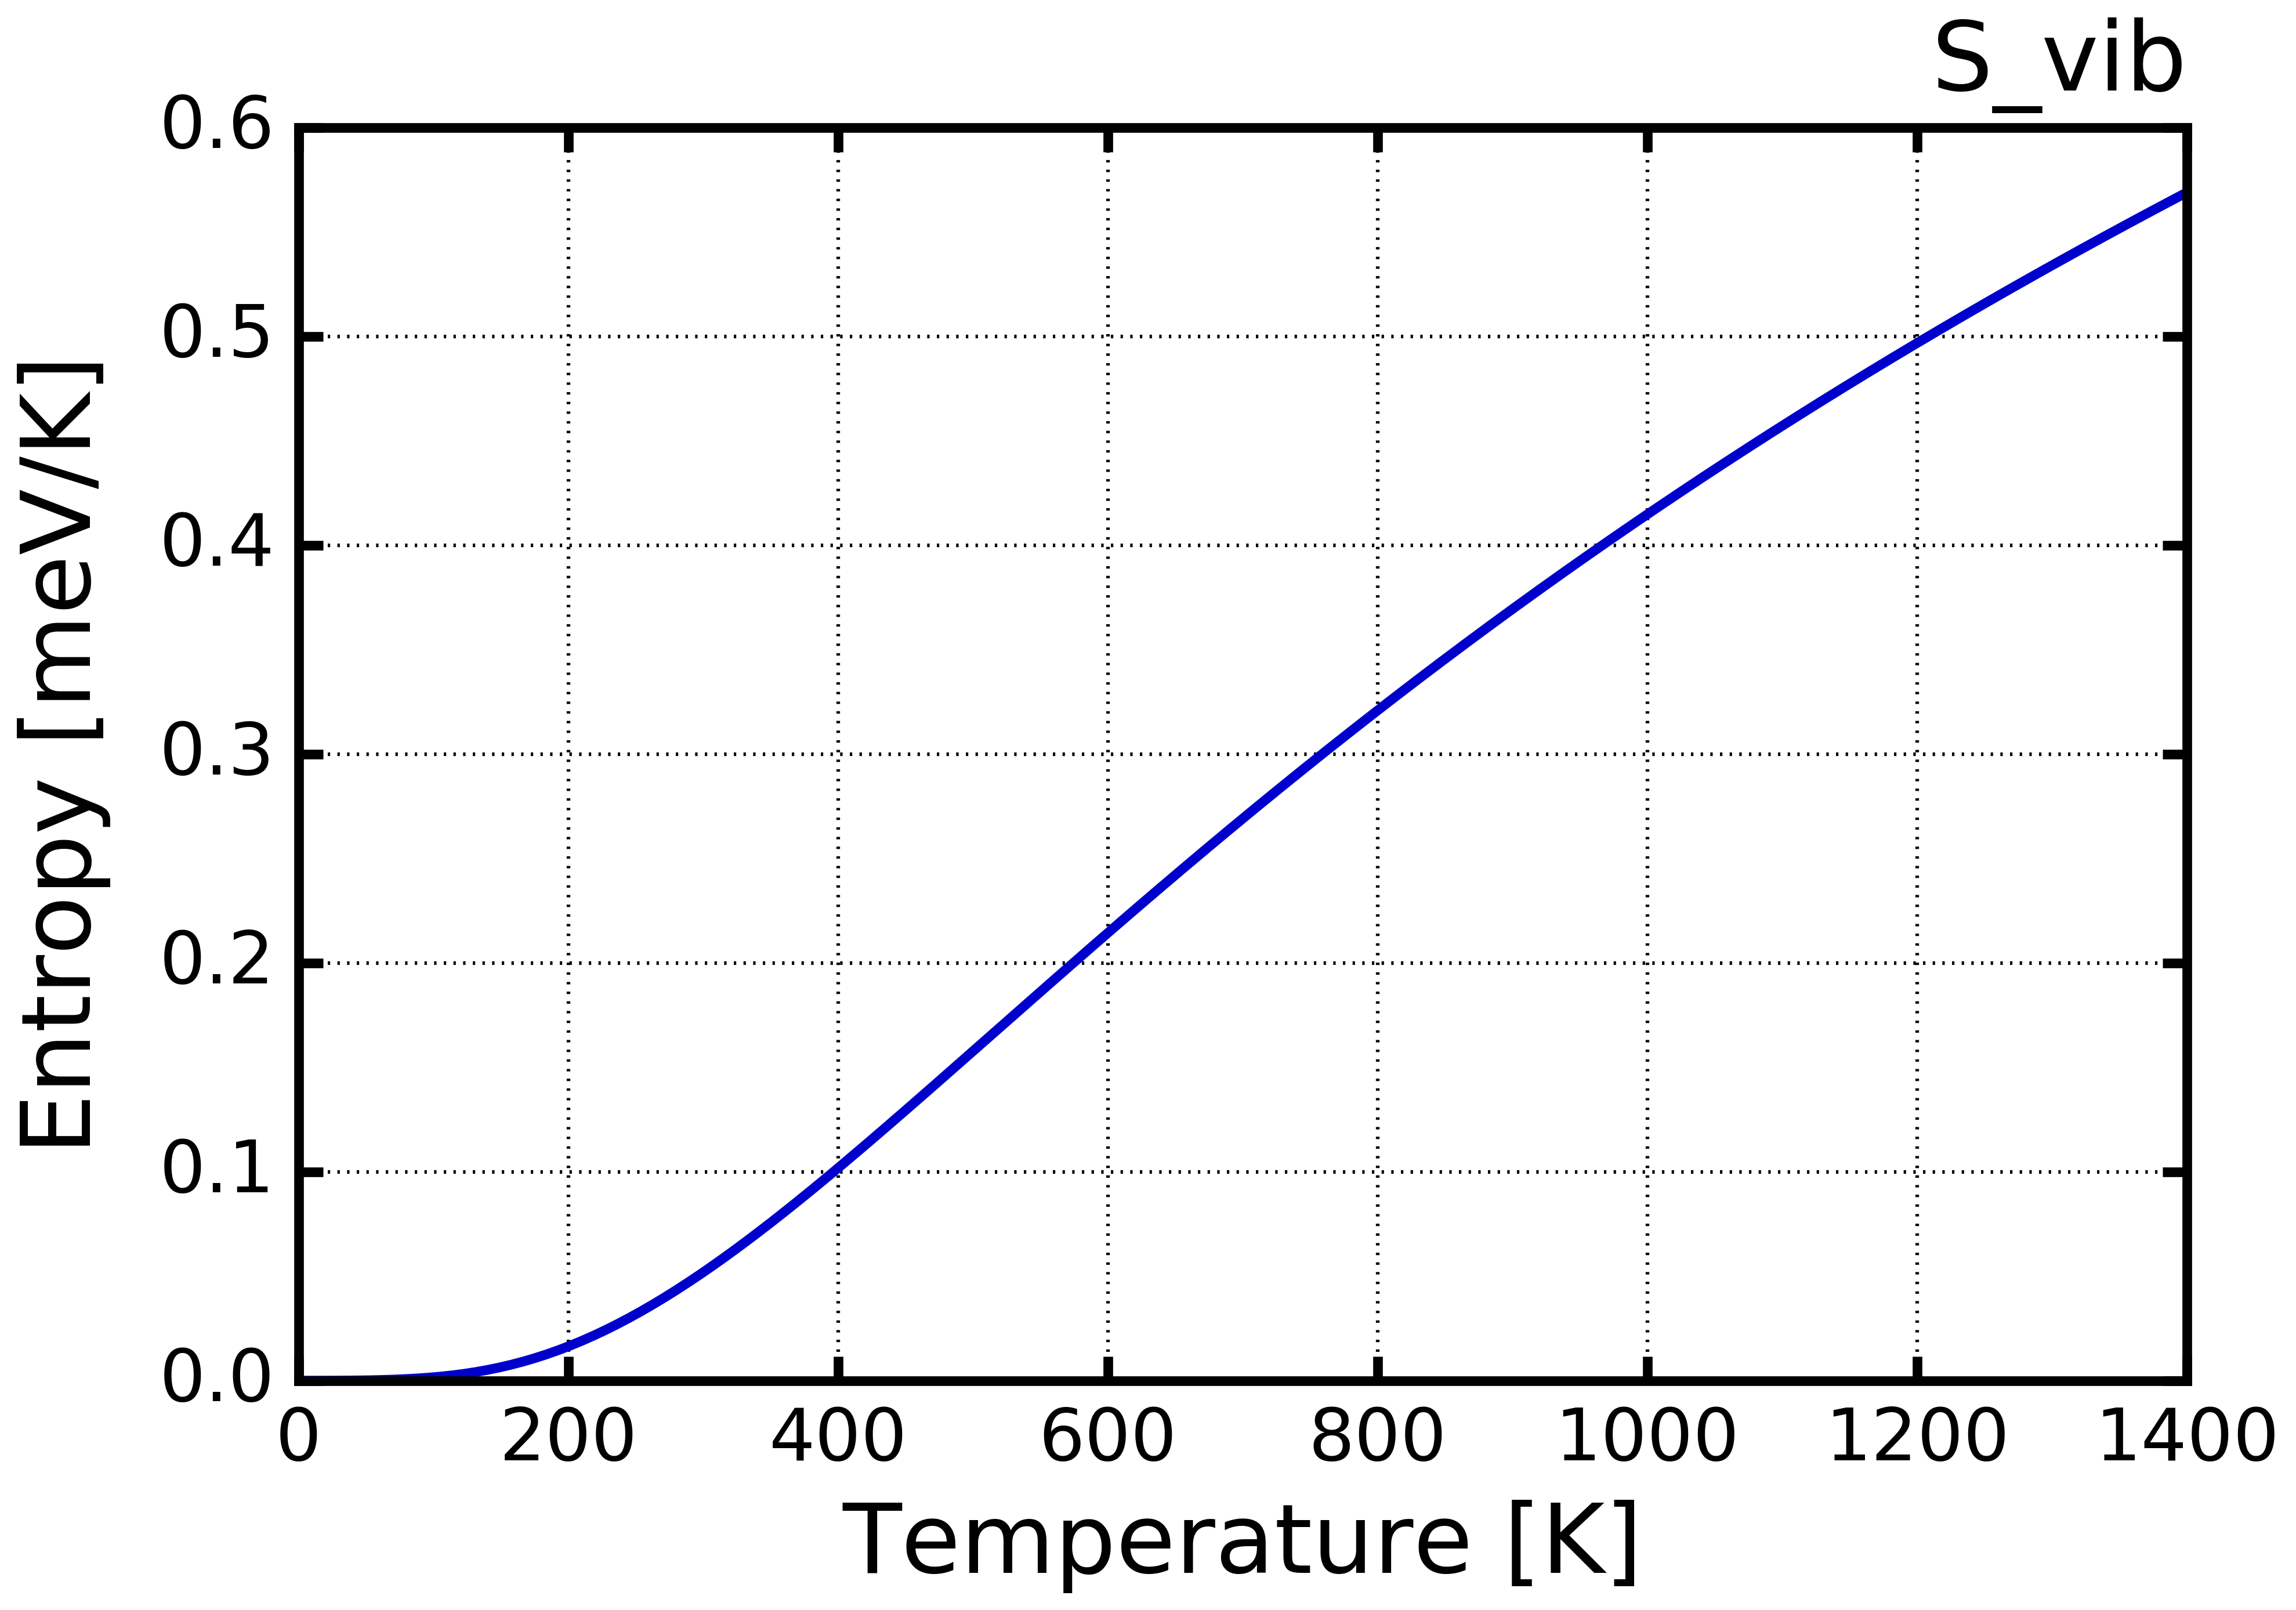
</figure>    
  
<figure>
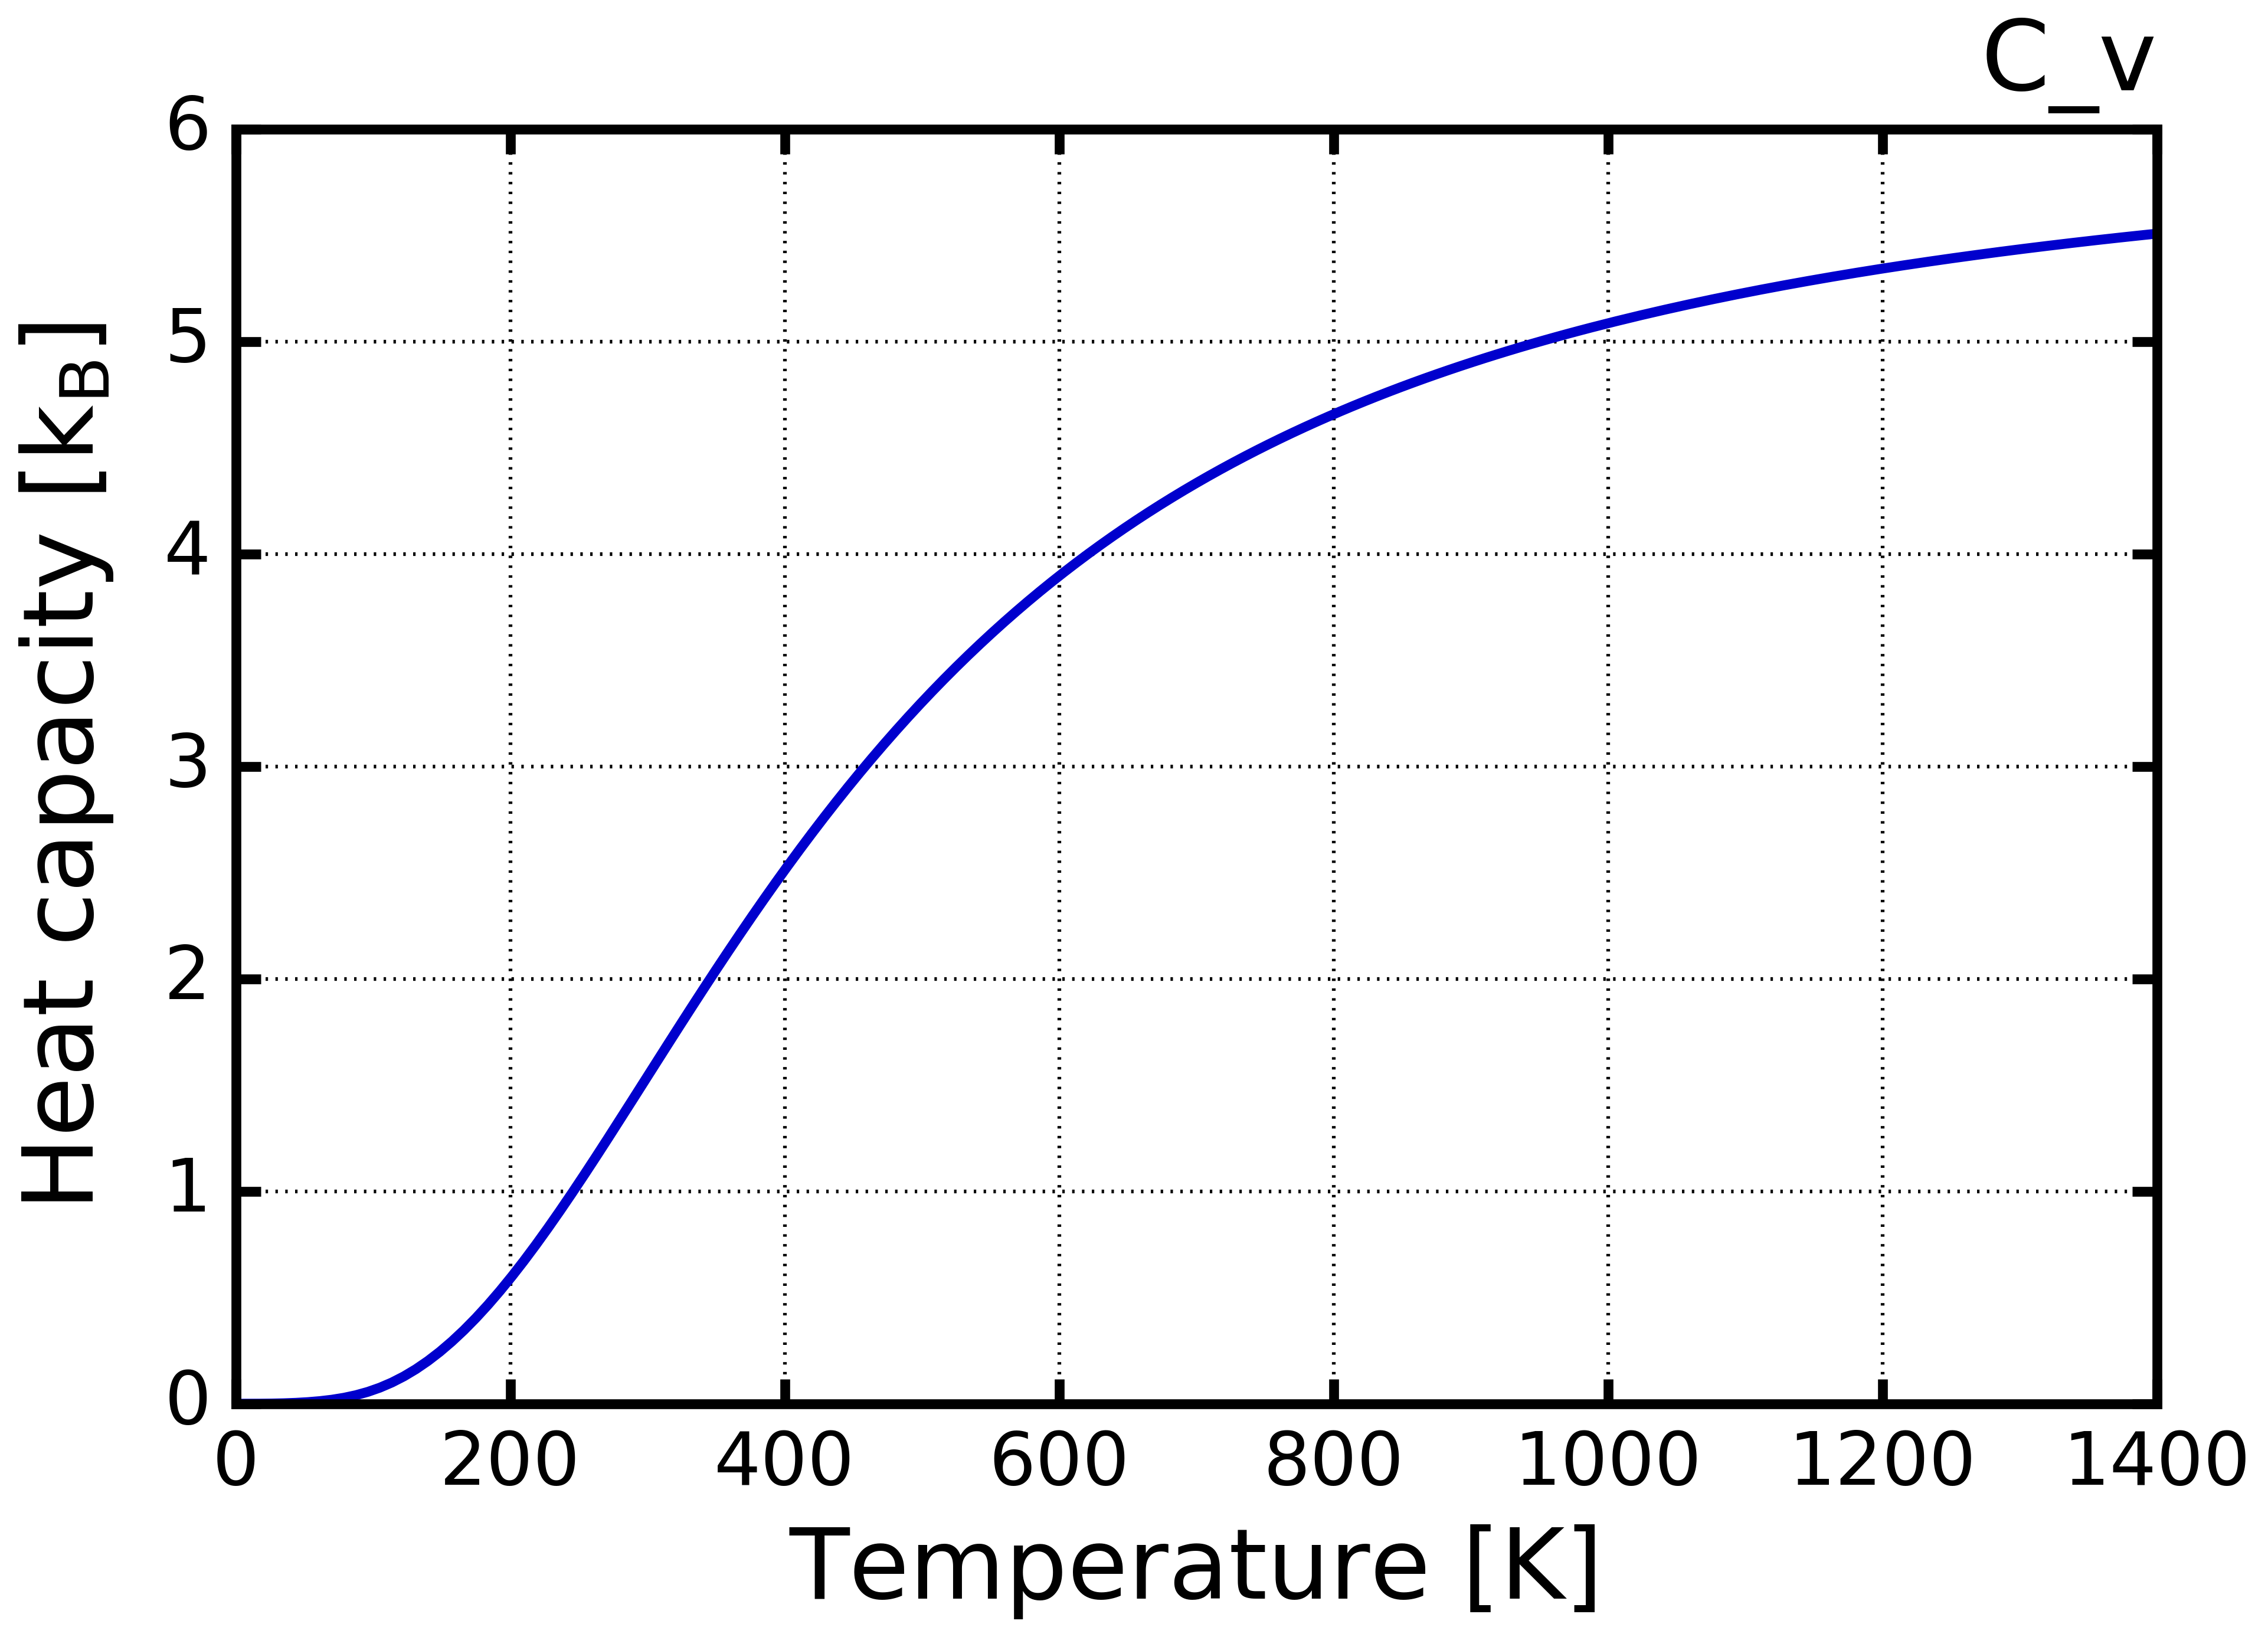
</figure>    
</details>
<hr style="border:1px solid #DDD"> </hr> 
    

**Phonon-dispersion relations**

Phonon-dispersion relations can also be easily calculated. Phonon eigenvalues are computed along a path through the Brillouin zone and written for later plotting. This path can be specified within the element <code><span style="color:green">phonondispplot</span></code> (reciprocal lattice coordinates) in the following way (a path between the points **Γ**-(**K**)-**X**-**Γ**-**L** is specified in the present example).

```xml
...     
      <phonondispplot>
         <plot1d>
            <path steps="400">
               <point coord="1.0     0.0     0.0" label="Gamma"/>
               <point coord="0.625   0.375   0.0" label="K"/>
               <point coord="0.5     0.5     0.0" label="X"/>
               <point coord="0.0     0.0     0.0" label="Gamma"/>
               <point coord="0.5     0.0     0.0" label="L"/> 
            </path>
         </plot1d>
      </phonondispplot>
...

```

This codelet is to be included within the element <code><span style="color:green">phonons</span></code>, same as for <code><span style="color:green">qpointset</span></code> and <code><span style="color:green">phonondos</span></code> above. Of course, one can reuse data of a previous phonon calculation by adding <code><span style="color:mediumblue">do</span>=<span style="color:firebrick">"skip"</span></code> to the elements <code><span style="color:green">phonons</span></code> and <code><span style="color:green">groundstate</span></code>.

In [10]:
# The following lines modify the input.xml using Python
parsed_input = ExcitingInputXML.from_xml('./run_diamond_phonons/input.xml')

phonons = {'do': 'skip',
           'method': 'dfpt',
           'ngridq': [2, 2, 2],
           'polar': False,
           'phonondispplot': {'plot1d': {'path': {'steps': 400,
                                                  'point': [{'coord': [1.0, 0.0, 0.0], 'label': 'Gamma'},
                                                            {'coord': [0.625, 0.375, 0.0], 'label': 'K'},
                                                            {'coord': [0.5, 0.5, 0.0], 'label': 'X'},
                                                            {'coord': [0.0, 0.0, 0.0], 'label': 'Gamma'},
                                                            {'coord': [0.5, 0.0, 0.0], 'label': 'L'}]}}}}

parsed_input.phonons = ExcitingPhononsInput(**phonons)

parsed_input.write('./run_diamond_phonons/input.xml')

In [11]:
%%bash
cd run_diamond_phonons
python3 -m excitingscripts.execute.single
cd ..

This run produces the file **PHDISP.OUT** that contains the phonon eigenvalues along the path specified in the input and can be plotted directly.

The script **`excitingscripts.plot.band_structure`** (see [**The python script "plot.band_structure"**](https://www.exciting-code.org/the-python-script-plot.band_structure)), can be used to produce a plot of the phonon-dispersion relations.

In [12]:
%%bash
cd run_diamond_phonons
python3 -m excitingscripts.plot.band_structure -p -e 0 1400
cd ..

<figure>
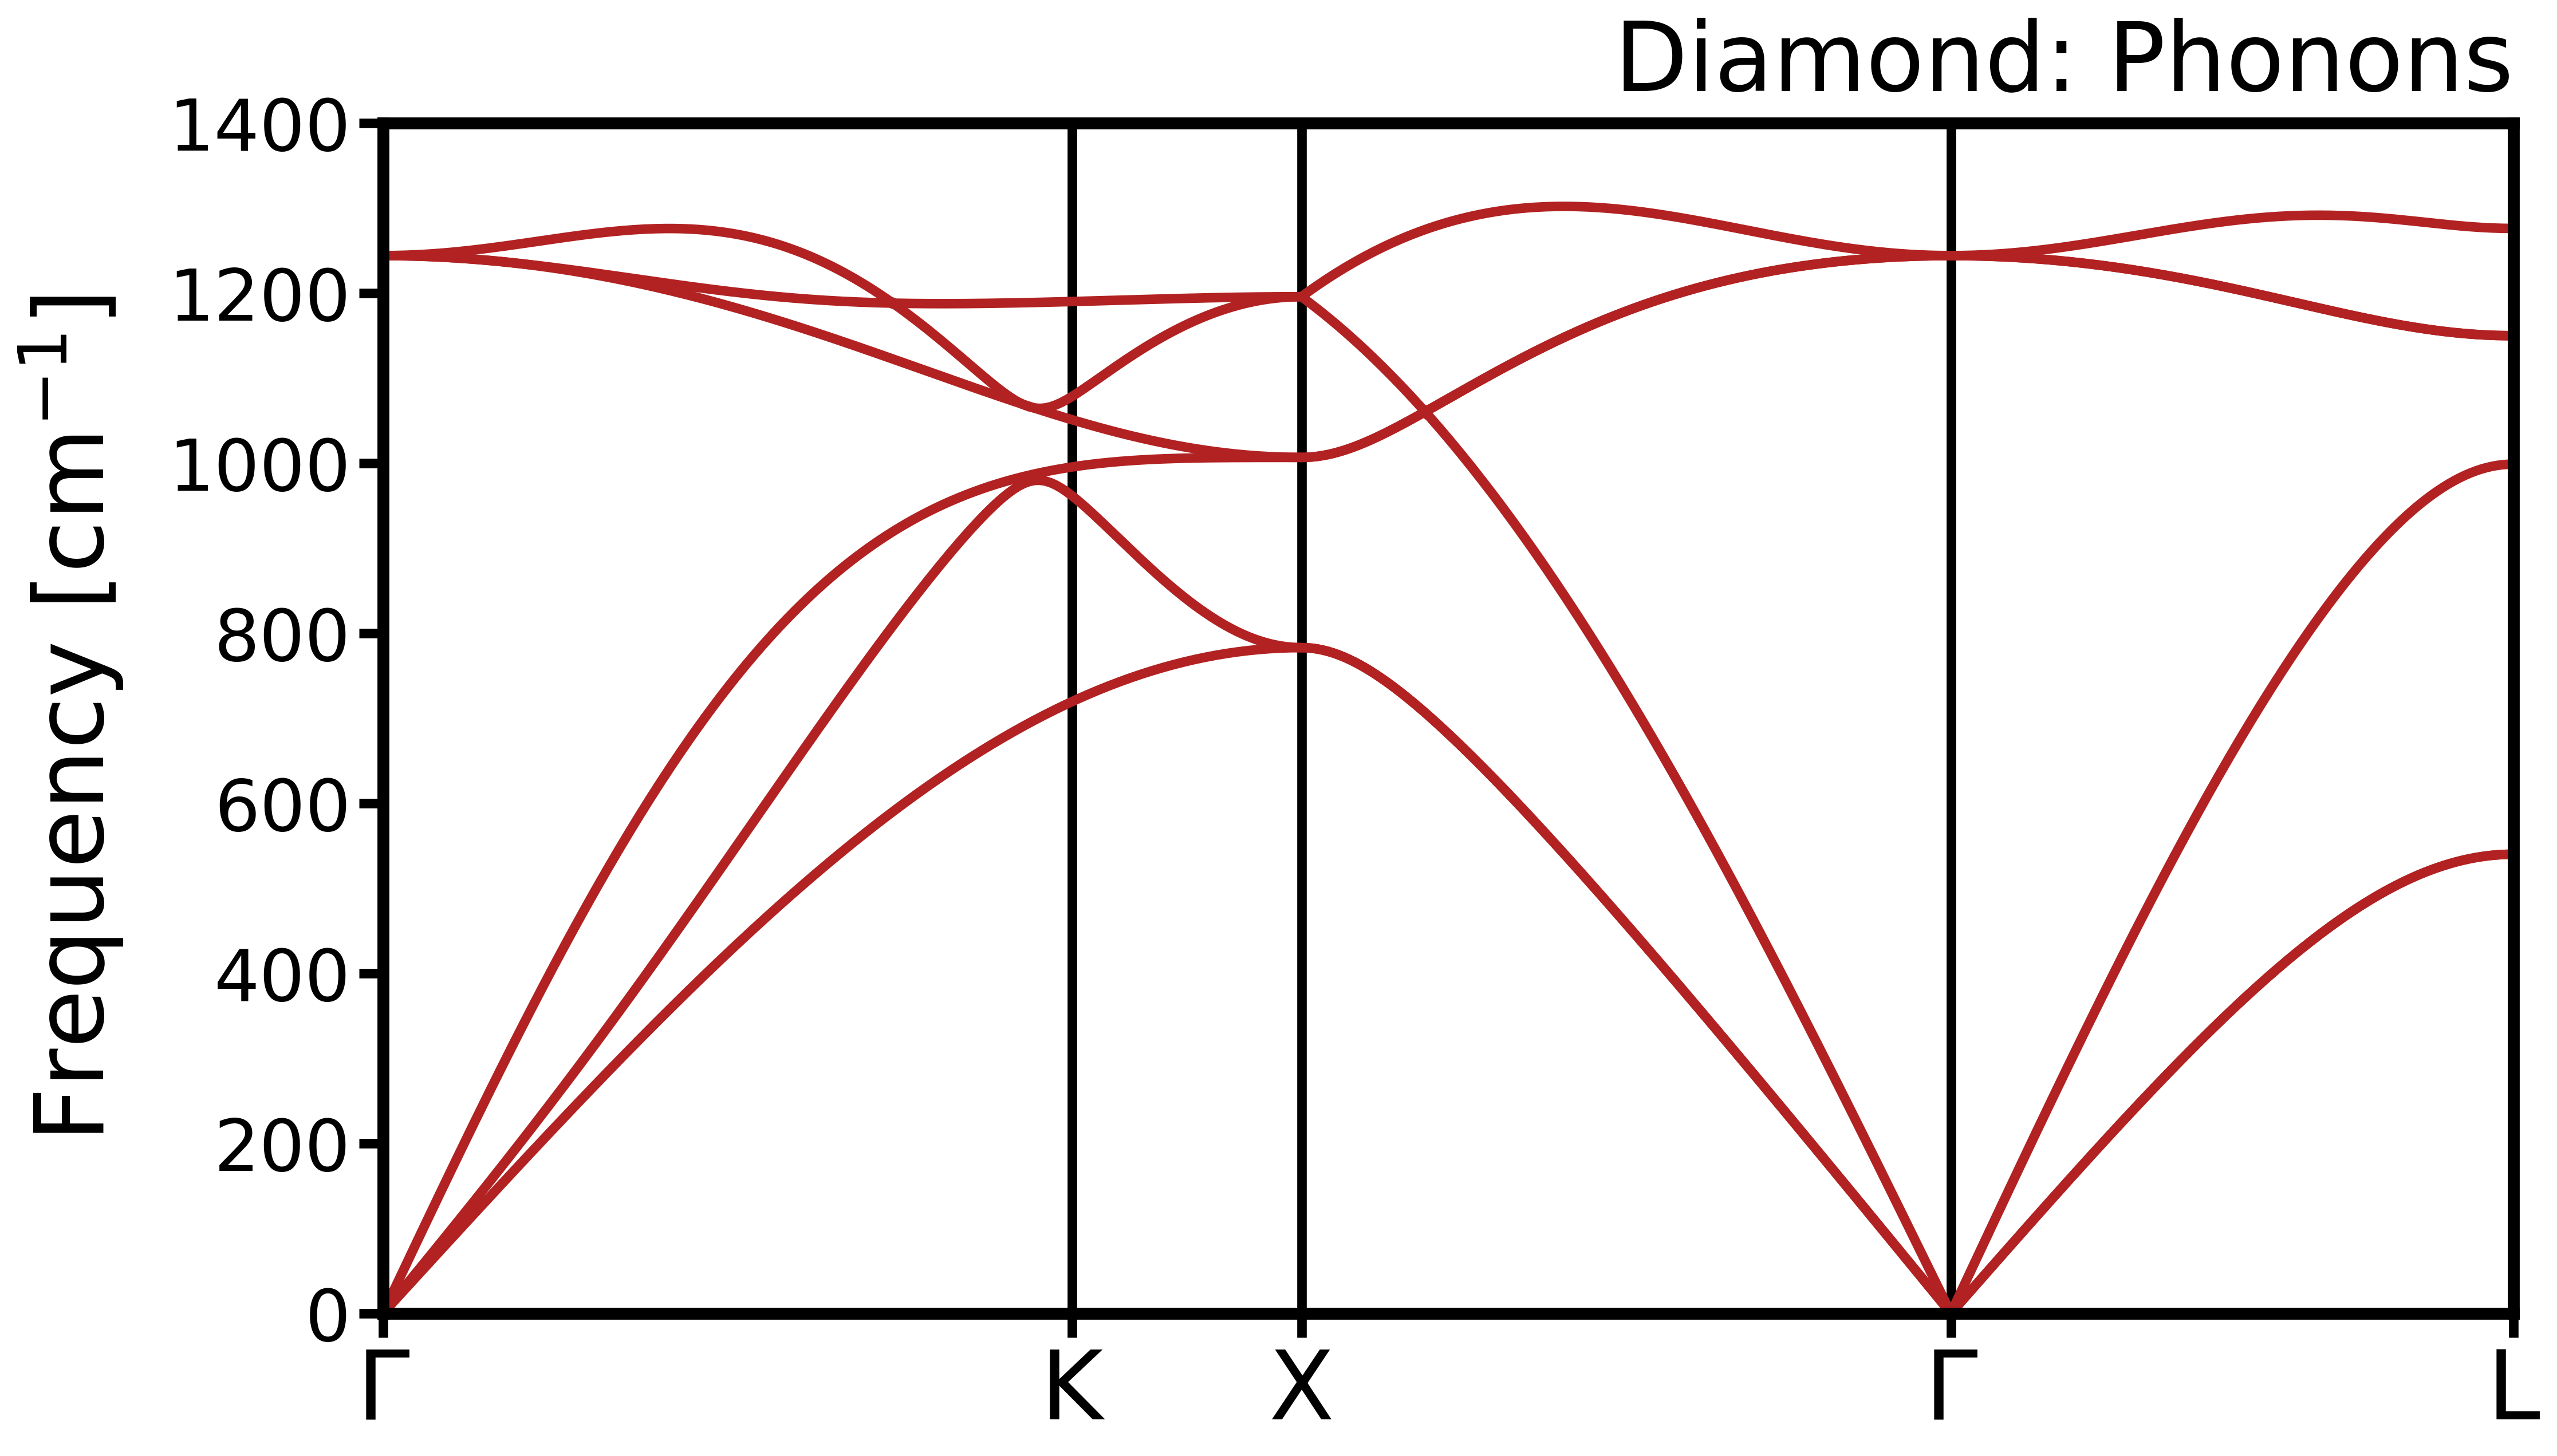
</figure>

<hr style="border:1px solid #DDD"> </hr> 
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Show converged plot</span></strong>
</summary>
    
Using the path <strong>Γ</strong>-(<strong>K</strong>)-<strong>X</strong>-<strong>Γ</strong>-<strong>L</strong> this result is obtained. 
    
<figure>
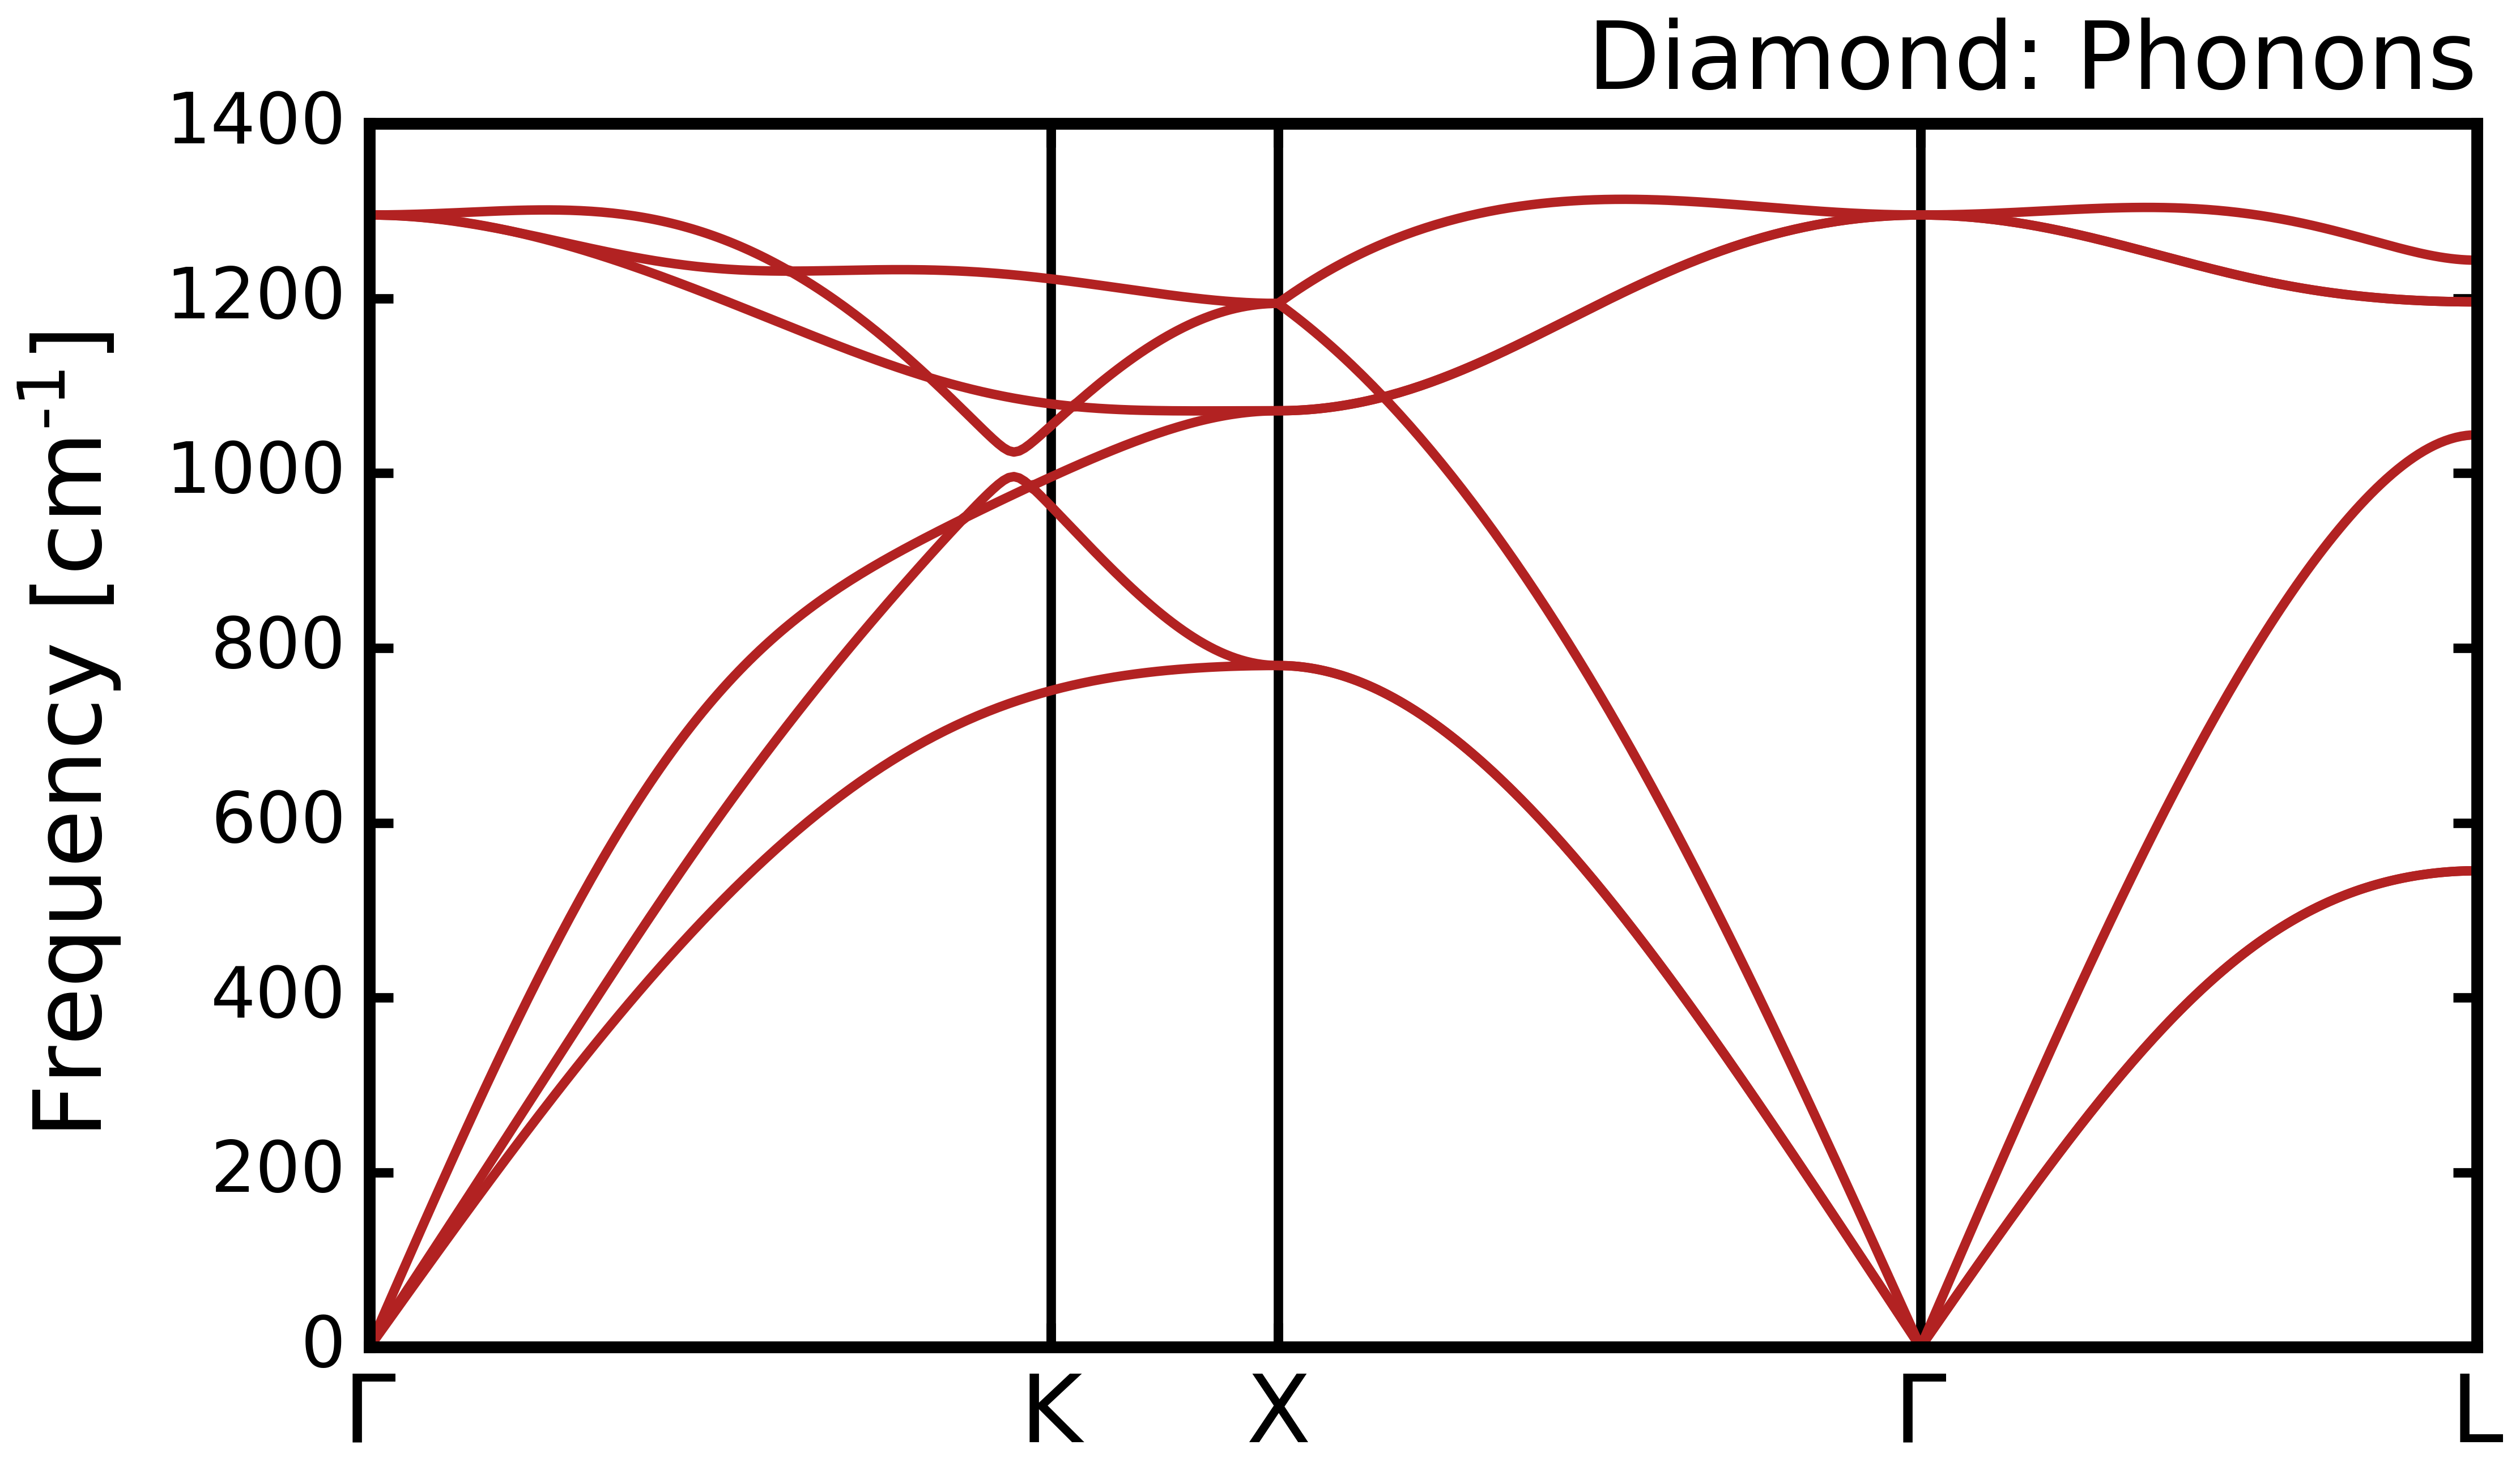
</figure>
    
</details>
<hr style="border:1px solid #DDD"> </hr> 
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Show converged plot with standard path</span></strong>
</summary>
    
A complete visualization of the phonon dispersion of diamond can be achieved using the standard path in reciprocal space for fcc crystals introduced by <strong>[Setyawan and Curtarolo, Comp. Mat. Sci. 49, 299-312 (2010)](https://materials.duke.edu/auro/AUROARTICULA/j.commatsci.2010.05.010.pdf)</strong>.
The coordinates of the high-symmetry points of the first Brillouin zone belonging to this path are given below.
    
```xml
...     
      <phonondispplot>
         <plot1d>
            <path steps="400">
               <point coord="0.000000 0.000000 0.000000" label="Gamma"/>
               <point coord="0.500000 0.000000 0.500000" label="X"/>
               <point coord="0.500000 0.250000 0.750000" label="W"/>
               <point coord="0.375000 0.375000 0.750000" label="K"/>
               <point coord="0.000000 0.000000 0.000000" label="Gamma"/>
               <point coord="0.500000 0.500000 0.500000" label="L"/>
               <point coord="0.625000 0.250000 0.625000" label="U"/>
               <point coord="0.500000 0.250000 0.750000" label="W"/>
               <point coord="0.500000 0.500000 0.500000" label="L"/>
               <point coord="0.375000 0.375000 0.750000" label="K"/>    
            </path>
         </plot1d>
      </phonondispplot>
...

```     
The standard path is visualized in the following figure:    
    
<figure>
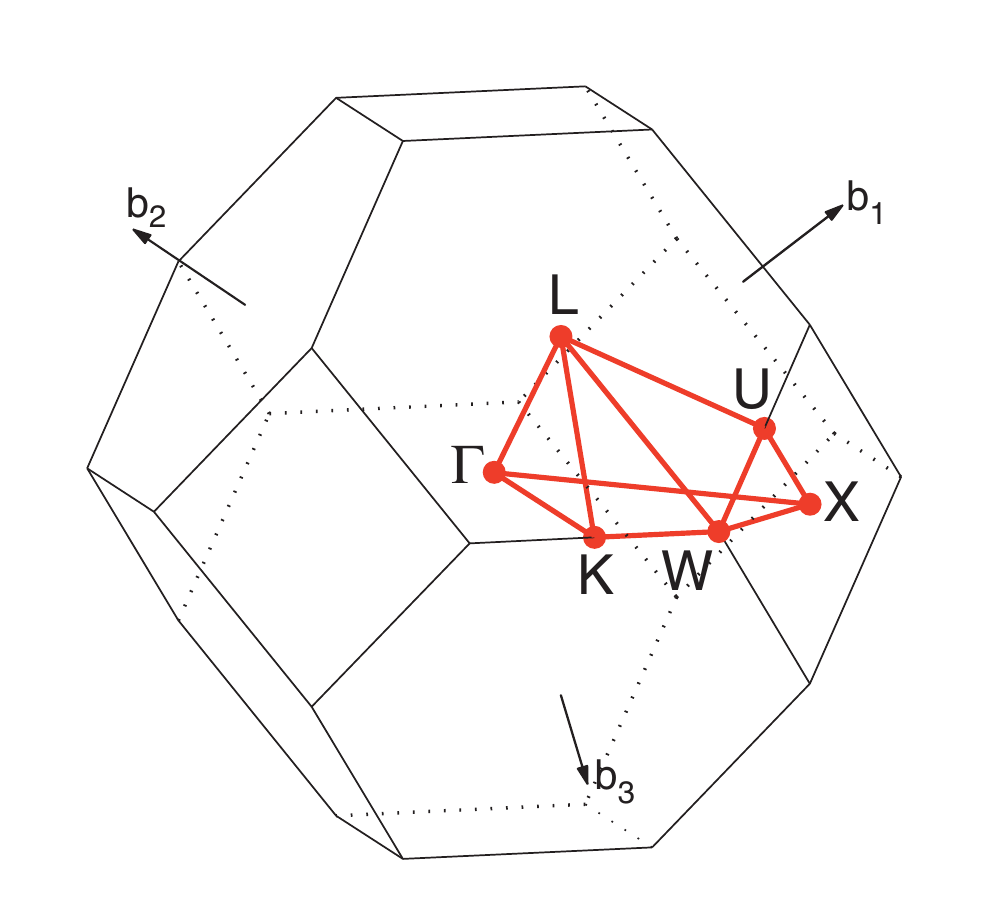
</figure>    

  Using these settings, the following plot is obtained.
    
<figure>
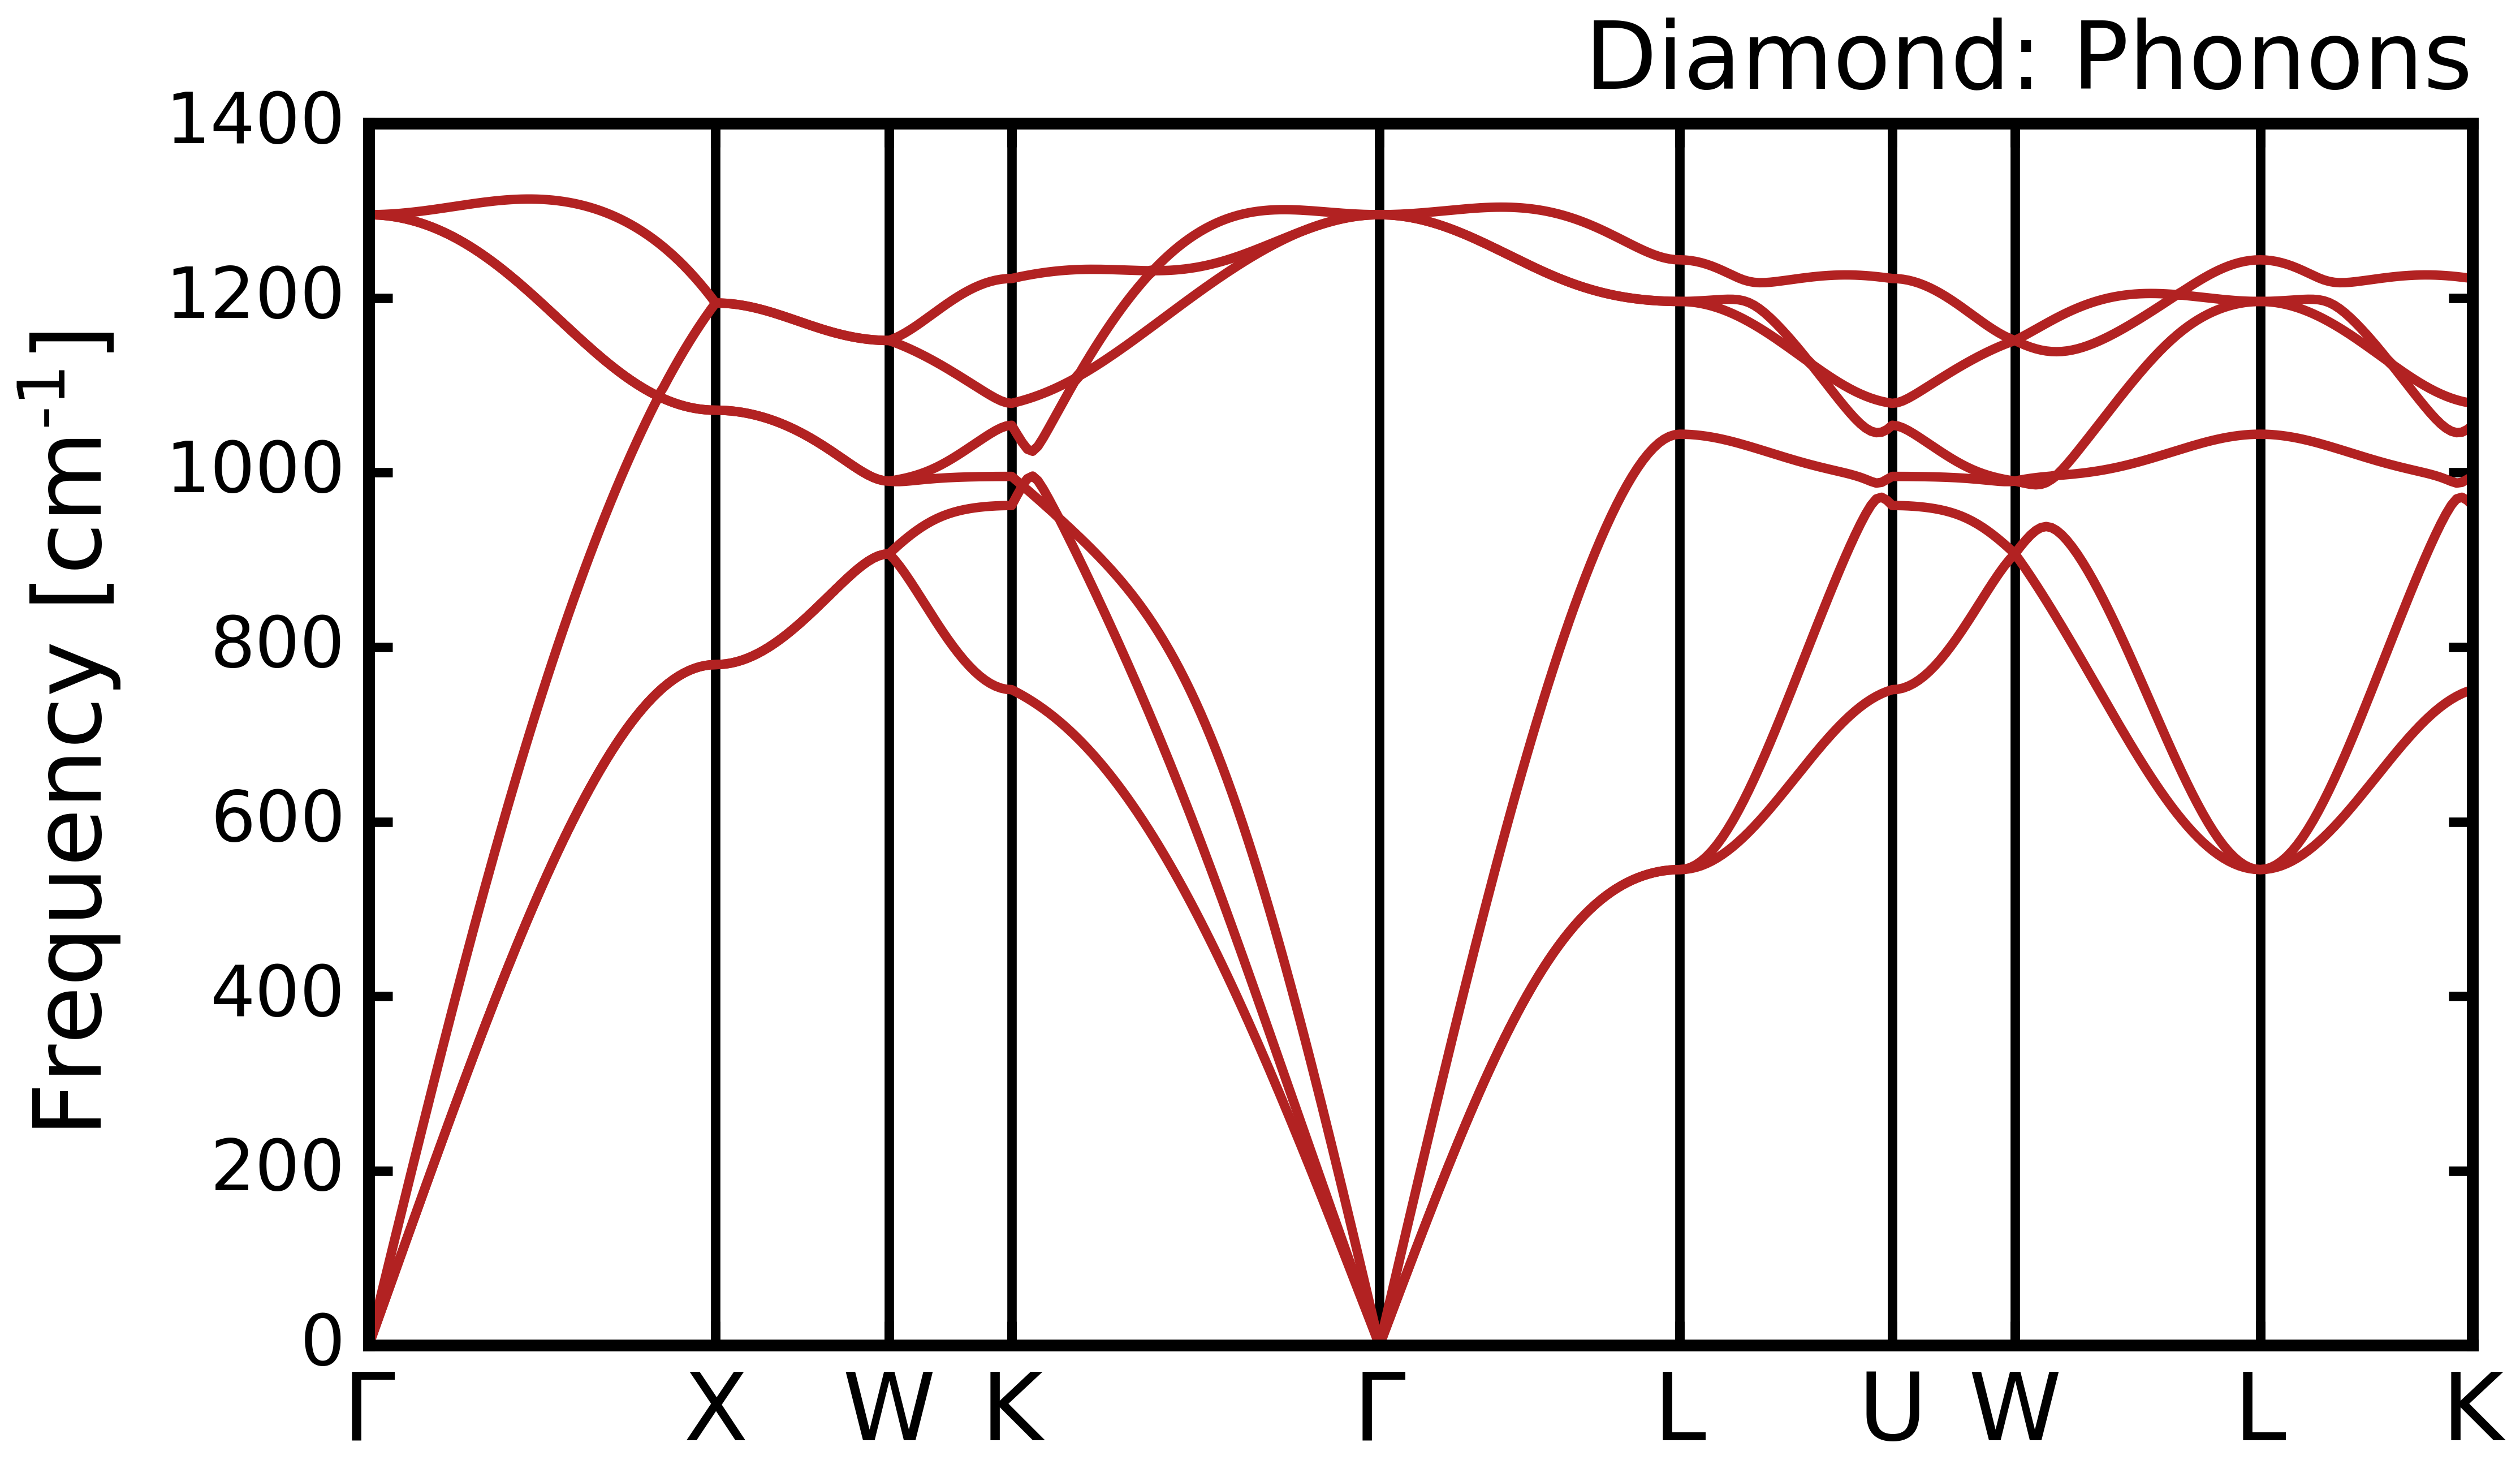
</figure>    
    
</details>    
<hr style="border:1px solid #DDD"> </hr> 

**Other useful features**

<hr style="border:1px solid #DDD"> </hr> 
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Show more features</span></strong>
</summary>

- The element <code><span style="color:green">interpolate</span></code> triggers an interpolation on a given **q**-point grid. For every point in the grid, which may be offset from the origin, phonon frequencies and (optionally) eigenvectors can be obtained, and written to the file **PHONON_INTERPOLATE.OUT**.
- The element <code><span style="color:green">reformatdynmat</span></code> (without any attributes) requests an output of the dynamical matrix in the form of a 3×3 block for each combination of atoms and each **q**-point (file **DYNMAT.OUT**).
- The file **DYNMAT_SUMRULE.OUT** contains the dynamical matrix (in 3×3 blocks as above) after applying a correction, such that the matrix for **q**=0 satisfies the acoustic sum rule. This ensures that the **q**=0 dynamical matrix has 3 zero eigenvalues. The files **DYNMAT_SYM.OUT** and **DYNMAT_SYM_SUMRULE.OUT** contain the symmetrized matrices.    

See **[Input Reference](https://www.exciting-code.org/home/about/input-reference)** for further details.     
</details>
<hr style="border:1px solid #DDD"> </hr>    

<a id='3'></a>

### <span style="color:#15317E">3. Phonon Properties for for Cubic Boron Nitride (cBN)</span>

In this part of the tutorial we will calculate phonons for cubic boron nitride in the zincblende structure to demonstrate the treatment of **polar materials**. In order to start, create a new working directory, *e.g.*, **run_cBN_phonons**.

In [13]:
%%bash
mkdir -p run_cBN_phonons

<a id='3.1'></a>
**<span style="color:#15317E">3.1 Set-up the Input File and Run the Calculation</span>**

Create the **input.xml** file with the following content.

<span class="cBN_PHONONS"></span>
```xml
<input>
 
   <title>cBN: Phonons</title>
 
   <structure speciespath="$EXCITINGROOT/species">
 
      <crystal scale="6.850832">
         <basevect> 0.5  0.5  0.0 </basevect>
         <basevect> 0.5  0.0  0.5 </basevect>
         <basevect> 0.0  0.5  0.5 </basevect>
      </crystal>
 
      <species speciesfile="B.xml" rmt="1.25">
         <atom coord="0.00 0.00 0.00" />
      </species>
 
      <species speciesfile="N.xml" rmt="1.25">
         <atom coord="0.25 0.25 0.25" />
      </species>
 
   </structure>
 
   <groundstate 
      do="fromscratch"
      ngridk="4 4 4"
      swidth="0.0001"
      rgkmax="4.0"
      gmaxvr="14"
      tforce="true">
      <libxc correlation="XC_GGA_C_PBE" exchange="XC_GGA_X_PBE"/>
   </groundstate>
 
   <phonons
      do="fromscratch"
      method="dfpt"
      ngridq="2 2 2"
      polar="true">
      <qpointset>
         <qpoint> 0.0 0.0 0.0 </qpoint>
         <qpoint> 0.5 0.5 0.0 </qpoint>
         <qpoint> 0.5 0.5 0.5 </qpoint>
      </qpointset>
   </phonons>
 
</input>
```

In [3]:
# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("lattice_dynamics_of_diamond_and_zincblende_structure_crystals", "cBN_PHONONS")

# Write out the input as an XML file:
with open('./run_cBN_phonons/input.xml', "w") as fid:
    fid.write(input_str)

The most important change in comparison to the example of diamond is the attribute <code><span style="color:mediumblue">polar</span></code> which we have to set to <code><span style="color:firebrick">"true"</span></code> in order to trigger the calculation of the effective charges $Z^\ast_\kappa$ and dielectric constant $\epsilon^\infty$. The latter is computed using **DFPT** with an external electric field as perturbation parameter.

Run the calculation using

In [4]:
%%bash
cd run_cBN_phonons
python3 -m excitingscripts.setup.excitingroot
python3 -m excitingscripts.execute.single
cd ..

<a id='3.2'></a>
**<span style="color:#15317E">3.2 Output Files of a Phonon Calculation (Polar Materials)</span>**

Additionally to the files discussed in the example of diamond, in polar materials also the files **ZSTAR.OUT** and **EPSINF.OUT** are generated, containing the effective charges $Z^\ast_\kappa$ and dielectric constant $\epsilon^\infty$, respectively.

**ZSTAR.OUT** in this case looks like
```
# Born effective charge tensors for all atoms.
# Rows correspond to E-field direction.
# Columns correspond to atom displacement direction.
# Acoustic sum rule has been imposed.
#
# species  1 atom   1 (B  1) :      0.000000     0.000000     0.000000
        2.0242834835        0.0000000000        0.0000000000
        0.0000000000        2.0242834835        0.0000000000
        0.0000000000        0.0000000000        2.0242834835
# species  2 atom   1 (N  1) :      0.250000     0.250000     0.250000
       -2.0242834835        0.0000000000        0.0000000000
        0.0000000000       -2.0242834835        0.0000000000
        0.0000000000        0.0000000000       -2.0242834835
# Acoustic sum rule correction (add to each tensor above to get original value)
        0.0005516235        0.0000000000        0.0000000000
        0.0000000000        0.0005516235        0.0000000000
        0.0000000000        0.0000000000        0.0005516235
```

The acoustic sum rule states that the sum of the charge tensors over all atoms must be zero. By default, we automatically impose this sum rule on the result. The last block displays the correction that was added to the numerical results to fulfill the sum rule.

**EPSINF.OUT** looks like

```
# High frequency dielectric tensor (clamped nuclei).
#
        4.5252791835        0.0000000000        0.0000000000
        0.0000000000        4.5252791835        0.0000000000
        0.0000000000        0.0000000000        4.5252791835
```

In the case of cubic systems such as cBN, all tensors are diagonal and isotropic.

Use again the script **`excitingscripts.convert.au2invcm`** to obtain frequencies at the q-points specified in <code><span style="color:green">qpointset</span></code>.

In [6]:
%%bash
cd run_cBN_phonons
python3 -m excitingscripts.convert.au2invcm
cd ..

Total number of atoms    :     2
Total number of q-points    :     3

q-point   1  is  [0.0, 0.0, 0.0]
   mode   1      frequency:     0.0000 cm-1
   mode   2      frequency:     0.0000 cm-1
   mode   3      frequency:     0.0000 cm-1
   mode   4      frequency:   953.6919 cm-1
   mode   5      frequency:   953.6919 cm-1
   mode   6      frequency:   953.6919 cm-1

q-point   2  is  [0.5, 0.5, 0.0]
   mode   1      frequency:   707.8988 cm-1
   mode   2      frequency:   707.8988 cm-1
   mode   3      frequency:   826.8165 cm-1
   mode   4      frequency:   826.8165 cm-1
   mode   5      frequency:  1035.6715 cm-1
   mode   6      frequency:  1136.7374 cm-1

q-point   3  is  [0.5, 0.5, 0.5]
   mode   1      frequency:   492.4562 cm-1
   mode   2      frequency:   492.4562 cm-1
   mode   3      frequency:   905.2810 cm-1
   mode   4      frequency:   905.2810 cm-1
   mode   5      frequency:   953.5095 cm-1
   mode   6      frequency:  1140.1547 cm-1


We still see three degenerate optical modes at the **Γ**-point which is not the correct result. The reason for this is that the polar contribution to the dynamical matrix is not defined for **q** = 0. Instead, we have to consider the limit lim<sub>**q**→0</sub> which in general depends on the direction from which we approach the **Γ**-point. To account for this, choose a point that is slightly displaced from **Γ**

```xml
<input>
 
   <title>cBN: Phonons</title>
 
   <structure speciespath="$EXCITINGROOT/species">
      ...
   </structure>
 
   <groundstate 
      do="skip"
      ...>
   </groundstate>
 
   <phonons
      do="skip"
      ...>
      <qpointset>
         <qpoint> 1e-06 0.0 0.0 </qpoint>
         <qpoint> 0.5 0.5 0.0 </qpoint>
         <qpoint> 0.5 0.5 0.5 </qpoint>
      </qpointset>
   </phonons>
 
</input>
```

In [9]:
# The following lines modify the input.xml using Python
parsed_input = ExcitingInputXML.from_xml('./run_cBN_phonons/input.xml')

phonons = {'do': 'skip',
          'method': 'dfpt',
          'ngridq': [2, 2, 2],
          'polar': True,
          'qpointset': [[1e-06, 0.0, 0.0], [0.5, 0.5, 0.0], [0.5, 0.5, 0.5]]}

parsed_input.groundstate.do = 'skip'
parsed_input.phonons = ExcitingPhononsInput(**phonons)

parsed_input.write('./run_cBN_phonons/input.xml')

and rerun the calculation (don't forget to set <code><span style="color:mediumblue">do</span></code> to <code><span style="color:firebrick">"skip"</span></code> for both <code><span style="color:green">groundstate</span></code> and <code><span style="color:green">phonons</span></code>).

In [10]:
%%bash
cd run_cBN_phonons
python3 -m excitingscripts.execute.single
cd ..

When running **`excitingscripts.convert.au2invcm`**, you now obtain

```
Total number of atoms    :     2
Total number of q-points    :     3

q-point   1  is  [1e-06, 0.0, 0.0]
   mode   1      frequency:     0.0005 cm-1
   mode   2      frequency:     0.0005 cm-1
   mode   3      frequency:     2.2034 cm-1
   mode   4      frequency:   953.6919 cm-1
   mode   5      frequency:   953.6919 cm-1
   mode   6      frequency:  1233.9312 cm-1
   
...   
```

and we see the splitting between the two transversal and the one longitudinal optical mode. Note also the small frequencies of the acoustic modes slightly away from **Γ** and the splitting into two transversal and one longitudinal acoustic mode. In cBN, the **LO-TO** splitting is independent of the direction because the system is isotropic.
<hr style="border:1px solid #DDD"> </hr>

<a id='3.3'></a>
**<span style="color:#15317E">3.3 Properties from the Phonon Calculation</span>**

Try to repeat the calculation of the phonon density of states and dispersion for cBN. It works exactly the same way as for diamond. You should obtain the following results:

**<span style="color:green">Phonon DOS</span>**

<figure>
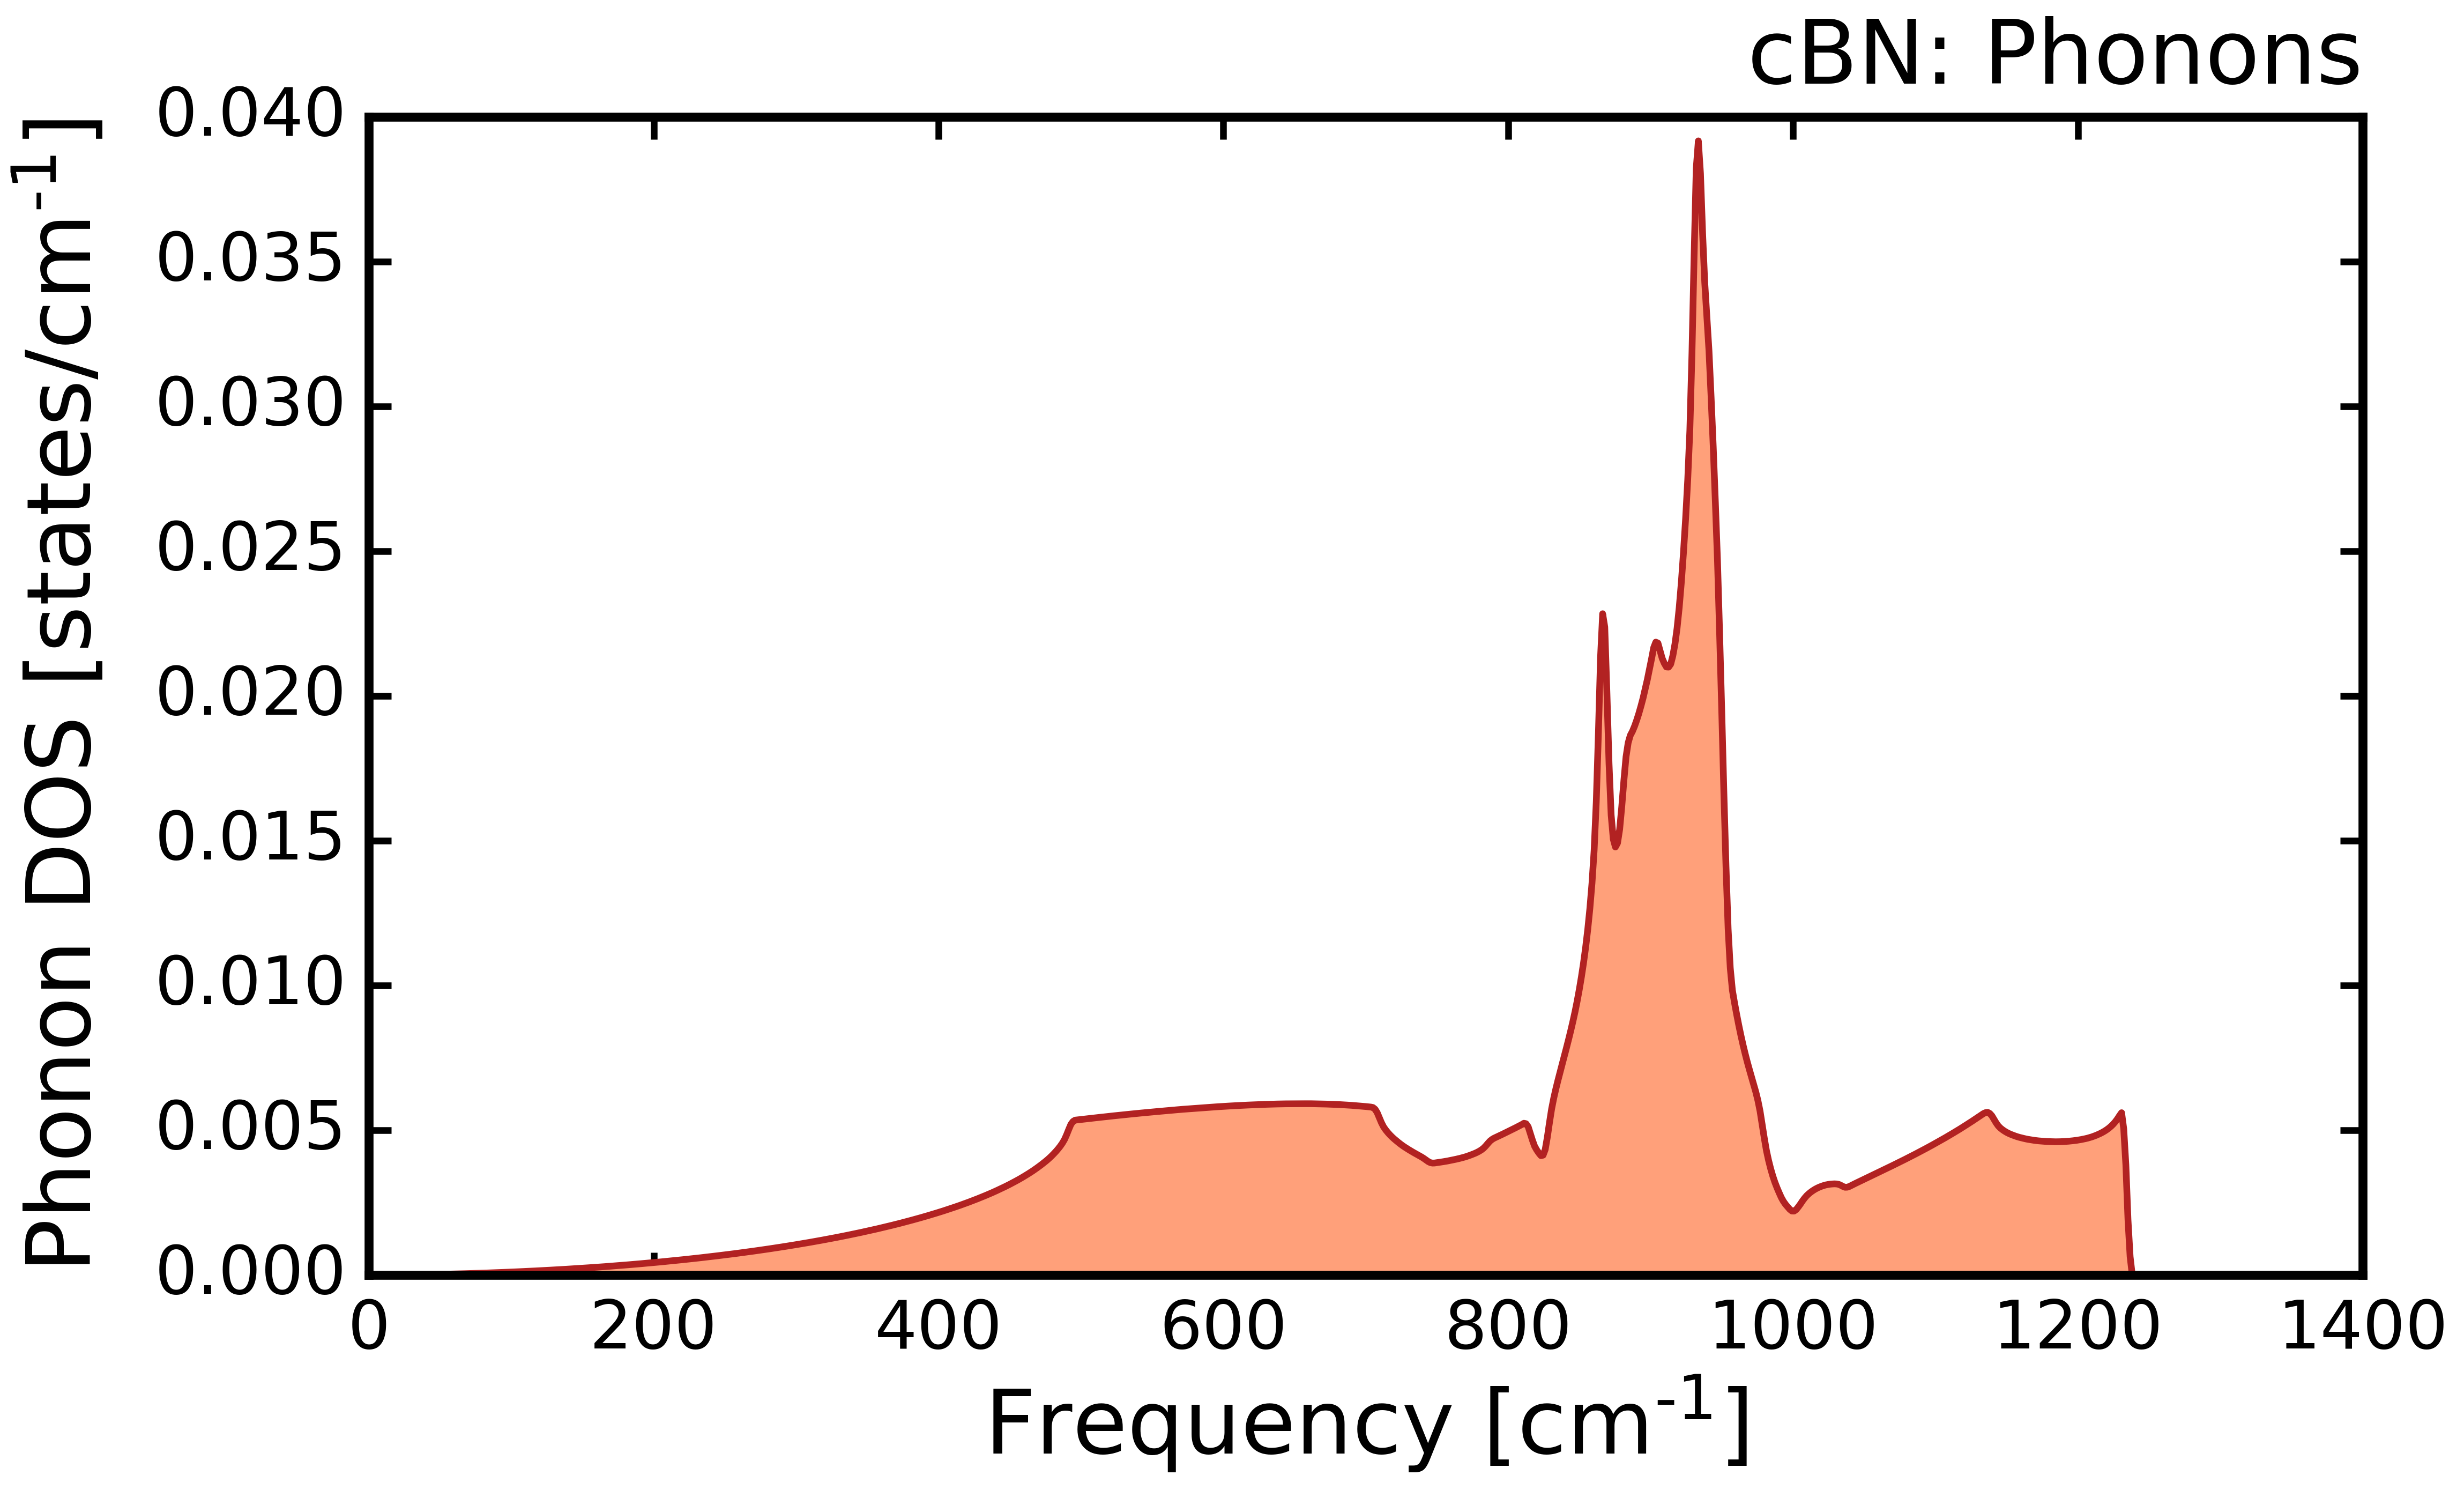
</figure>

**<span style="color:green">Phonon dispersion</span>**
    
<figure>
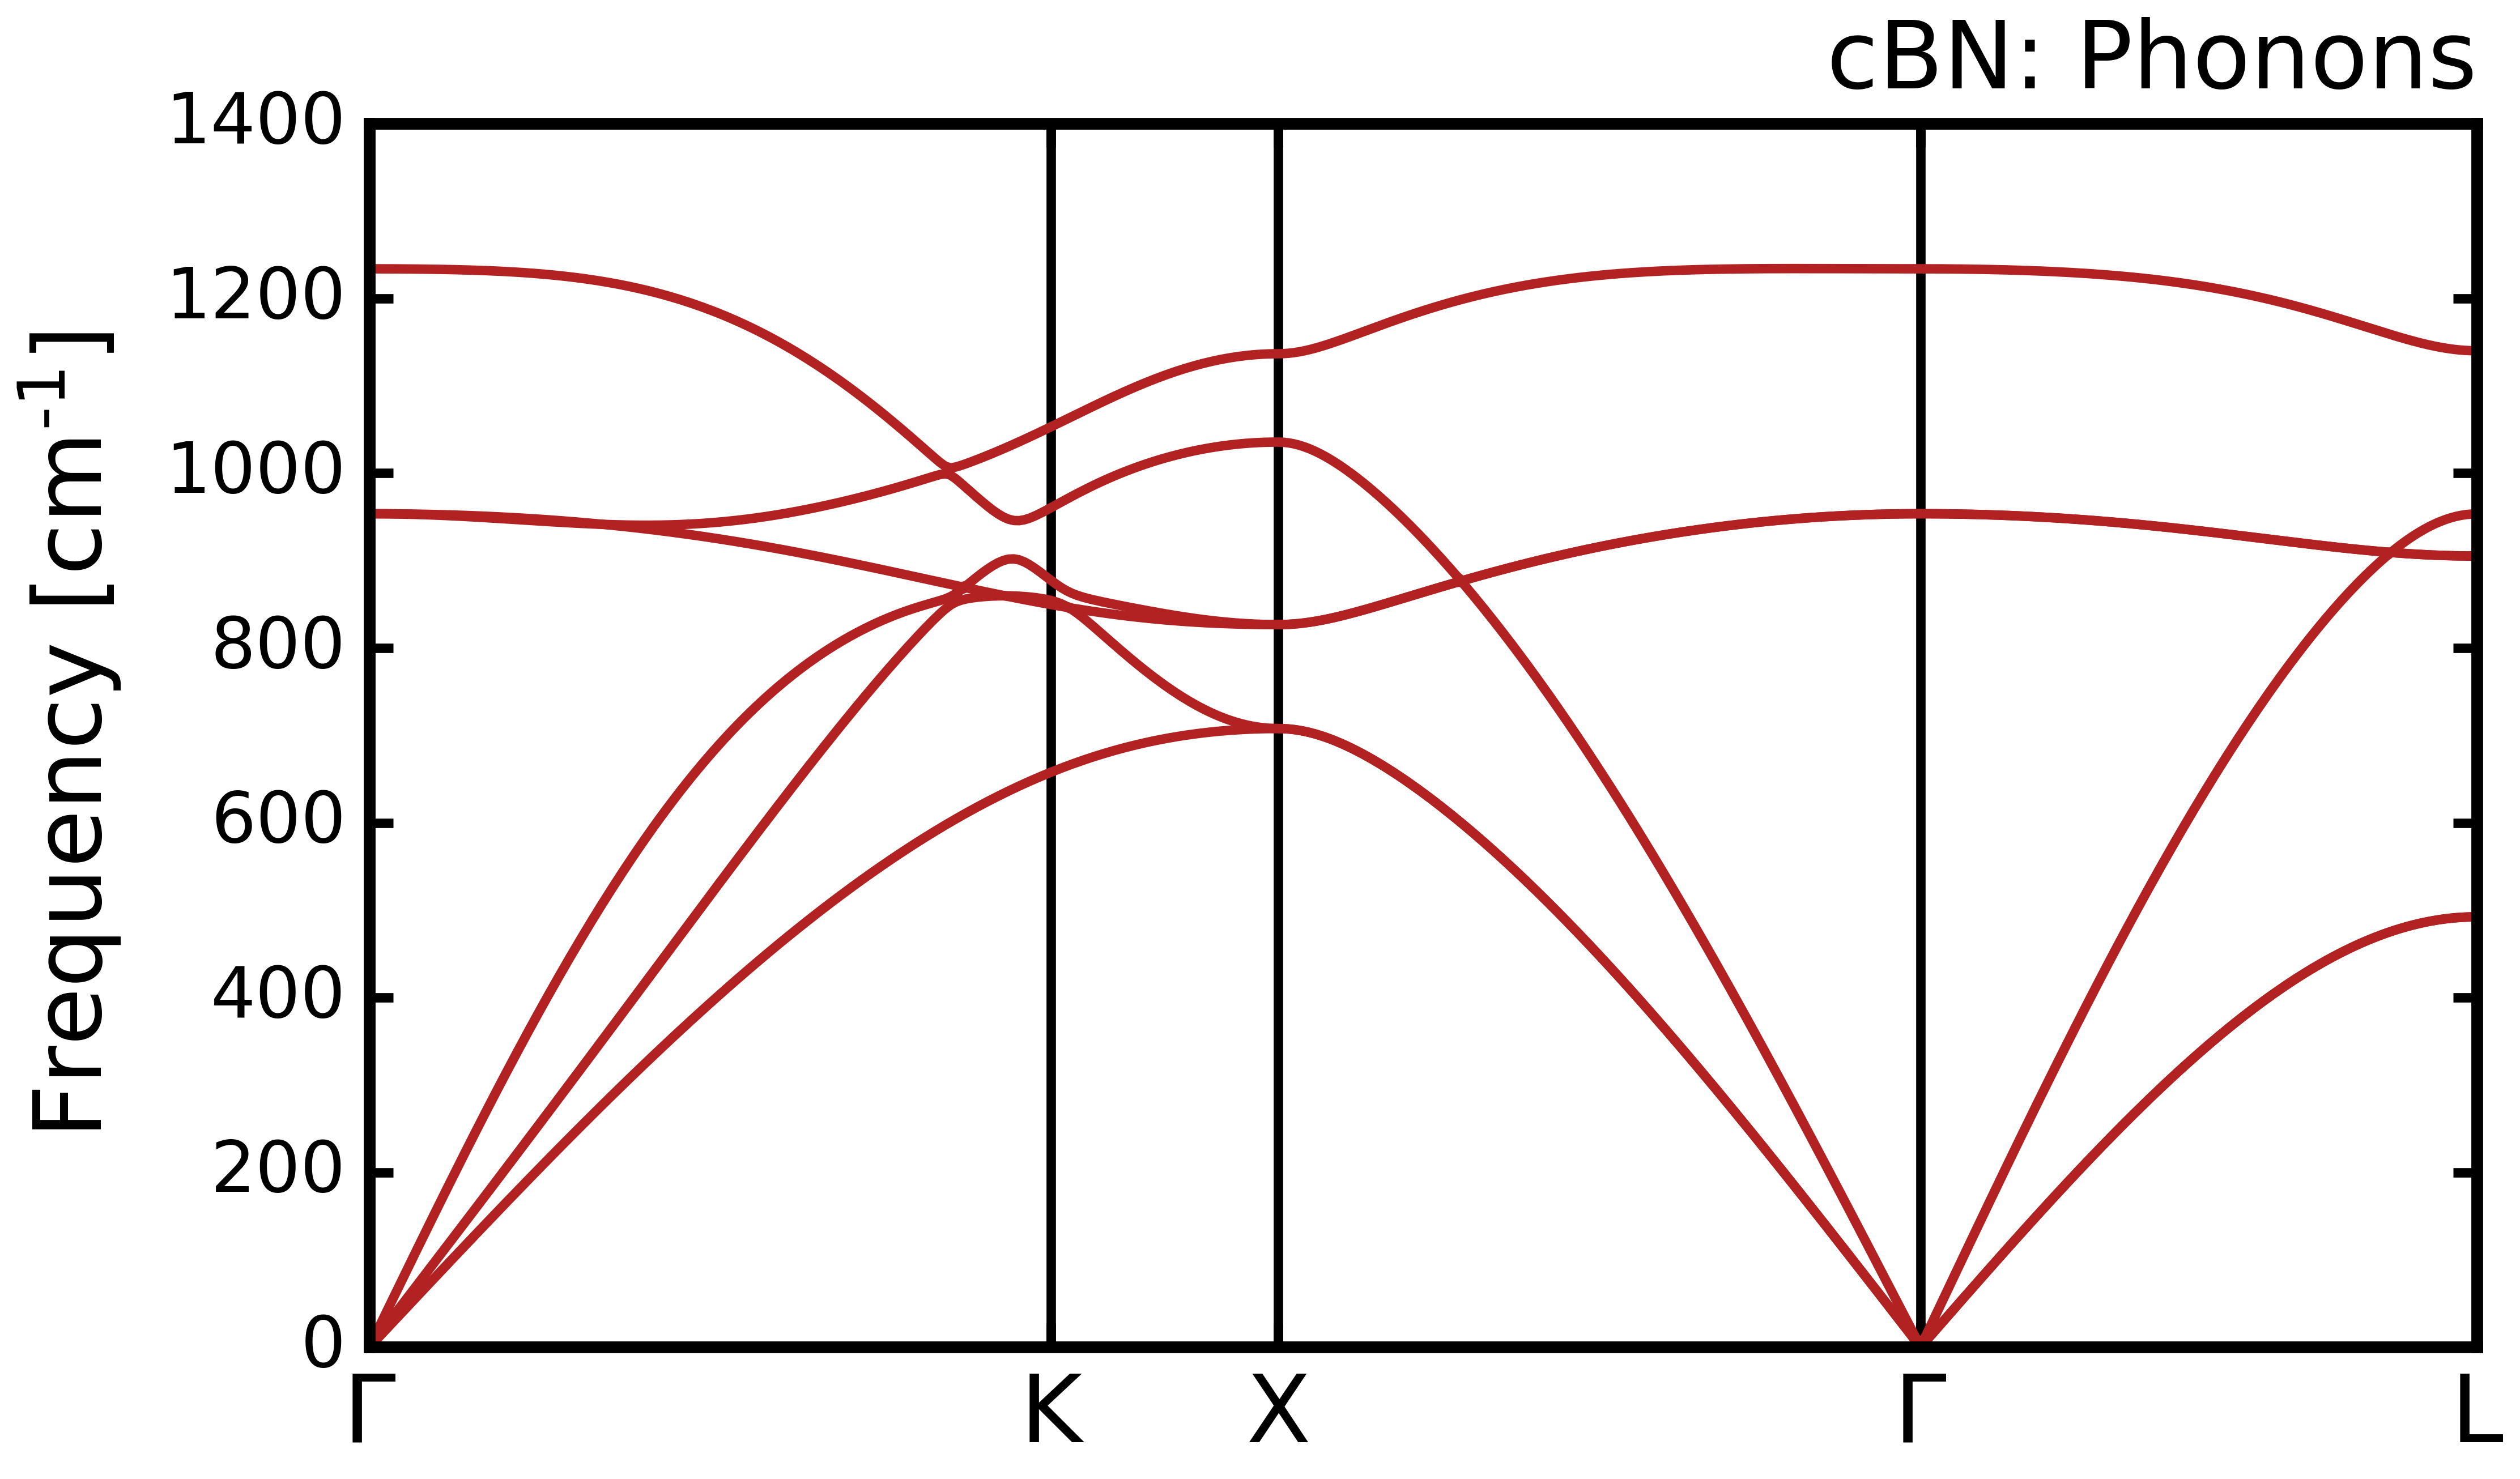
</figure>

<hr style="border:1px solid #DDD"> </hr> 
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Show converged plots</span></strong>
</summary>
<figure>
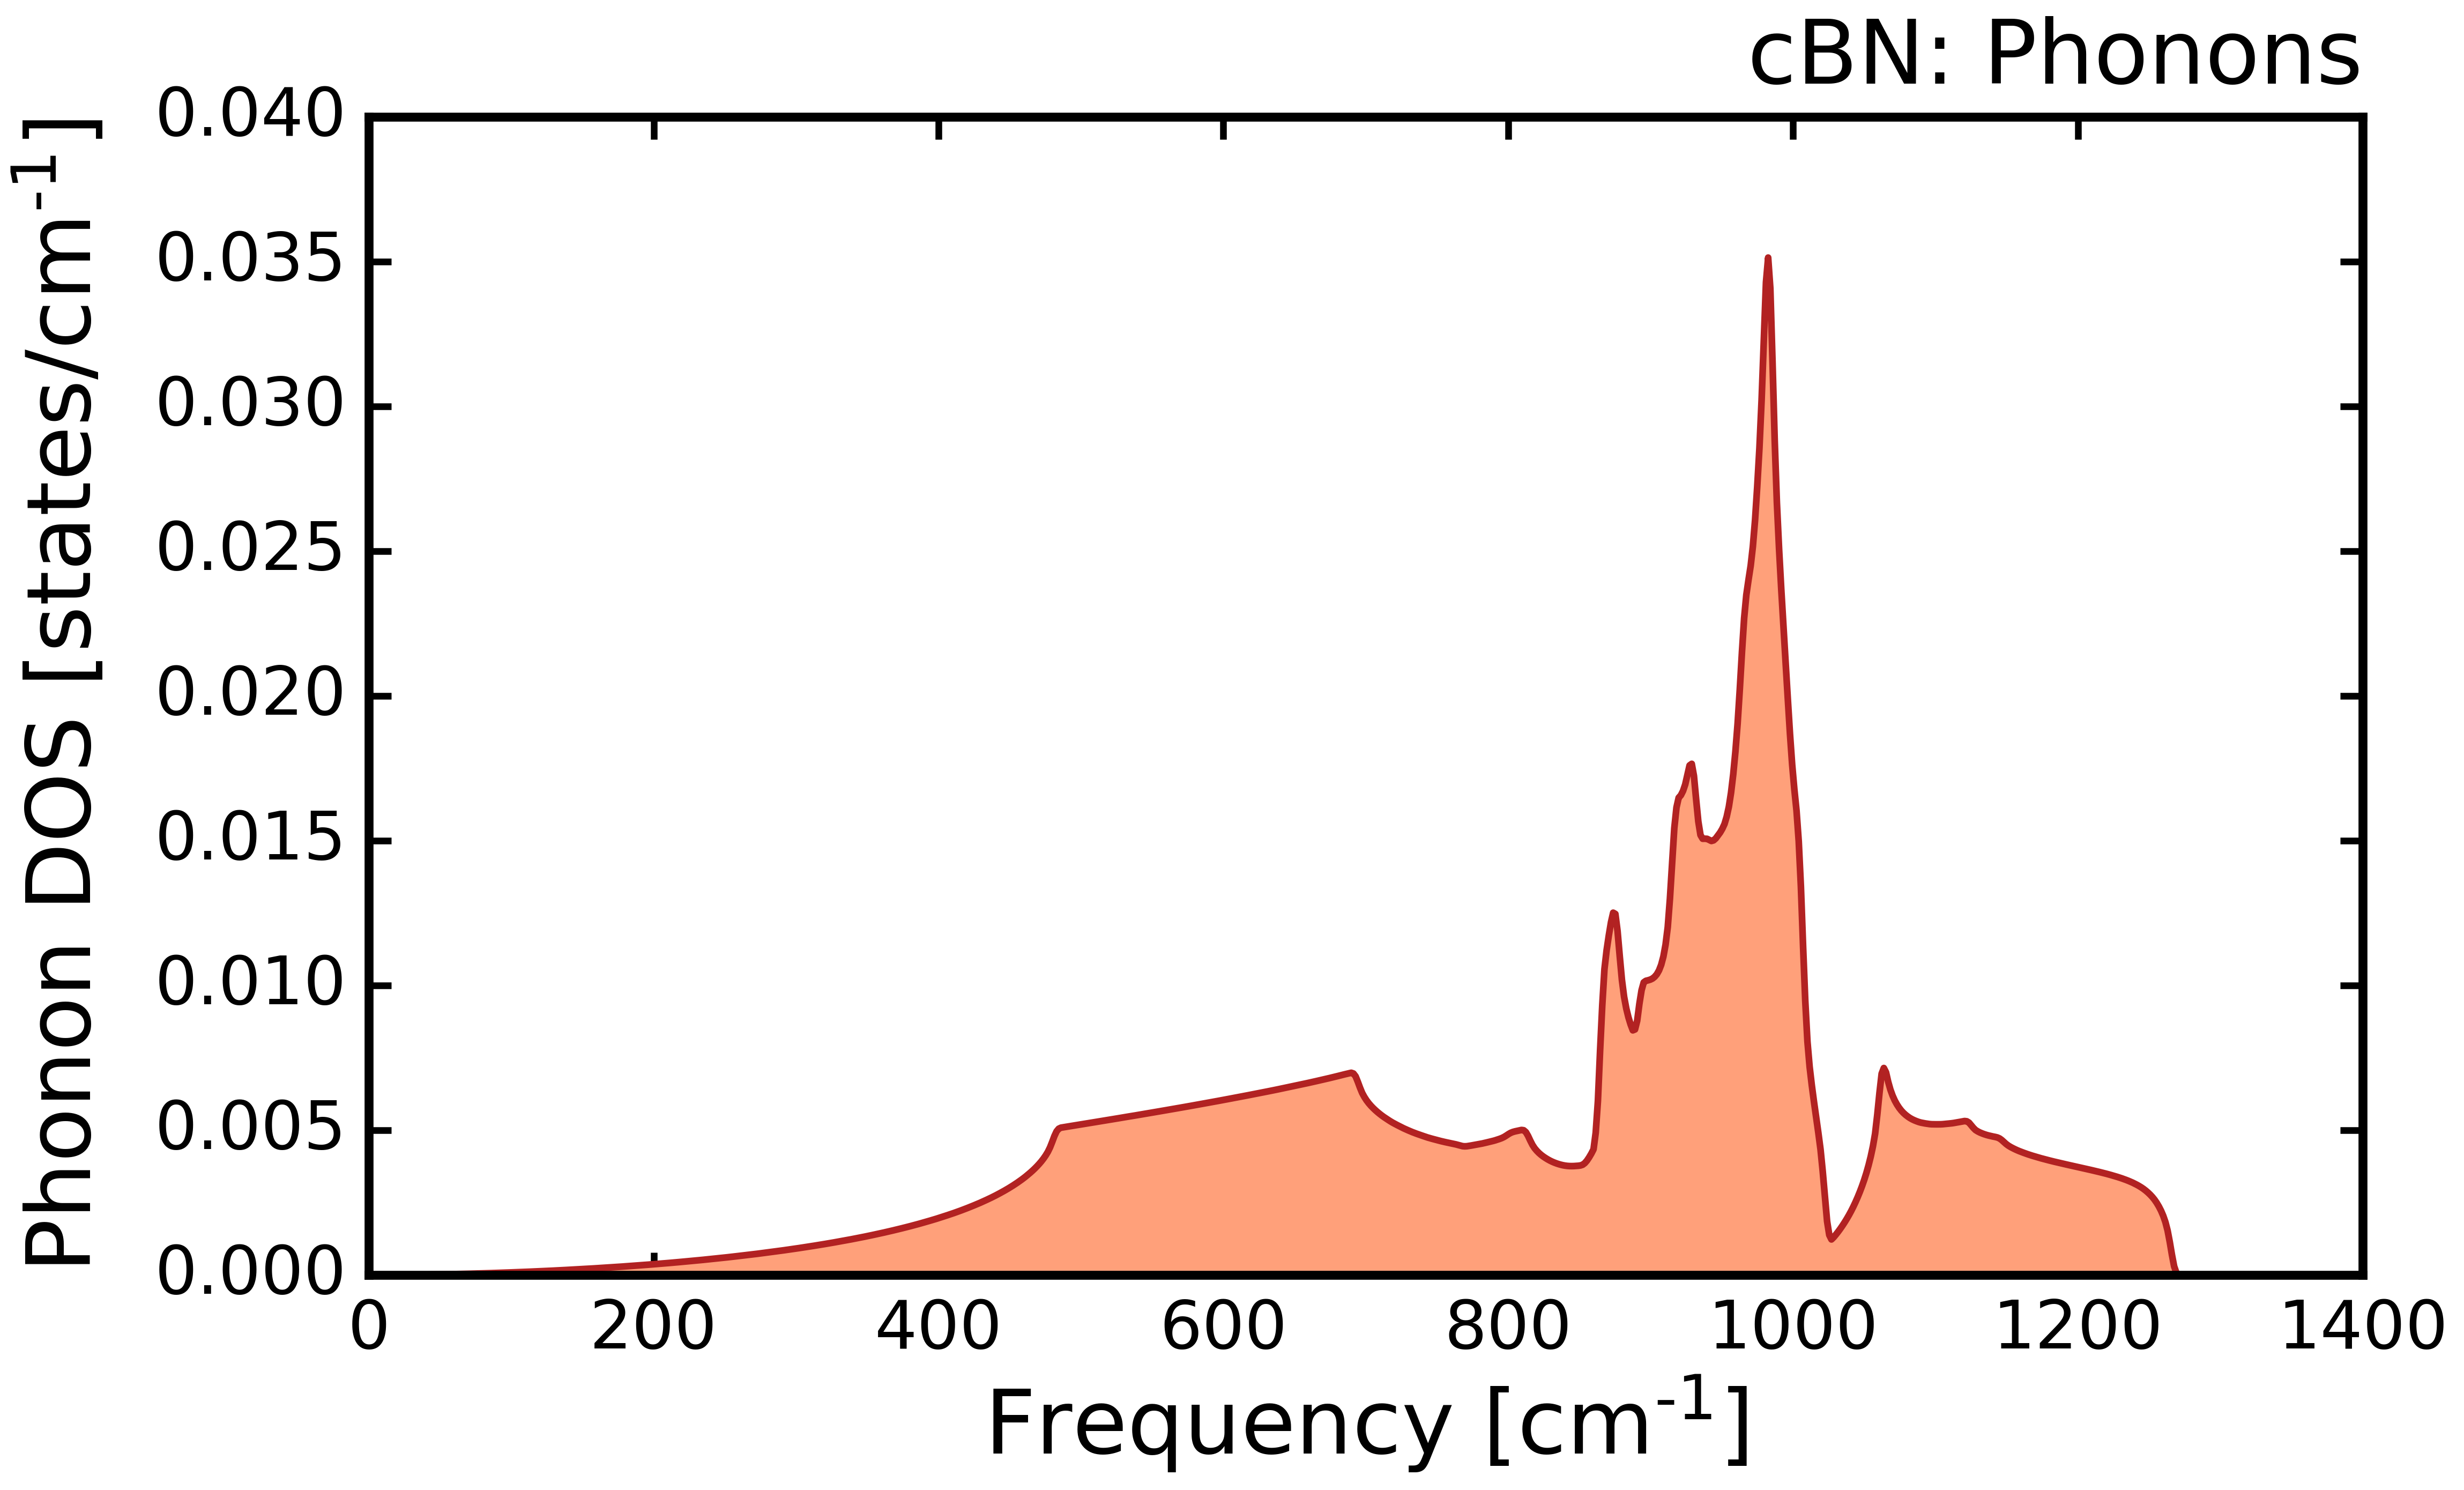
</figure>
    
<figure>
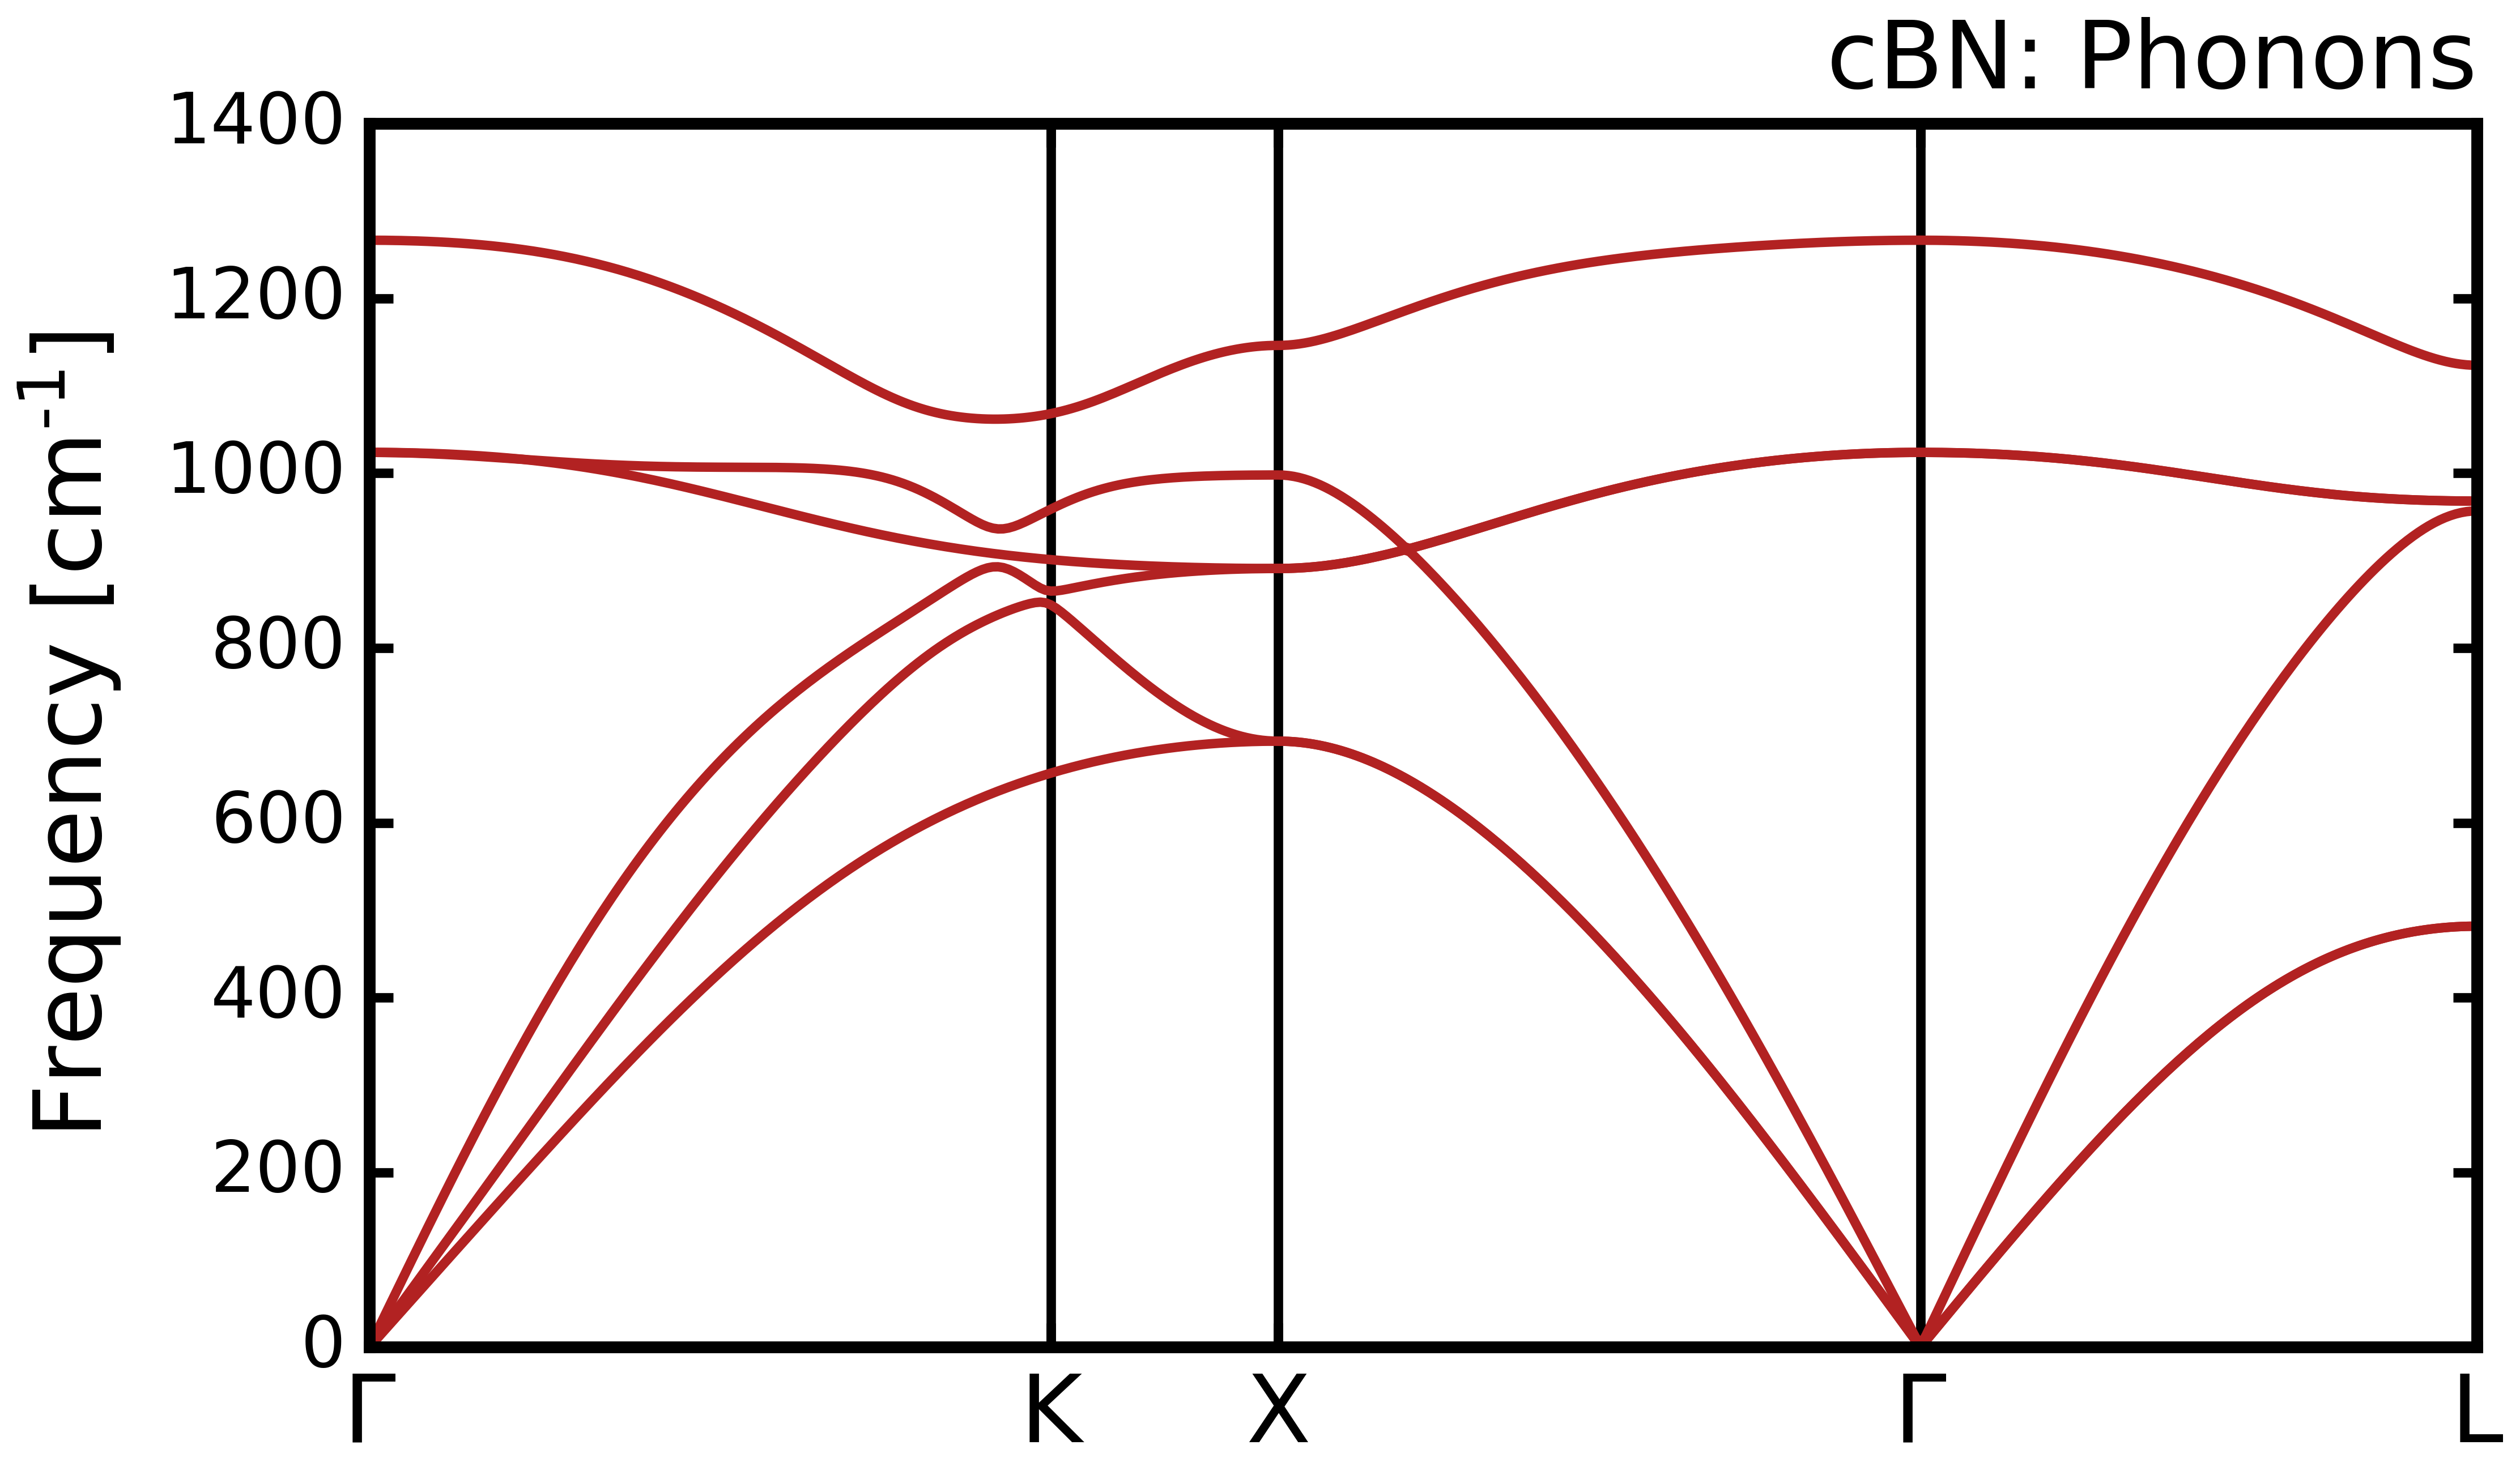
</figure>
</details>    
    
<hr style="border:1px solid #DDD"> </hr> 

<a id='4'></a>
### <span style="color:#15317E">4. Useful Tips for Real-life Calculations (DFPT)</span>

<a id='4.1'></a>
**<span style="color:#15317E">4.1 Resume from a Previous Run</span>**

Similar to a ground-state calculation, also a **DFPT** phonon calculation can be resumed from a previous run. This might prove helpful in cases where an expensive calculation did not finish, *e.g.*, due to given run-time limits or following an unintended crash. In order to restart a calculation from a previous run, set the attribute <code><span style="color:mediumblue">do</span></code> to <code><span style="color:firebrick">"fromfile"</span></code> in the phonons element. This will read the density and potential response from the files **PHONON_DRHO_*fileext*_#.OUT** and **PHONON_DVEFF_*fileext*_#.OUT** and restart the iterative solution of the Sternheimer equation. For that to work, however, it is important that the respective files have been written in the first place. To achieve this, we recommend to make use of the attribute <code><span style="color:mediumblue">nwrite</span></code> from the <code><span style="color:green">groundstate</span></code> element in the case of more elaborate calculations. This attribute specifies after how many iterations the current density and potential response are written to file.

Note that subdirectories in which the **DYN_*fileext*_#.OUT** files are present will be skipped in following runs.

<hr style="border:1px solid #DDD"> </hr>
<a id='4.2'></a>

**<span style="color:#15317E">4.2 Parallel Execution Using Multiple Processes and MPI</span>**

<hr style="border:1px solid #DDD"> </hr> 
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Parallelization explained</span></strong>
    
</summary> 

In general, **DFPT** phonon calculations can be highly parallelized. There are two levels of parallelization.

1. The **outer level** parallelizes over pairs **(q,I)** of **q**-points and irreps. Each such pair corresponds to one of the subdirectories and constitutes an independent part of the full calculation. The **(q,I)** pairs do not depend on one another and can be calculated in parallel.
2. The **inner level** parallelizes over **k**-points and irrep members **d** within each of the **(q,I)** pairs. **MPI** parallelization over this inner level is also implemented. The product of the number of **k**-points and irrep members determines the **computational load** of each of the **(q,I)** pairs. The computational load is directly proportional to the time needed for a single **SCF** iteration. It also is the upper limit for the number of processes that can be utilized.

Important information about the computational cost of the full calculation and the parallelization settings that are in use can be found in the file **PHONON_RUN_INFO.OUT**. Let's discuss the content of the file for the example of diamond above.

We already know the first part from the **PHONON_INFO_*fileext*.OUT** file.    
    
```
================================================================================
= DFPT PHONON CALCULATION INFORMATION                                          =
================================================================================

Irreducible representations will be used.
k-points will be reduced by symmetries.
Response quantities will be symmetrized.

********************************************************************************
* q-points and displacements                                                   *
********************************************************************************

number of q-points:               3
number of phonon modes:           6

  iq  q-vector (lattice coordinates)  N_sym  N_k  N_irrep (size)
--------------------------------------------------------------------------------
   1 ( 0.000000, 0.000000, 0.000000)     48    8        2 (3,3)
   2 ( 0.500000, 0.000000, 0.000000)     12   13        4 (2,1,1,2)
   3 ( 0.500000, 0.500000, 0.000000)     16   13        3 (2,2,2)    
```  
    
It shows some information about the usage of symmetries and prints all the **q**-points and **irreps** with their size (number of **irrep** members) and the number of (irreducible) **k**-points for each **q**-point.

The next part displays information about the computational load of the calculation.  
    
```  
********************************************************************************
* independent parts and computational load                                     *
********************************************************************************

total (remaining) number of independent parts:      9 (9)
total (remaining) computational load:             204 (204)

remaining parts
  ip   iq irrep dim load procs
------------------------------
   1    1     1   3   24     1
   2    1     2   3   24     1
   3    2     1   2   26     1
   4    2     2   1   13     1
   5    2     3   1   13     1
   6    2     4   2   26     1
   7    3     1   2   26     1
   8    3     2   2   26     1
   9    3     3   2   26     1

done parts
  iq irrep dim load
-------------------
```    
    
In this example, there are 9 independent parts (= number of **(q,I)** pairs = number of subdirectories). This number equals the sum of the column **N_irrep** in the table above. The total computational load of the full calculation is 204. *I.e.*, 204 is the largest number of processes that can be effectively utilized in this example.

The two tables below list all the remaining and already completed (none in this example) parts. For each part **ip**, it gives the index of the **q**-point **iq** and the index of the irreducible representation irrep and its dimension **dim** (= number of the members of **irrep**). The last two columns give the computational load (= product of number of **k**-points and **irrep** members) and the number of processes that will work on this part.

The last part of the file gives further information about the parallelization settings.
    
```  
********************************************************************************
* parallelization settings                                                     *
********************************************************************************

number of processes:                        1
optimal average load per process:       204.0
minimum load per process:                 204
maximum load per process:                 204
number of idle processes:                   0

proc load (imbalance)
----------------------
   0  204 (+0.0)
```      

In this example, there will be only one process. Both the optimal, minimum and maximum computational load per process is 204 in this example and there are no idle processes. The table below shows the load assigned to each process. In parenthesis, the imbalance, *i.e.*, the difference to the optimal average load is provided.

**<span style="color:firebrick">Note</span>** that one unit of computational load is different for each calculation and it is mainly determined by the number of **(L)APW+LO** basis functions (= matrix size). Keep reading for a more meaningful example.    
</details>    
<hr style="border:1px solid #DDD"> </hr> 
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Choosing parallelization settings</span></strong>
</summary>

In order to find out how the calculation will be parallelized for a given number of processes you have the option of performing a **dry run**. Let's assume, we plan to execute the example above with 16 processes. Before we start the actual calculation, we want to find out how the calculation will be parallelized. To this extend, we change the attribute <code><span style="color:mediumblue">do</span></code> to <code><span style="color:firebrick">"dry"</span></code> in the phonons element and add the new attribute <code><span style="color:mediumblue">drynumprocs </span>=<span style="color:firebrick">"16"</span></code>.

```xml    
...
   <phonons 
      do="dry" 
      method="dfpt"
      ngridq="2 2 2"
      polar="false"
      drynumprocs="16">
      ...
   </phonons>
...
```    

Running exciting, this case, will only produce the file **PHONON_RUN_INFO.OUT**. (You might have to delete the **DYN_*fileext*_#.OUT** files in the subdiretories if you have already completed the phonon calculation above in the same directory.) This time, the file looks like the following.
    
```
================================================================================
= DFPT PHONON CALCULATION INFORMATION                                          =
================================================================================

Irreducible representations will be used.
k-points will be reduced by symmetries.
Response quantities will be symmetrized.

********************************************************************************
* q-points and displacements                                                   *
********************************************************************************

number of q-points:               3
number of phonon modes:           6

  iq  q-vector (lattice coordinates)  N_sym  N_k  N_irrep (size)
--------------------------------------------------------------------------------
   1 ( 0.000000, 0.000000, 0.000000)     48    8        2 (3,3)
   2 ( 0.500000, 0.000000, 0.000000)     12   13        4 (2,1,1,2)
   3 ( 0.500000, 0.500000, 0.000000)     16   13        3 (2,2,2)

********************************************************************************
* independent parts and computational load                                     *
********************************************************************************

total (remaining) number of independent parts:      9 (9)
total (remaining) computational load:             204 (204)

remaining parts
  ip   iq irrep dim load procs
------------------------------
   1    1     1   3   24     3
   2    1     2   3   24    12
   3    2     1   2   26    13
   4    2     2   1   13    13
   5    2     3   1   13    13
   6    2     4   2   26    13
   7    3     1   2   26    13
   8    3     2   2   26    13
   9    3     3   2   26    13

done parts
  iq irrep dim load
-------------------

********************************************************************************
* parallelization settings                                                     *
********************************************************************************

number of processes:                       16
optimal average load per process:        12.8
minimum load per process:                   8
maximum load per process:                  14
number of idle processes:                   0

proc load (imbalance)
----------------------
   0   14 (+1.2)
   1   14 (+1.2)
   2   14 (+1.2)
   3   14 (+1.2)
   4   14 (+1.2)
   5   14 (+1.2)
   6   14 (+1.2)
   7   14 (+1.2)
   8   14 (+1.2)
   9   14 (+1.2)
  10   14 (+1.2)
  11   14 (+1.2)
  12   12 (-0.8)
  13    8 (-4.8)
  14    8 (-4.8)
  15    8 (-4.8)
```
    
The table in the second section of the file now shows how many processes will be working on which part (*e.g.*, 12 processes will work on **part 2**). From the third section we can tell that 16 is a reasonable number of processes for this example, since the optimal average load is 12.8 and the maximum load per process is 14 which is the one more than the smallest possible integer greater than the average load and meaning only little "*waste*" of resources. You will have bad parallelization settings if you either have a large number of idle processes or a very uneven distribution of load among the processes, *i.e.*, the maximum load per process being much larger than the optimal average load.
     
</details>
<hr style="border:1px solid #DDD"> </hr> 

<a id='5'></a>
### <span style="color:#15317E">5. Alternative: Phonons from Supercell Calculations</span>

Alternatively to using **DFPT** to compute phonons, you can also calculate phonons from **supercell calculations**. In that case, for each **q**-point a corresponding supercell is constructed and each equivalent atom is displaced along the three Cartesian directions by a small amount. The actual displacement pattern of these atoms is a **cosinus** or **sinus** wave with periodicity defined by the wavevector **q**. The amplitude of the wavelike displacement pattern is defined by the value **<span style="color:green">Δph</span>** of the attribute <code><span style="color:mediumblue">deltaph</span></code>. Finally, elements of the dynamical matrix are obtained using a finite difference procedure from atomic forces calculated for displacement patterns with amplitude **<span style="color:green">Δph</span>** and **<span style="color:green">2Δph</span>** (**<span style="color:green">-Δph</span>** and **<span style="color:green">Δph</span>** at **q**=0). In general, using **DFPT** leads to much faster calculations than using the supercell approach. However, supercell phonons can still be very useful to investigate anharmonic effects beyond the harmonic approximation (anharmonicity). Further, not all features available in ground-state calculations are implemented within **DFPT**, but they can be used using supercells. Examples are **van-der-Waals interactions** or **spin-orbit coupling**.

<a id='5.1'></a>
**<span style="color:#15317E">5.1 Set up the Supercell Phonon Calculation</span>**

n order to trigger a supercell calculation, we have switch the attribute <code><span style="color:mediumblue">method</span></code> to <code><span style="color:firebrick">"sc"</span></code> and set the displacement amplitude (in Bohr units) using <code><span style="color:mediumblue">deltaph</span></code>.

```xml    
...
   <phonons 
      do="fromscratch" 
      method="sc"
      ngridq="2 2 2"
      deltaph="0.03"
      polar="false">
      ...
   </phonons>
...
```

<hr style="border:1px solid #DDD"> </hr> 
<a id='5.2'></a>

**<span style="color:#15317E">5.2 Output Files of a Phonon Calculation</span>**

The name of the subdirectories created from a supercell calculation is different from the **DFPT** case. The names of the directories include information, in order of appearance, on the **q** vector (**<span style="color:mediumblue">Q…</span>**), the species of the displaced atoms (**<span style="color:mediumblue">S…</span>**), the index in the unperturbed primitive cell of the displaced atoms (**<span style="color:mediumblue">A…</span>**), and the polarization direction of the displacement (**<span style="color:mediumblue">P…</span>**). Example of such names are **<span style="color:mediumblue">Q0000_0000_0000_S01_A001_P1</span>**, **<span style="color:mediumblue">Q0102_0000_0000_S01_A001_P1</span>**, *etc.*.

Inside the subdirectories you will find the files **INFO_*fileext*.OUT** which are standard **INFO.OUT** files of the various groundstate calculations performed in the finite difference scheme. They replace the **PHONON_INFO_*fileext*.OUT** files from the **DFPT** case.

<hr style="border:1px solid #DDD"> </hr> 
<a id='5.3'></a>

**<span style="color:#15317E">5.3 Polar Materials from Supercell Calculations</span>**

A supercell calculation of **Γ**-point phonons also calculates the Born effective charge tensors $Z^\ast_\kappa$ and generates the file **ZSTAR.OUT**. The dielectric constant $\epsilon^\infty$ in the corresponding file **EPSINF.OUT**, however, is not computed and must be provided manually. Once both files are present, all further phonon properties will correctly account for the polar character if you set <code><span style="color:mediumblue">polar</span></code> to <code><span style="color:firebrick">"true"</span></code>.

<hr style="border:1px solid #DDD"> </hr> 
<a id='5.4'></a>

**<span style="color:#15317E">5.4 Phonon Properties for Diamond</span>**

As an **exercise** try to repeat the phonon calculation for diamond but now using the supercell method. Here, we will only present the results you should obtain using a **4×4×4** **k**-grid, <code><span style="color:mediumblue">rgkmax</span>=<span style="color:firebrick">"4.0"</span></code>, and **2** **q**-points in each direction.

**<span style="color:green">Phonon frequencies</span>**

```
Total number of atoms    :     2
Total number of q-points    :     3

q-point   1  is  [0.0, 0.0, 0.0]
   mode   1      frequency:     0.0000  cm-1
   mode   2      frequency:     0.0000  cm-1
   mode   3      frequency:     0.0000  cm-1
   mode   4      frequency:  1258.2158  cm-1
   mode   5      frequency:  1258.2158  cm-1
   mode   6      frequency:  1258.2158  cm-1

q-point   2  is  [0.5, 0.5, 0.0]
   mode   1      frequency:   777.4162  cm-1
   mode   2      frequency:   777.4162  cm-1
   mode   3      frequency:  1014.2525  cm-1
   mode   4      frequency:  1014.2525  cm-1
   mode   5      frequency:  1195.8142  cm-1
   mode   6      frequency:  1195.8142  cm-1

q-point   3  is  [0.5, 0.5, 0.5]
   mode   1      frequency:   540.8468  cm-1
   mode   2      frequency:   540.8468  cm-1
   mode   3      frequency:  1009.7927  cm-1
   mode   4      frequency:  1153.6611  cm-1
   mode   5      frequency:  1153.6611  cm-1
   mode   6      frequency:  1267.8193  cm-1

   
...   
```
Note the differences in comparison with the **DFPT** result. These differences become much smaller for more converged numerical settings.

**<span style="color:green">Phonon DOS</span>**

<figure>
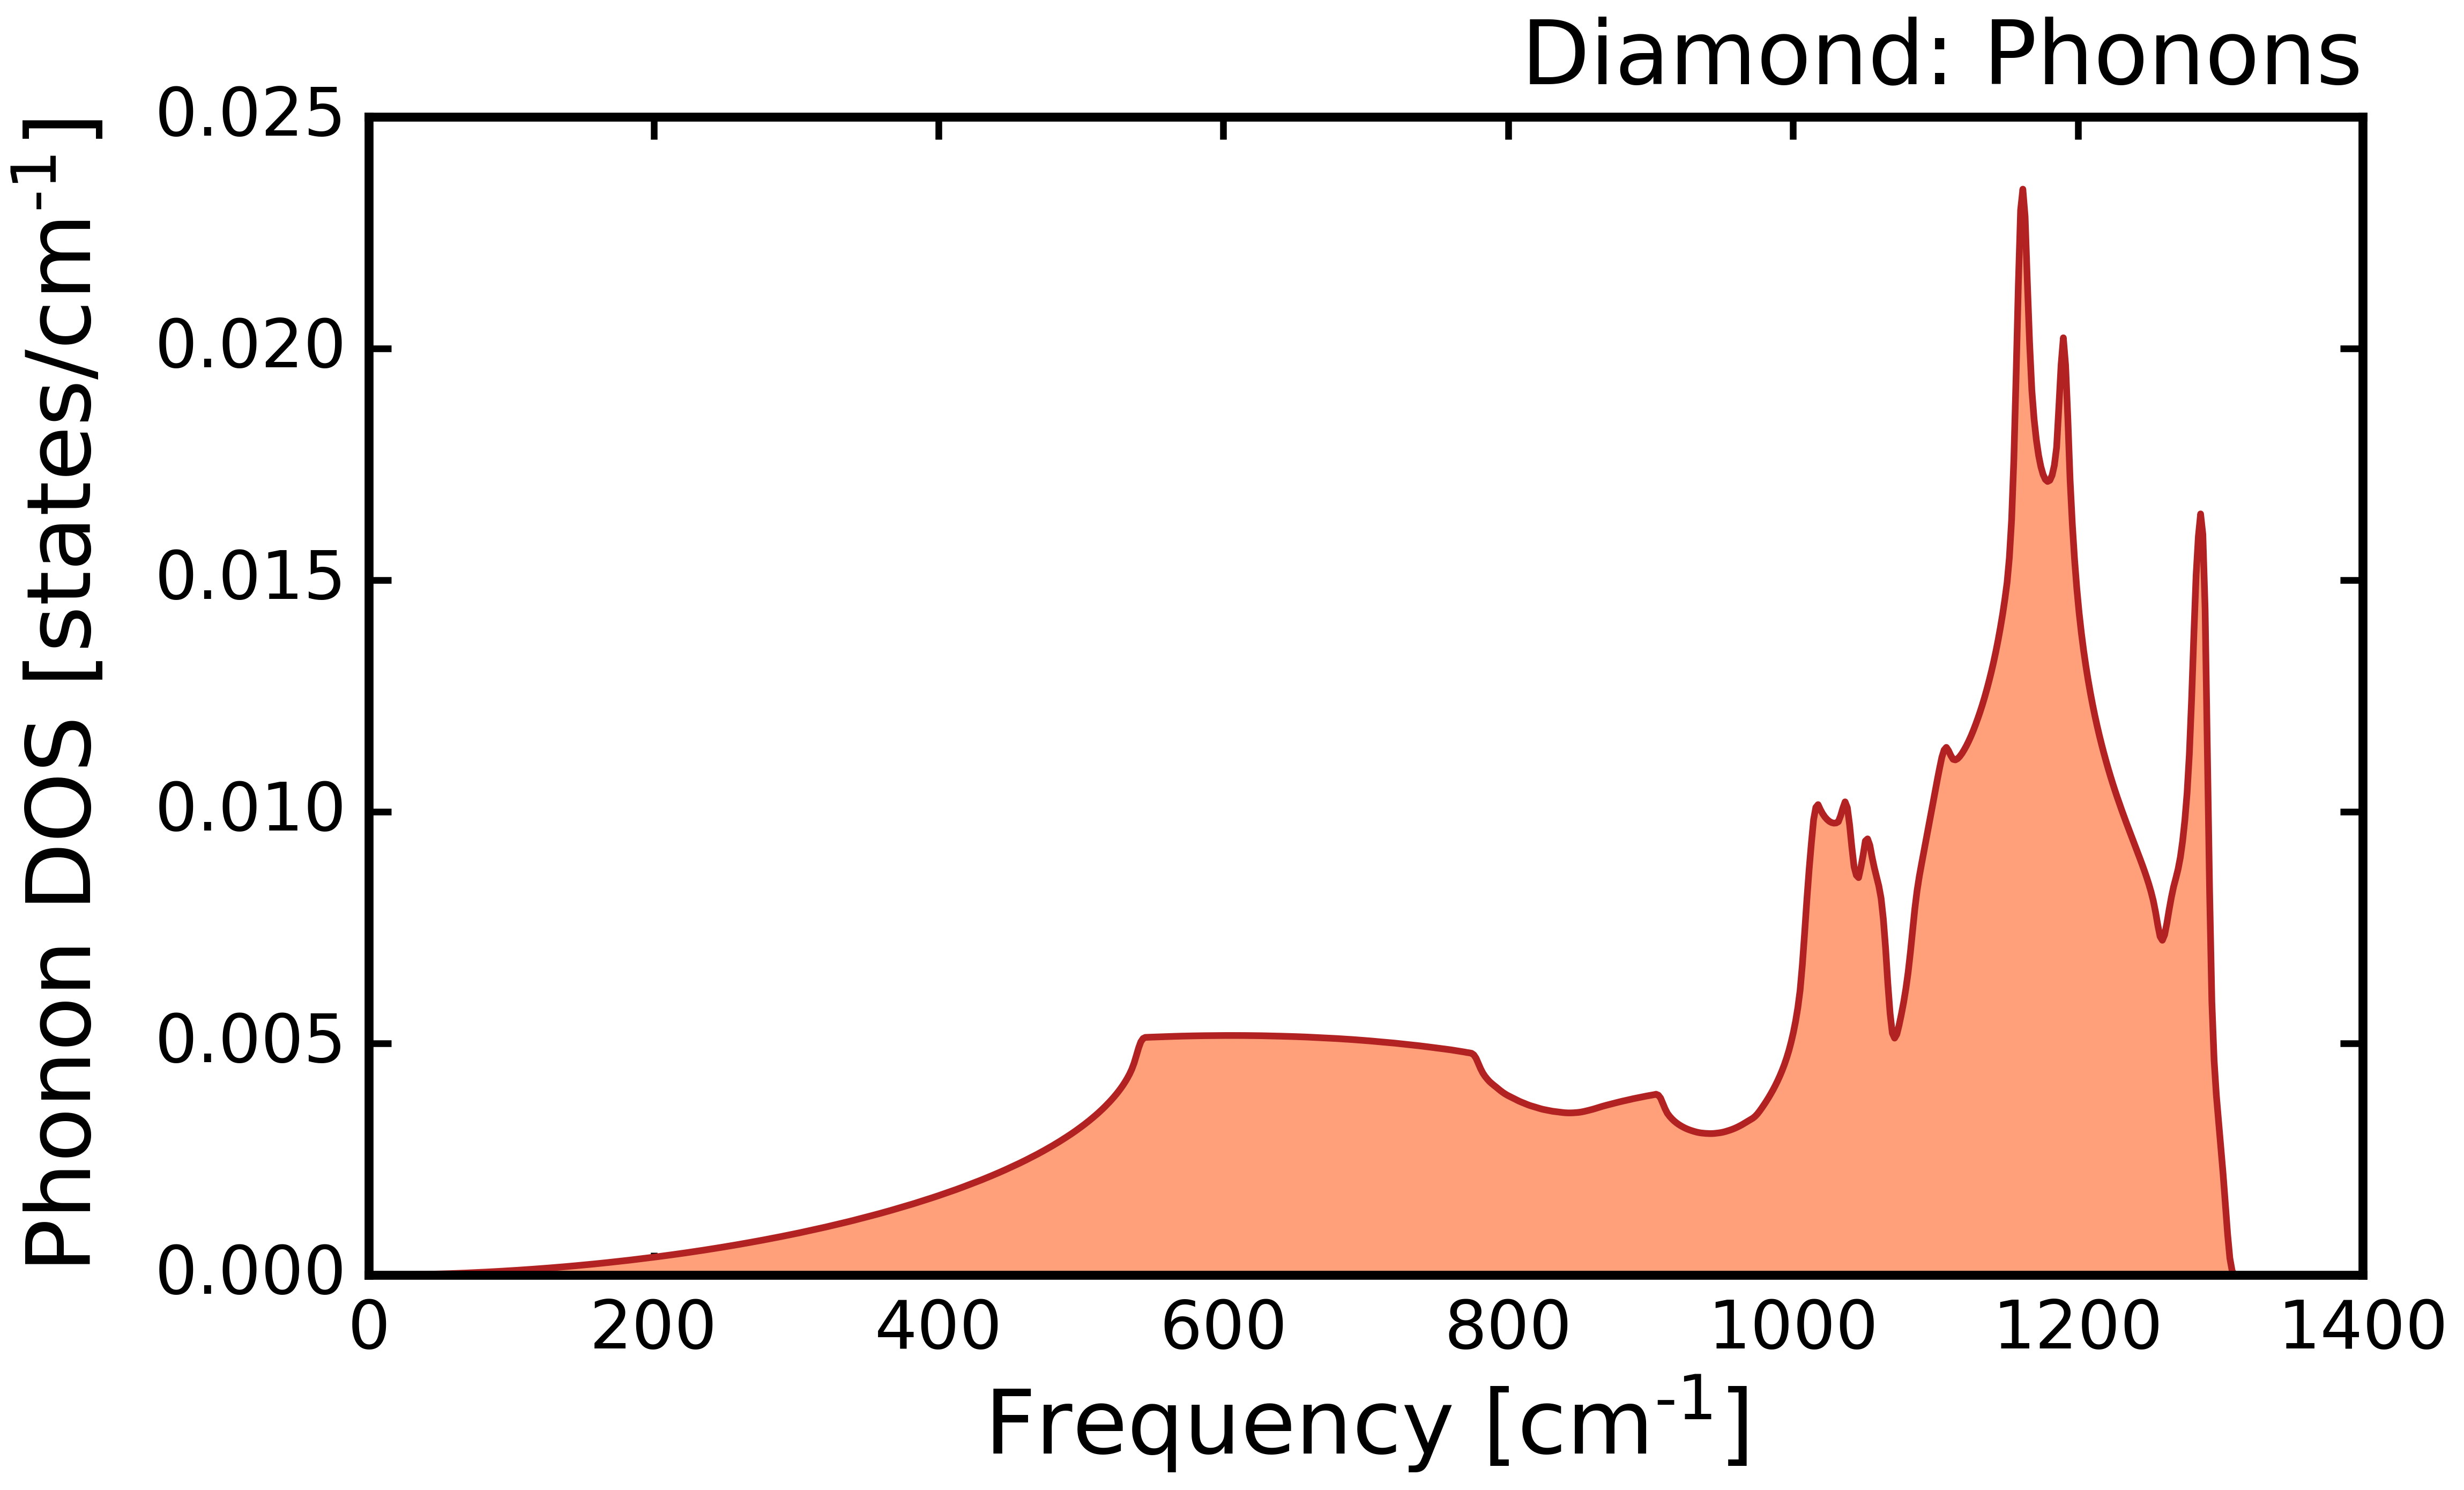
</figure>

**<span style="color:green">Phonon dispersion</span>**

<figure>
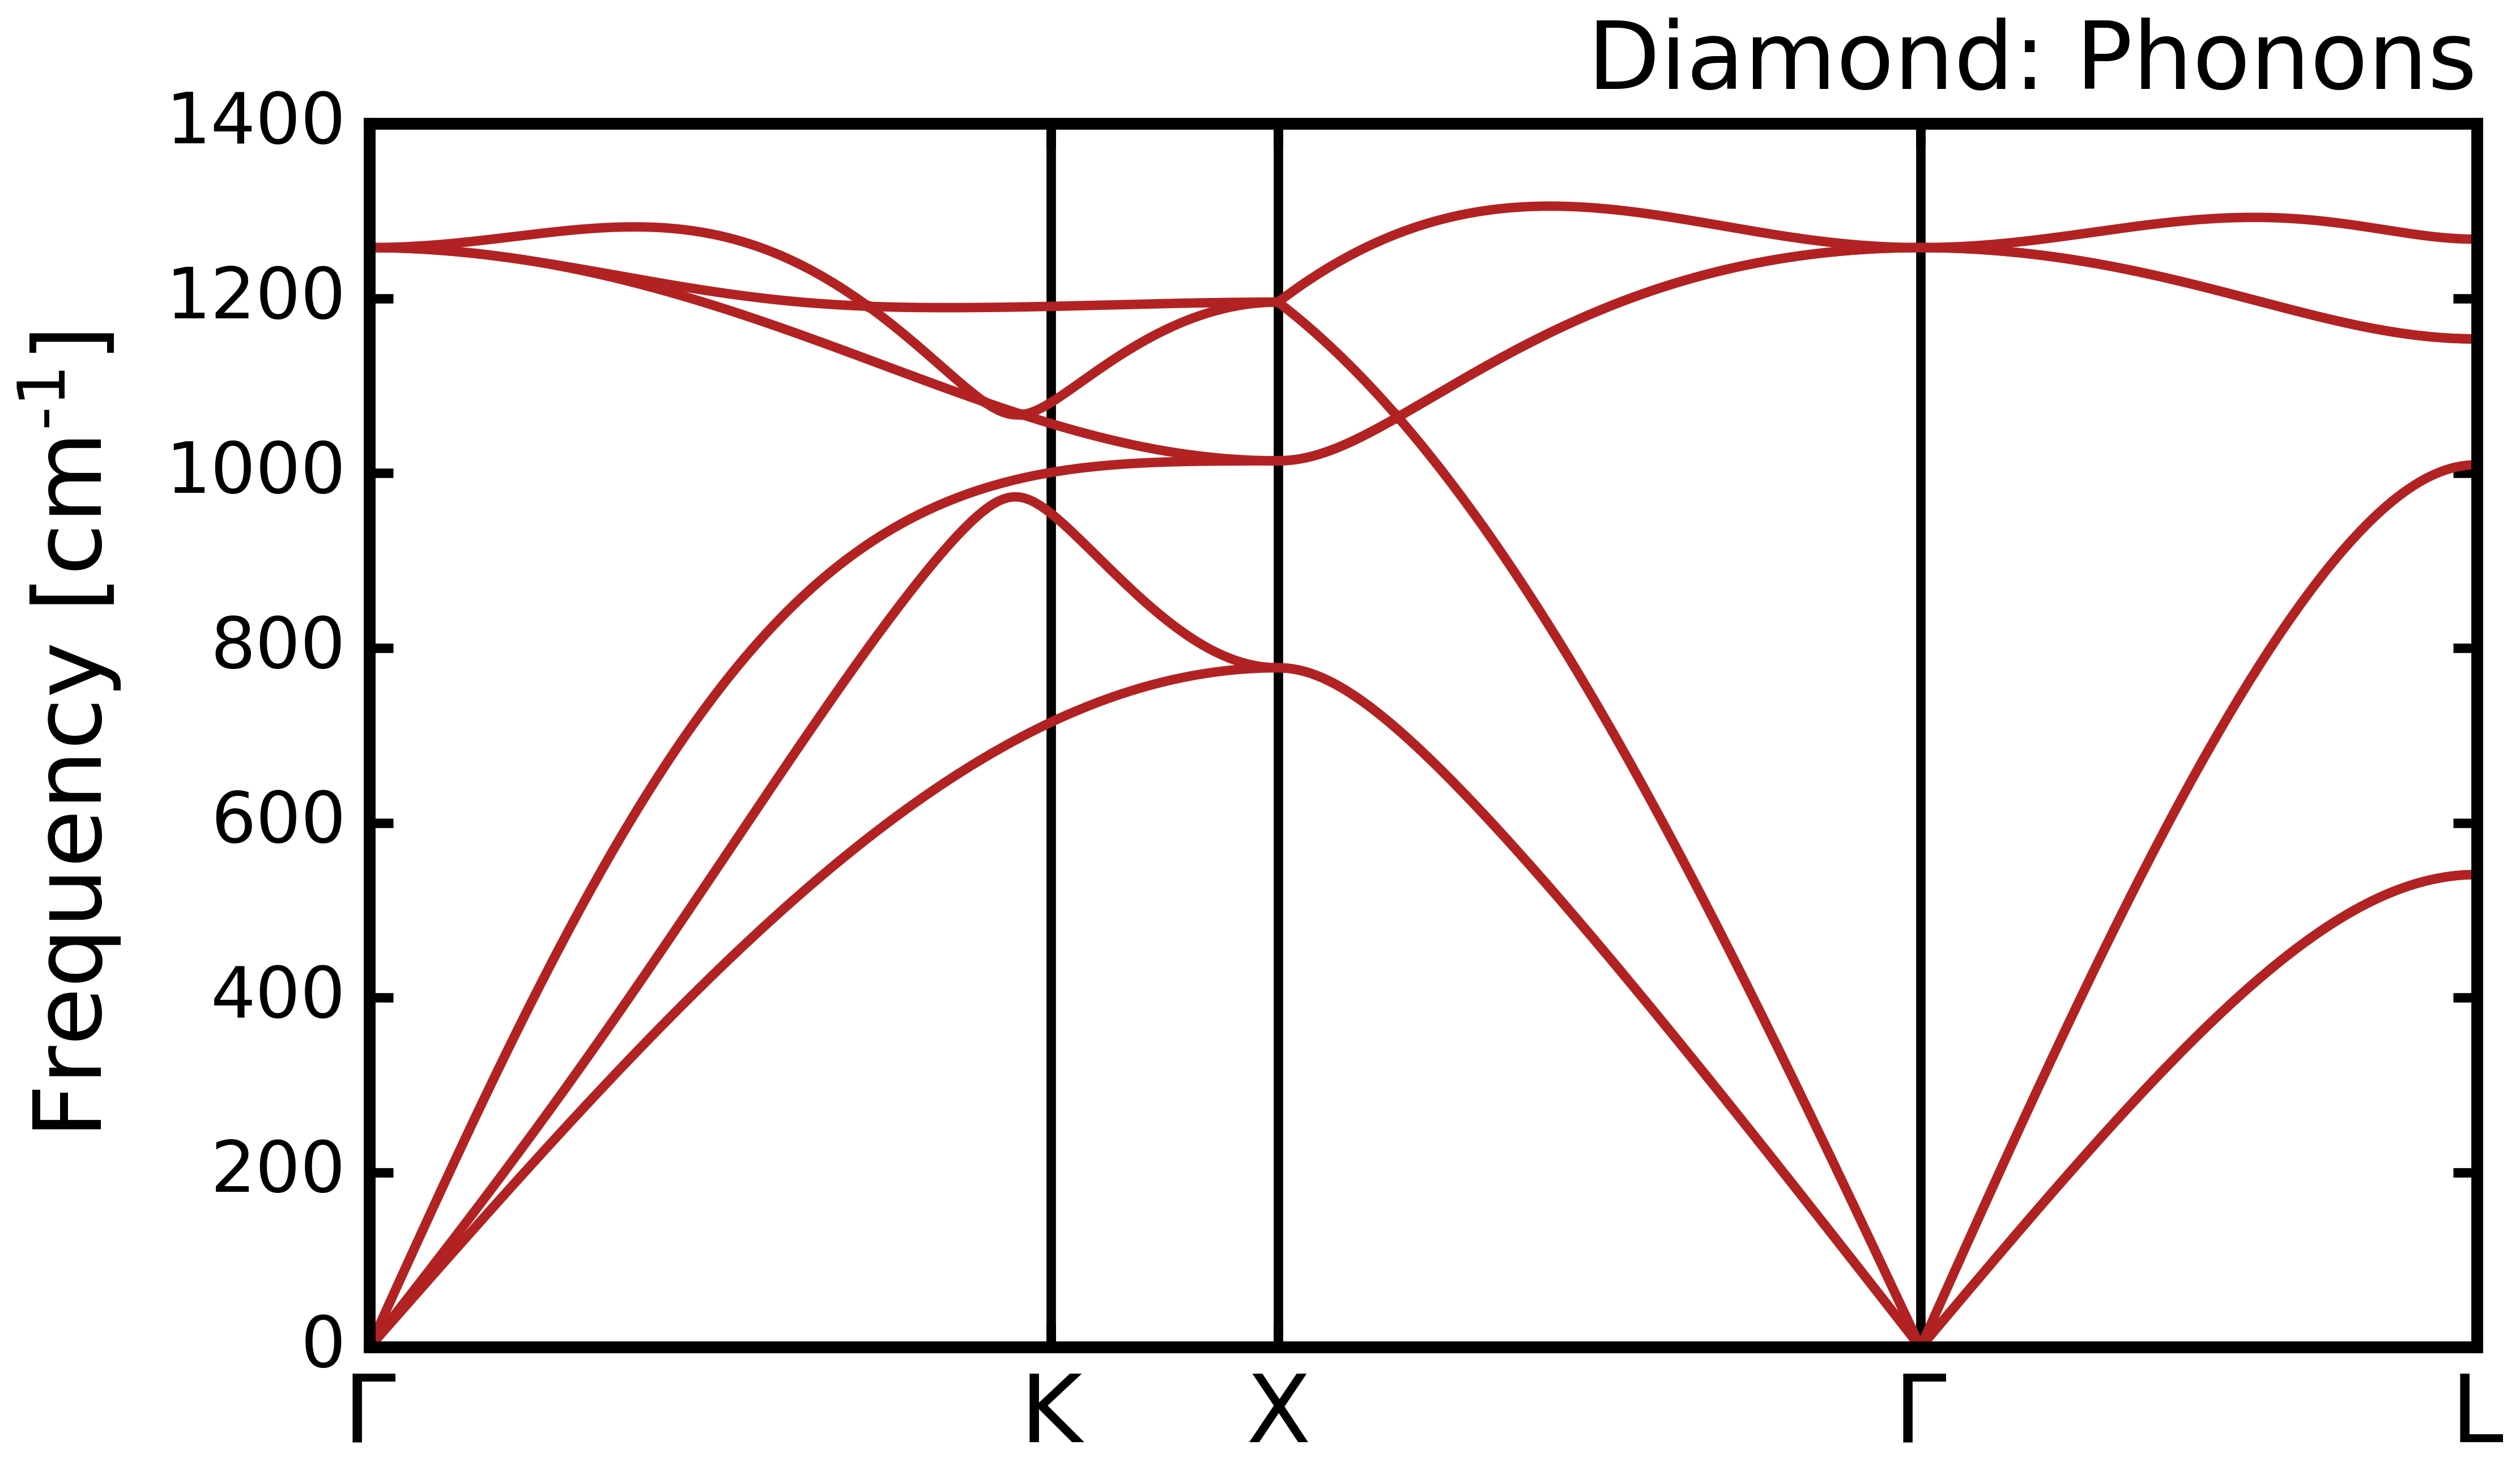
</figure>

<hr style="border:2px solid #DDD"> </hr> 